In [1]:
import numpy as np 
import pandas as pd
from src import utils, db, behavmatch
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
from pathlib import Path
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
working_dbase = db.get_sessions().query("recording == True")
working_dbase.loc[:, "name_round"] = working_dbase["mname"] + "_"+ working_dbase["round_id"].astype(str)
sessions = working_dbase["session"].unique()
areas = ['V1', 'medial', 'lateral', 'anterior']
celltype = ['Pyr', 'Int'] 
nmice = working_dbase["name_round"].nunique()
nareas = len(areas)
ncelltypes = len(celltype)
n_sessions = len(sessions)

In [3]:
def get_matched_trials(m):
    object_path = Path(r"D:\mouseobj")
    cbin = 3 
    name, datexp, blk = m.name, m.datexp, m.blk
    save_pth = object_path.joinpath(name,datexp,blk)
    protA = m.trial_dict["rewarded"]
    protB = m.trial_dict["non rewarded"]
    restA = m.trial_dict["rewarded test"]
    restB =  m.trial_dict["non rewarded test"]
    probs = np.load(save_pth.joinpath("probs.npy"), allow_pickle=True)
    prot_matched_trials = behavmatch.match_trials_by_prob_bins(probs, cbin, protA, protB, bins=np.linspace(0, 1, 11), random_state=0)
    rest_matched_trials = behavmatch.match_trials_by_prob_bins(probs, cbin, restA, restB, bins=np.linspace(0, 1, 11), random_state=0)
    m_rew = np.concatenate(prot_matched_trials[:,0]).astype(int)
    m_nrew = np.concatenate(prot_matched_trials[:,1]).astype(int)
    m_rew_test = np.concatenate(rest_matched_trials[:,0]).astype(int)
    m_nrew_test = np.concatenate(rest_matched_trials[:,1]).astype(int)
    trial_dict_matched = {"rewarded": m_rew,
                        "non rewarded": m_nrew,
                        "rewarded test": m_rew_test,
                        "non rewarded test": m_nrew_test}
    return trial_dict_matched

In [4]:
sessions_names = ['all rewarded before', 'first training', 'last training', 'last training (matched)' ,'all rewarded after']

In [6]:
rows = []
obj_path = Path(r"D:\mouseobj")
for iss, sess in enumerate(sessions_names):
    if sess == 'last training (matched)':
        session = 'last training'
    else:
        session = sess
    d = working_dbase.query(f"session == '{session}'")
    print(f"Processing: {sess}")
    for i, (_, row) in enumerate(d.iterrows()):
        name, datexp, blk = row["mname"], row["datexp"], row["blk"]
        save_pth = obj_path.joinpath(name,datexp,blk)
        if sess == 'last training (matched)':
            dp_rest = np.load(save_pth.joinpath("dp_rest_nosplit_matched.npy"))
        else:
            dp_rest = np.load(save_pth.joinpath("dp_rest_nosplit.npy"))
        m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=obj_path)
        for iaa, area in enumerate(areas):
            ia = utils.get_region_idx(m.iarea, area)
            for ic, cell in enumerate(celltype):
                sel_type = np.logical_not(m.isred[:, 0]).astype(bool) if cell == 'Pyr' else m.isred[:, 0].astype(bool)
                selection = ia * sel_type
                dp_sel = dp_rest[selection]
                signal_magnitude = np.sqrt(np.mean(dp_sel**2))
                median_gain = np.median(np.abs(dp_sel))
                p90_val = np.percentile(np.abs(dp_sel), 90)
                rows.append({'name': name, 'datexp': datexp, 'blk': blk, 
                             'session': sess, 'celltype': cell, 'area': area, 
                             'signal_magnitude': signal_magnitude, 'median_gain': median_gain, 'p90_val': p90_val})
    clear_output(wait=True)
dp_gain = pd.DataFrame(rows)

Processing: all rewarded after
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_01\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_15\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG14\20

In [9]:
dp_gain.to_csv(r"D:\mouseobj\overall\dp_gain_analysis.csv", index=False)

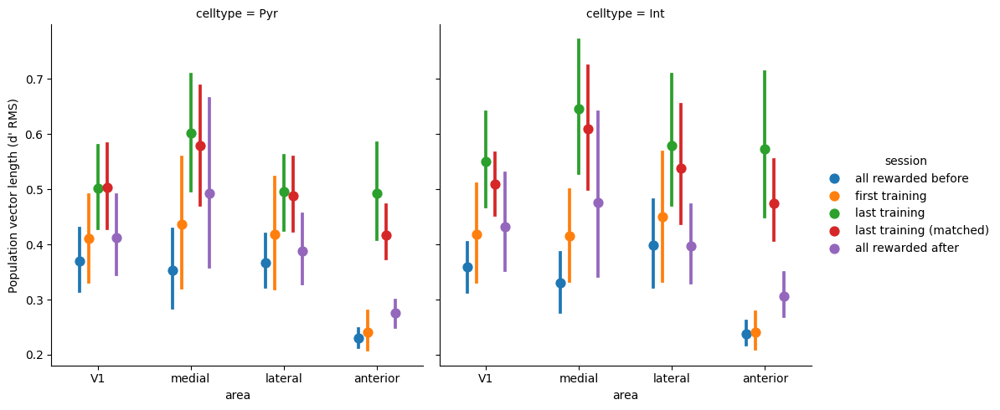

In [8]:
g = sns.catplot(data=dp_gain, x='area', y='signal_magnitude', col='celltype', hue='session', kind='point', width=4, aspect=1, dodge=.4, linestyle='none')
g.set_ylabels('Population vector length (d\' RMS)')

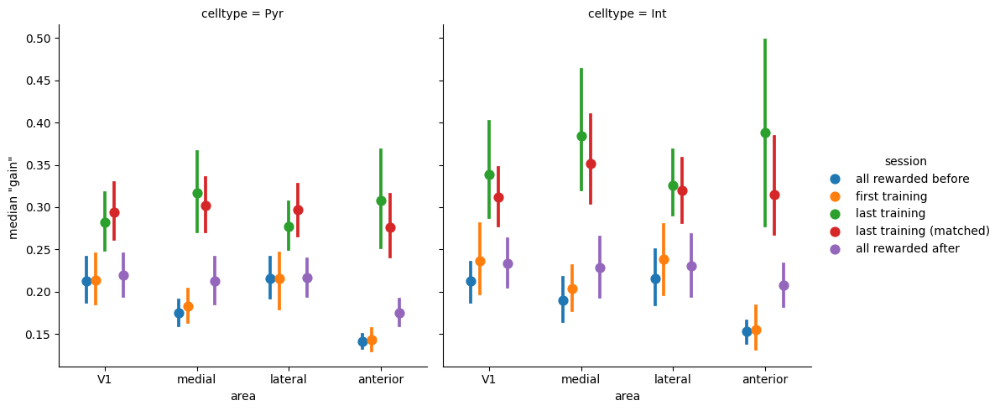

In [10]:
g = sns.catplot(data=dp_gain, x='area', y='median_gain', col='celltype', hue='session', kind='point', width=4, aspect=1, dodge=.4, linestyle='none')
g.set_ylabels('median "gain" ')

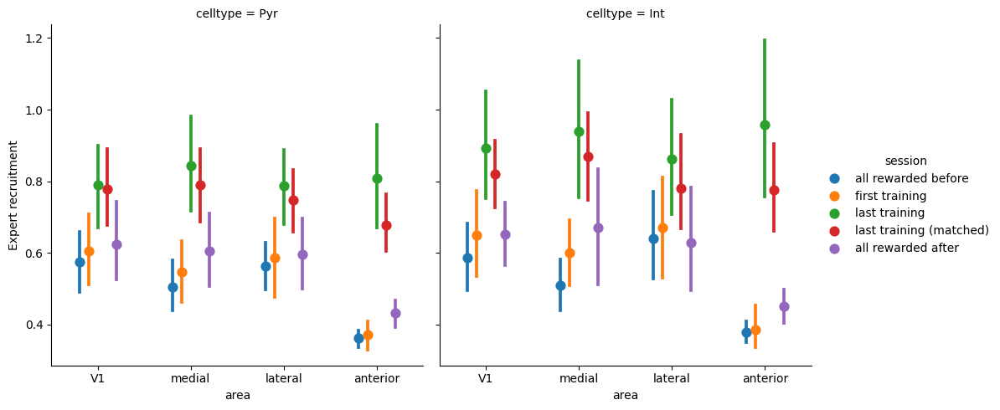

In [11]:
g = sns.catplot(data=dp_gain, x='area', y='p90_val', col='celltype', hue='session', kind='point', width=4, aspect=1, dodge=.4, linestyle='none')
g.set_ylabels('Expert recruitment')

In [34]:
dp_invariance_df = pd.read_csv(r"D:\mouseobj\overall\dp_proj_invariance_analysis.csv")
dp_invariance_df['blk'] = dp_invariance_df['blk'].astype(str)

In [35]:
dp_invariance_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   name        392 non-null    object 
 1   datexp      392 non-null    object 
 2   blk         392 non-null    object 
 3   session     392 non-null    object 
 4   celltype    392 non-null    object 
 5   area        392 non-null    object 
 6   invariance  392 non-null    float64
 7   angle       392 non-null    float64
 8   ei_angle    392 non-null    float64
dtypes: float64(3), object(6)
memory usage: 27.7+ KB


In [37]:
main_df = dp_gain.merge(dp_invariance_df, on=['name', 'datexp', 'blk', 'session', 'celltype', 'area'],)

In [38]:
main_df

,name,datexp,blk,session,celltype,area,signal_magnitude,median_gain,p90_val,invariance,angle,ei_angle
0,VG11,2024_10_15,4,all rewarded before,Pyr,V1,0.281559,0.173873,0.454992,0.092217,0.113661,0.327213
1,VG11,2024_10_15,4,all rewarded before,Int,V1,0.255080,0.170964,0.444941,0.000365,-0.024473,0.327213
2,VG11,2024_10_15,4,all rewarded before,Pyr,medial,0.245587,0.151223,0.388570,0.205363,0.247266,0.506519
3,VG11,2024_10_15,4,all rewarded before,Int,medial,0.210778,0.147968,0.335073,0.136953,0.191152,0.506519
4,VG11,2024_10_15,4,all rewarded before,Pyr,lateral,0.302092,0.175854,0.477655,0.071679,0.104142,0.328305
...,...,...,...,...,...,...,...,...,...,...,...,...
387,VGa9,2025_11_21,2,all rewarded after,Int,medial,0.493293,0.284186,0.775328,0.341924,0.434737,0.856297
388,VGa9,2025_11_21,2,all rewarded after,Pyr,lateral,0.396840,0.224589,0.632335,0.069900,0.143271,0.496681
389,VGa9,2025_11_21,2,all rewarded after,Int,lateral,0.360999,0.236729,0.594135,0.060159,0.153640,0.496681
390,VGa9,2025_11_21,2,all rewarded after,Pyr,anterior,0.300286,0.187987,0.484388,0.132367,0.268506,0.673957


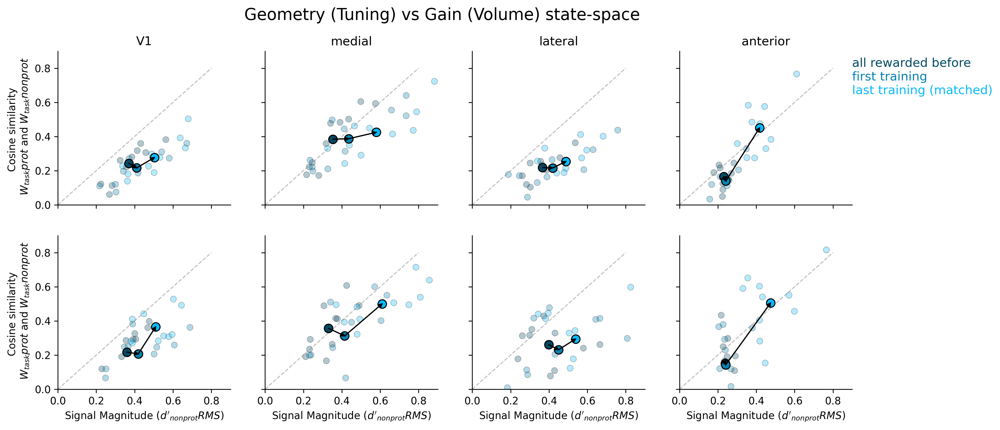

In [ ]:
palette = ["#034a64", "#0682b0", "#08bafb"]
session_names = ['first training', 'last training (matched)']
sessions_names_all = ['all rewarded before', 'first training', 'last training (matched)']
from scipy.stats import pearsonr
fig, axes = plt.subplots(2, len(areas), figsize=(14, 6), sharex=True, sharey=True, dpi=300)
all_means = np.zeros((len(areas), len(celltype), len(sessions_names_all), 2))
for iaa, area in enumerate(areas):
    axes[1, iaa].set_xlabel('Signal Magnitude $(d\'_{nonprot} RMS)$')
    axes[0, iaa].set_title(f"{area}")
    for ic, cell in enumerate(celltype):
        axes[ic,0].set_ylabel('Cosine similarity \n $W_{task}prot$ and $W_{task}nonprot$')
        for iss, session in enumerate(sessions_names_all):
            sub_df = main_df.query(f"area == '{area}' & session == '{session}' & celltype == '{cell}'")
            ax = axes[ic, iaa]
            ax.scatter(sub_df['signal_magnitude'], sub_df['angle'], alpha=0.3, color = palette[iss], edgecolors='black', linewidth=0.5,  zorder=0)
            means = (sub_df["signal_magnitude"].mean(), sub_df["angle"].mean())
            # add 45 line
            ax.plot([0, .8], [0, .8], color='gray', linestyle='--', linewidth=1, zorder=0, alpha=0.2)
            ax.scatter(*means, color=palette[iss], s=70, marker='o', edgecolors='black', linewidth=1)
            all_means[iaa, ic, iss] = means
            ax.set_ylim(0,.9)
            ax.set_xlim(0,.9)
                       
for iaa, area in enumerate(areas):
    for ic, cell in enumerate(celltype):
            origin = (all_means[iaa, ic, 0, 0], all_means[iaa, ic, 0, 1])
            direction = (all_means[iaa, ic, 1, 0] - all_means[iaa, ic, 0, 0], all_means[iaa, ic, 1, 1] - all_means[iaa, ic, 0, 1])
            axes[ic, iaa].arrow(origin[0], origin[1], direction[0], direction[1], head_width=0.02, head_length=0.02, fc='k', ec='k', linewidth=1, length_includes_head=True, zorder=1)
            origin = (all_means[iaa, ic, 1, 0], all_means[iaa, ic, 1, 1])
            direction = (all_means[iaa, ic, 2, 0] - all_means[iaa, ic, 1, 0], all_means[iaa, ic, 2, 1] - all_means[iaa, ic, 1, 1])
            axes[ic, iaa].arrow(origin[0], origin[1], direction[0], direction[1], head_width=0.02, head_length=0.02, fc='k', ec='k', linewidth=1, length_includes_head=True, zorder=1)
for lab in sessions_names_all:
    axes[0, 3].text(1, .9 - 0.09 * sessions_names_all.index(lab), lab, fontsize=12, transform=axes[0, 3].transAxes, color=palette[sessions_names_all.index(lab)])
fig.suptitle('Geometry (Tuning) vs Gain (Volume) state-space', fontsize=16)
sns.despine()

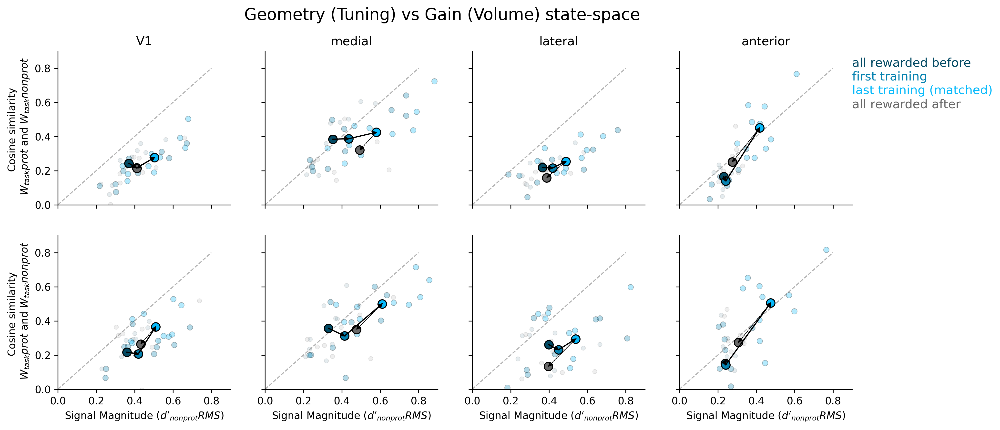

In [279]:
palette = ["#034a64", "#0682b0", "#08bafb", '#686868']
session_names = ['first training', 'last training (matched)']
sessions_names_all = ['all rewarded before', 'first training', 'last training (matched)', 'all rewarded after']
from scipy.stats import pearsonr
fig, axes = plt.subplots(2, len(areas), figsize=(14, 6), sharex=True, sharey=True, dpi=300)
all_means = np.zeros((len(areas), len(celltype), len(sessions_names_all), 2))
for iaa, area in enumerate(areas):
    axes[1, iaa].set_xlabel('Signal Magnitude $(d\'_{nonprot} RMS)$')
    axes[0, iaa].set_title(f"{area}")
    for ic, cell in enumerate(celltype):
        axes[ic,0].set_ylabel('Cosine similarity \n $W_{task}prot$ and $W_{task}nonprot$')
        for iss, session in enumerate(sessions_names_all):
            sub_df = main_df.query(f"area == '{area}' & session == '{session}' & celltype == '{cell}'")
            ax = axes[ic, iaa]
            if session in ['all rewarded before', 'all rewarded after']:
                ax.scatter(sub_df['signal_magnitude'], sub_df['angle'], alpha=0.1, color = palette[iss], edgecolors='black', linewidth=0.5,  zorder=0, s=18)
            else:
                ax.scatter(sub_df['signal_magnitude'], sub_df['angle'], alpha=0.3, color = palette[iss], edgecolors='black', linewidth=0.5,  zorder=0, s=30)
            means = (sub_df["signal_magnitude"].mean(), sub_df["angle"].mean())
            # add 45 line
            ax.plot([0, .8], [0, .8], color='gray', linestyle='--', linewidth=1, zorder=0, alpha=0.2)
            ax.scatter(*means, color=palette[iss], s=70, marker='o', edgecolors='black', linewidth=1)
            all_means[iaa, ic, iss] = means
            ax.set_ylim(0,.9)
            ax.set_xlim(0,.9)
                       
for iaa, area in enumerate(areas):
    for ic, cell in enumerate(celltype):
            origin = (all_means[iaa, ic, 0, 0], all_means[iaa, ic, 0, 1])
            direction = (all_means[iaa, ic, 1, 0] - all_means[iaa, ic, 0, 0], all_means[iaa, ic, 1, 1] - all_means[iaa, ic, 0, 1])
            axes[ic, iaa].arrow(origin[0], origin[1], direction[0], direction[1], head_width=0.02, head_length=0.02, fc='k', ec='k', linewidth=1, length_includes_head=True, zorder=1)
            origin = (all_means[iaa, ic, 1, 0], all_means[iaa, ic, 1, 1])
            direction = (all_means[iaa, ic, 2, 0] - all_means[iaa, ic, 1, 0], all_means[iaa, ic, 2, 1] - all_means[iaa, ic, 1, 1])
            axes[ic, iaa].arrow(origin[0], origin[1], direction[0], direction[1], head_width=0.02, head_length=0.02, fc='k', ec='k', linewidth=1, length_includes_head=True, zorder=1)
            origin = (all_means[iaa, ic, 2, 0], all_means[iaa, ic, 2, 1])
            direction = (all_means[iaa, ic, 3, 0] - all_means[iaa, ic, 2, 0], all_means[iaa, ic, 3, 1] - all_means[iaa, ic, 2, 1])
            axes[ic, iaa].arrow(origin[0], origin[1], direction[0], direction[1], head_width=0.02, head_length=0.02, fc='k', ec='k', linewidth=0.5, linestyle='--',
                                 length_includes_head=True, zorder=1)
for lab in sessions_names_all:
    axes[0, 3].text(1, .9 - 0.09 * sessions_names_all.index(lab), lab, fontsize=12, transform=axes[0, 3].transAxes, color=palette[sessions_names_all.index(lab)])
fig.suptitle('Geometry (Tuning) vs Gain (Volume) state-space', fontsize=16)
sns.despine()

* The Anterior "Scaffold" (Diagonal): Starts near the origin (low signal, low alignment). It moves diagonally toward the top-right. This shows that in this area, you cannot have "signal" without "structure"

    * most interneurons follow this pattern, suggesting that they are involved in both learning the categorical rule and modulating gain through attention (V1, medial, anterior).

* The Medial "Anchor" (Horizontal Shift): The Medial HVA starts "high" on the Y-axis (it already has the geometric rule) but "low" on the X-axis. Its trajectory follows a horizontal shift to the right. This shows that the Medial HVA has learned the categorical rule early on, and with attention (increased gain), it amplifies the signal magnitude without changing the geometric structure.

* The V1 "Sensory" (Baseline): V1 moves along the X-axis (increased gain from attention) but stays "flat" near the bottom of the Y-axis, it doesn't care about the categorical rule.


## How to test this? 

I think this suits perfectly for a Mixed Effects Linear model:

$ Tuning \sim Volume * area + (1 | session) + \epsilon$

Where Tuning is the cosine similarity between the task weights for the prot and non-prot stimuli, and Volume is the signal magnitude (RMS d') for the non-prot stimuli. The interaction term Volume * area will tell us if the relationship between gain and geometry differs across areas, while controlling for session-level variability with the random effect (1 | session).

In [174]:
main_df

,name,datexp,blk,session,celltype,area,signal_magnitude,median_gain,p90_val,invariance,angle,ei_angle,angle_delta,gain_delta
0,VG11,2024_10_15,4,all rewarded before,Pyr,V1,0.281559,0.173873,0.454992,0.092217,0.113661,0.327213,NaN,NaN
1,VG11,2024_10_15,4,all rewarded before,Int,V1,0.255080,0.170964,0.444941,0.000365,-0.024473,0.327213,NaN,NaN
2,VG11,2024_10_15,4,all rewarded before,Pyr,medial,0.245587,0.151223,0.388570,0.205363,0.247266,0.506519,NaN,NaN
3,VG11,2024_10_15,4,all rewarded before,Int,medial,0.210778,0.147968,0.335073,0.136953,0.191152,0.506519,NaN,NaN
4,VG11,2024_10_15,4,all rewarded before,Pyr,lateral,0.302092,0.175854,0.477655,0.071679,0.104142,0.328305,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
387,VGa9,2025_11_21,2,all rewarded after,Int,medial,0.493293,0.284186,0.775328,0.341924,0.434737,0.856297,NaN,NaN
388,VGa9,2025_11_21,2,all rewarded after,Pyr,lateral,0.396840,0.224589,0.632335,0.069900,0.143271,0.496681,NaN,NaN
389,VGa9,2025_11_21,2,all rewarded after,Int,lateral,0.360999,0.236729,0.594135,0.060159,0.153640,0.496681,NaN,NaN
390,VGa9,2025_11_21,2,all rewarded after,Pyr,anterior,0.300286,0.187987,0.484388,0.132367,0.268506,0.673957,NaN,NaN


In [188]:
reg_df = main_df.copy()

In [190]:
reg_df["mouse_id"] = reg_df["name"] 


lets filter out the data for only the sessions we care about, and chech for column types

In [248]:
# drop deltas 
reg_df.drop(columns=['angle_delta', 'gain_delta'], inplace=True)

In [250]:
reg_df.to_csv(r"D:\mouseobj\overall\gain_vs_geometry_df.csv", index=False)

In [302]:
reg_df["area"]  = pd.Categorical(reg_df["area"], categories=["V1", "lateral", "medial", "anterior"], ordered=True) # set area order by hierarchy?
reg_df["sig_gain_centered"] = reg_df["signal_magnitude"] - reg_df["signal_magnitude"].mean()

In [311]:
cleaned_reg_df = reg_df.query("session in ['first training', 'last training (matched)']") # only including the days that have progression

In [312]:
cleaned_reg_df

,name,datexp,blk,session,celltype,area,signal_magnitude,median_gain,p90_val,invariance,angle,ei_angle,mouse_id,sig_gain_centered
80,VG11,2024_10_16,2,first training,Pyr,V1,0.299881,0.180202,0.482464,0.111709,0.121009,0.532669,VG11,-0.136400
81,VG11,2024_10_16,2,first training,Int,V1,0.250748,0.158637,0.430295,0.070574,0.118991,0.532669,VG11,-0.185533
82,VG11,2024_10_16,2,first training,Pyr,medial,0.233183,0.139818,0.362869,0.188151,0.261922,0.578511,VG11,-0.203098
83,VG11,2024_10_16,2,first training,Int,medial,0.238456,0.154718,0.385579,0.098519,0.200848,0.578511,VG11,-0.197825
84,VG11,2024_10_16,2,first training,Pyr,lateral,0.337830,0.194351,0.540237,0.083041,0.130629,0.282887,VG11,-0.098451
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,VGa9,2025_11_20,2,last training (matched),Int,medial,0.748725,0.515358,1.234917,0.611181,0.495584,0.950771,VGa9,0.312444
316,VGa9,2025_11_20,2,last training (matched),Pyr,lateral,0.478161,0.307402,0.774075,0.187309,0.188729,0.692894,VGa9,0.041880
317,VGa9,2025_11_20,2,last training (matched),Int,lateral,0.526319,0.369001,0.935807,0.157408,0.177448,0.692894,VGa9,0.090038
318,VGa9,2025_11_20,2,last training (matched),Pyr,anterior,0.449762,0.295737,0.738079,0.541463,0.329356,0.878073,VGa9,0.013481


In [313]:
import statsmodels.formula.api as smf

# lets do it first for Pyr cells
exc = cleaned_reg_df.query("celltype == 'Pyr'")
model = smf.mixedlm("angle ~ (sig_gain_centered * area)", exc, groups=exc["mouse_id"])
#try differen methods 
results = model.fit()
print(results.summary())

                    Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         angle  
No. Observations:         80              Method:                     REML   
No. Groups:               10              Scale:                      0.0060 
Min. group size:          8               Log-Likelihood:             73.3056
Max. group size:          8               Converged:                  Yes    
Mean group size:          8.0                                                
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                           0.233    0.021 11.089 0.000  0.192  0.274
area[T.lateral]                    -0.008    0.025 -0.330 0.741 -0.057  0.040
area[T.medial]                      0.130    0.026  5.093 0.000  0.080  0.180
area[T

c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [314]:
inh = cleaned_reg_df.query("celltype == 'Int'")
model = smf.mixedlm("angle ~ (sig_gain_centered * area)", inh, groups=inh["mouse_id"])
results = model.fit()
print(results.summary())

                    Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         angle  
No. Observations:         80              Method:                     REML   
No. Groups:               10              Scale:                      0.0265 
Min. group size:          8               Log-Likelihood:             20.3765
Max. group size:          8               Converged:                  Yes    
Mean group size:          8.0                                                
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                           0.265    0.043  6.231 0.000  0.182  0.349
area[T.lateral]                    -0.026    0.053 -0.486 0.627 -0.130  0.078
area[T.medial]                      0.082    0.054  1.520 0.128 -0.024  0.189
area[T

c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


Basically these results say the following:
* Geometry arrangement is not a simple effect of gain increase alone (that would make the slope identical across areas)
* the interaction term for the exc Anterior HVa is .941 and significant, which means that the anterior HVa is "doing more" with the signal gain increase, in terms of improving the geometry alignment, all the other regions increase with a slope of .644, so the slope for the anterior area is 1.585 , anterior pyramidal cells are ~2.5 more efficient at converting signal gain into categorical tuning.
* What happens with interneurons?
    * all the areas increase their tuning by gain, the std error is bigger, that could be because the inhibitory response is more heterogeneous, and not every interneuron is joining the scaffold, only an "expert" subset of them.

To determine if the observed increase in categorical tuning was a byproduct of increased signal magnitude (a scaling artifact) or a fundamental structural reorganization, we employed a Linear Mixed-Effects Model testing the interaction between signal volume and brain area. We found a significant interaction in the Anterior HVA ($p < 0.001$), demonstrating that the rate of geometric alignment per unit of signal gain is significantly higher in this region than in primary sensory or medial high-visual areas. This proves that learning in the Anterior HVA involves a specific coordinate transformation of the neural manifold rather than a global boost in signal-to-noise ratio 

To do: repeat the same analysis but only using the top 25% of cells

## Is the E-I alignment due to gain increases alone?

In [290]:
import statsmodels.api as sm
import pandas as pd
import pingouin as pg

def get_residuals(data, target_col, control_col):
    """Returns the part of target_col that is NOT explained by control_col."""
    model = sm.OLS(data[target_col], sm.add_constant(data[control_col])).fit()
    return model.resid

In [293]:
ei_df = reg_df.copy()
ei_df = ei_df.query("session in ['all rewarded before', 'first training', 'last training (matched)']")
ei_df

,name,datexp,blk,session,celltype,area,signal_magnitude,median_gain,p90_val,invariance,angle,ei_angle,mouse_id
0,VG11,2024_10_15,4,all rewarded before,Pyr,V1,0.281559,0.173873,0.454992,0.092217,0.113661,0.327213,VG11
1,VG11,2024_10_15,4,all rewarded before,Int,V1,0.255080,0.170964,0.444941,0.000365,-0.024473,0.327213,VG11
2,VG11,2024_10_15,4,all rewarded before,Pyr,medial,0.245587,0.151223,0.388570,0.205363,0.247266,0.506519,VG11
3,VG11,2024_10_15,4,all rewarded before,Int,medial,0.210778,0.147968,0.335073,0.136953,0.191152,0.506519,VG11
4,VG11,2024_10_15,4,all rewarded before,Pyr,lateral,0.302092,0.175854,0.477655,0.071679,0.104142,0.328305,VG11
...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,VGa9,2025_11_20,2,last training (matched),Int,medial,0.748725,0.515358,1.234917,0.611181,0.495584,0.950771,VGa9
316,VGa9,2025_11_20,2,last training (matched),Pyr,lateral,0.478161,0.307402,0.774075,0.187309,0.188729,0.692894,VGa9
317,VGa9,2025_11_20,2,last training (matched),Int,lateral,0.526319,0.369001,0.935807,0.157408,0.177448,0.692894,VGa9
318,VGa9,2025_11_20,2,last training (matched),Pyr,anterior,0.449762,0.295737,0.738079,0.541463,0.329356,0.878073,VGa9


          n         r          CI95%    p-val
pearson  30  0.342293  [-0.03, 0.63]  0.06913 V1
          n         r          CI95%     p-val
pearson  30  0.018873  [-0.35, 0.38]  0.922591 medial
          n         r          CI95%     p-val
pearson  30  0.244728  [-0.13, 0.56]  0.200723 lateral
          n         r          CI95%    p-val
pearson  30  0.225837  [-0.15, 0.55]  0.23881 anterior


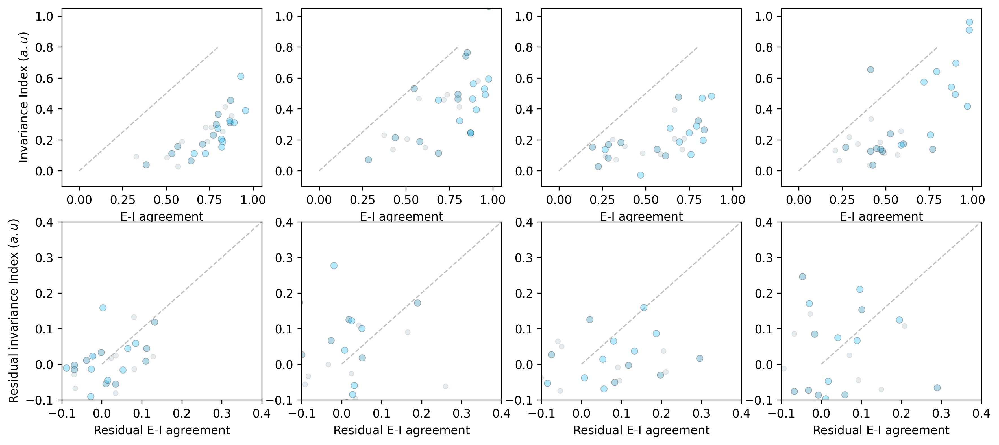

In [321]:
palette = ["#034a64", "#0682b0", "#08bafb", '#686868']
session_names = ['first training', 'last training (matched)']
sessions_names_all = ['all rewarded before', 'first training', 'last training (matched)']
fig, axes = plt.subplots(2, len(areas), figsize=(14, 6), dpi=300)
axes[0,0].set_ylabel('Invariance Index $(a.u)$')
axes[1,0].set_ylabel('Residual invariance Index $(a.u)$')
only_exc = ei_df.query("celltype == 'Pyr'")
for iaa, area in enumerate(areas):
    axes[0, iaa].set_xlabel('E-I agreement')
    axes[1, iaa].set_xlabel('Residual E-I agreement')
    only_exc_area = only_exc.query(f"area == '{area}'")
    overall_res_angle = get_residuals(only_exc_area, 'ei_angle', 'signal_magnitude')
    overall_res_inv = get_residuals(only_exc_area, 'invariance', 'signal_magnitude')
    print(pg.partial_corr(data=only_exc_area, x='ei_angle', y='invariance', covar='signal_magnitude', method='pearson'), area)
    for iss, session in enumerate(sessions_names_all):
        sub_df = only_exc.query(f"area == '{area}' & session == '{session}'")
        ax = axes[0, iaa]
        if session in ['all rewarded before']:
            ax.scatter(sub_df['ei_angle'], sub_df['invariance'], alpha=0.1, color = palette[iss], edgecolors='black', linewidth=0.5,  zorder=0, s=18)
        else:
            ax.scatter(sub_df['ei_angle'], sub_df['invariance'], alpha=0.3, color = palette[iss], edgecolors='black', linewidth=0.5,  zorder=0, s=30)
        # add 45 line
        ax.plot([0, .8], [0, .8], color='gray', linestyle='--', linewidth=1, zorder=0, alpha=0.2)
        #make the first row to share y axis
        ax.set_ylim(-0.1,1.05)
        ax.set_xlim(-.1,1.05)
        # add 45 line
        res_angle = get_residuals(sub_df, 'ei_angle', 'signal_magnitude')
        res_inv = get_residuals(sub_df, 'invariance', 'signal_magnitude')
        ax = axes[1, iaa]
        if session in ['all rewarded before']:
            ax.scatter(res_angle, res_inv, alpha=0.1, color = palette[iss], edgecolors='black', linewidth=0.5,  zorder=0, s=18)
        else:
            ax.scatter(res_angle, res_inv, alpha=0.3, color = palette[iss], edgecolors='black', linewidth=0.5,  zorder=0, s=30)
        ax.plot([0, .8], [0, .8], color='gray', linestyle='--', linewidth=1, zorder=0, alpha=0.2)
        ax.set_ylim(-0.1,.40)
        ax.set_xlim(-.1, .40)

# Re do the analysis but with the top 25% of cells by d'

In [738]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def dp_inv(r1, r2):
    mu1 = r1.mean()
    mu2 = r2.mean()
    std1 = r1.std() + np.finfo(np.float64).tiny
    std2 = r2.std() + np.finfo(np.float64).tiny
    #compute the train dprime
    dp = 2 * ((mu1 - mu2) / (std1 + std2))
    return dp

def get_projections(m, selection, trial_dict):
    all_means = m.interp_spks[:,:,:100].mean(2) # take the avg of the first 100 position of the corridor.
    all_means = all_means[selection,:] #filter neurons by selection vector (area * celltype) or any other boolean array
    all_means = all_means.T #trials, neurons
    Rprot, NRprot, Rrest, NRrest = trial_dict["rewarded"], trial_dict["non rewarded"], trial_dict["rewarded test"], trial_dict["non rewarded test"]
    Eprot = all_means[Rprot[::2]].mean(0)
    ENRprot = all_means[NRprot[::2]].mean(0)
    Erest = all_means[Rrest]
    ENRrest = all_means[NRrest]
    Eprot_test = all_means[Rprot[1::2]].mean(0)
    ENRprot_test = all_means[NRprot[1::2]].mean(0)
    w_proto = Eprot_test - ENRprot_test #compute Wtask with half of the prot trials
    w_nonproto = np.mean(Erest, axis=0) - np.mean(ENRrest, axis=0) #compute Wtask with the rest of the trials
    cos_angle = np.dot(w_proto, w_nonproto) / (np.linalg.norm(w_proto.flatten()) * np.linalg.norm(w_nonproto.flatten()) + 1e-6) #cos sim between the two
    cd = Eprot - ENRprot #compute the wtask vector with first half of the prot trials
    w = cd / (np.linalg.norm(cd) + np.finfo(np.float64).tiny)

    proj_R_prot = np.dot(all_means[Rprot[1::2]], w) #get scores by projecting the held-out prot trials onto wtask
    proj_NR_prot = np.dot(all_means[NRprot[1::2]], w) #get scores by projecting the held-out non-prot trials onto wtask
    proj_R_rest = np.dot(all_means[Rrest], w) #get scores by projecting the non prot trials onto wtask
    proj_NR_rest = np.dot(all_means[NRrest], w) #get scores by projecting the non prot trials onto wtask
    return cos_angle, proj_R_prot, proj_NR_prot, proj_R_rest, proj_NR_rest

def ei_alignment(m, area,  trial_dict, selective_neurons= None):
    from scipy.stats import pearsonr
    all_means = m.interp_spks[:,:,:100].mean(2)
    if selective_neurons is None:
        selective_neurons = np.ones(all_means.shape[0], dtype=bool)
    selection = area * selective_neurons
    all_means = all_means[selection,:]
    all_means = all_means.T  
    is_exc = np.logical_not(m.isred[selection, 0]).astype(bool)
    is_inh = m.isred[selection, 0].astype(bool)
    means_exc = all_means[:, is_exc]  # Excitatory neurons
    means_inh = all_means[:, is_inh]  # Inhibitory neuron
    Rprot, NRprot, Rrest, NRrest = trial_dict["rewarded"], trial_dict["non rewarded"], trial_dict["rewarded test"], trial_dict["non rewarded test"]
    w_exc = means_exc[Rprot].mean(0) - means_exc[NRprot].mean(0)
    w_inh = means_inh[Rprot].mean(0) - means_inh[NRprot].mean(0)
    
    np_indices = np.concatenate([Rrest, NRrest])
    scores_exc = means_exc[np_indices] @ w_exc
    scores_inh = means_inh[np_indices] @ w_inh
    alignment_r, _ = pearsonr(scores_exc, scores_inh)
    return alignment_r

def get_percentile_vals(data, percentiles):
    return [np.percentile(data, p) for p in percentiles]


In [ ]:
trial_dict = m.trial_dict # dict with trial indices for different conditions
all_means = m.interp_spks[:,:,:100].mean(2) # take the avg of the first 100 position of the corridor.
all_means = all_means[selection,:] #filter neurons by selection vector (area * celltype * dprime) or any other boolean array
all_means = all_means.T #trials, neurons
Rprot, NRprot, Rrest, NRrest = trial_dict["rewarded"], trial_dict["non rewarded"], trial_dict["rewarded test"], trial_dict["non rewarded test"]
Eprot = all_means[Rprot[::2]].mean(0)
ENRprot = all_means[NRprot[::2]].mean(0)
Erest = all_means[Rrest]
ENRrest = all_means[NRrest]
cd = Eprot - ENRprot #compute the wtask vector with first half of the prot trials
w = cd / (np.linalg.norm(cd) + np.finfo(np.float64).tiny)

proj_R_prot = np.dot(all_means[Rprot[1::2]], w) #get scores by projecting the held-out rew prot trials onto wtask
proj_NR_prot = np.dot(all_means[NRprot[1::2]], w) #get scores by projecting the held-out non rew prot trials onto wtask
proj_R_rest = np.dot(all_means[Rrest], w) #get scores by projecting the non prot trials onto wtask
proj_NR_rest = np.dot(all_means[NRrest], w) #get scores by projecting the non prot trials onto wtask
sep_prot = np.mean(proj_R_prot) - np.mean(proj_NR_prot)
sep_rest = np.mean(proj_R_rest) - np.mean(proj_NR_rest)
ii_centroid = sep_rest / (sep_prot + 1e-6)


In [ ]:
rows = []
percentils_dp = np.ones((n_sessions+1, nmice, nareas, ncelltypes, 99)) * np.nan
obj_path = Path(r"D:\mouseobj")
for iss, sess in enumerate(sessions_names):
    if sess == 'last training (matched)':
        session = 'last training'
    else:
        session = sess
    d = working_dbase.query(f"session == '{session}'")
    print(f"Processing: {sess}")
    for i, (_, row) in enumerate(d.iterrows()):
        name, datexp, blk = row["mname"], row["datexp"], row["blk"]
        save_pth = obj_path.joinpath(name,datexp,blk)
        m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")
        if sess == 'last training (matched)':
            t_dict = get_matched_trials(m)
            dp_nonprot = np.load(save_pth.joinpath("dp_rest_nosplit_matched.npy"))
        else:
            t_dict = m.trial_dict
            dp_nonprot = np.load(save_pth.joinpath("dp_rest_nosplit.npy"))
        for iaa, area in enumerate(areas):
            ia = utils.get_region_idx(m.iarea, area)
            for ic, cell in enumerate(celltype):
                sel_type = np.logical_not(m.isred[:, 0]).astype(bool) if cell == 'Pyr' else m.isred[:, 0].astype(bool)
                pstv_tsh, ngtv_tsh = utils.get_dp_thresholds(dp_nonprot[ia*sel_type], tsh=75) # top 25% and bottom 25%
                prefer_r = (dp_nonprot>=pstv_tsh)
                prefer_nr = (dp_nonprot<=ngtv_tsh)
                selective_neurons = prefer_r + prefer_nr
                alignment = ei_alignment(m, ia, selective_neurons, t_dict)
                selection = ia * sel_type * selective_neurons
                dp_sel = dp_nonprot[selection]
                signal_magnitude = np.sqrt(np.mean(dp_sel**2))
                percentils_dp[iss, i, iaa, ic, :] = get_percentile_vals(np.abs(dp_sel), np.arange(1, 100))
                angle, proj_R_prot, proj_NR_prot, proj_R_rest, proj_NR_rest = get_projections(m, selection, t_dict)
                dp_prot = dp_inv(proj_R_prot, proj_NR_prot)
                dp_rest = dp_inv(proj_R_rest, proj_NR_rest)
                dp_inv_value = dp_rest / (dp_prot + 1e-6)
                rows.append({'name': name, 'name_id': row['name_round'], 'datexp': datexp, 'blk': blk, 
                             'session': sess, 'celltype': cell, 'area': area, 
                             'invariance': dp_inv_value, 'angle': angle, 'ei_angle': alignment, 'signal_magnitude': signal_magnitude})
    clear_output(wait=True)
topdp_gainvsgeom_df = pd.DataFrame(rows)

Processing: all rewarded after
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_01\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_15\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG14\20

In [336]:
topdp_gainvsgeom_df

,name,name_id,datexp,blk,session,celltype,area,invariance,angle,ei_angle,signal_magnitude
0,VG11,VG11_1,2024_10_15,4,all rewarded before,Pyr,V1,0.131461,0.147635,0.197284,0.383753
1,VG11,VG11_1,2024_10_15,4,all rewarded before,Int,V1,0.008582,-0.027674,0.236619,0.339148
2,VG11,VG11_1,2024_10_15,4,all rewarded before,Pyr,medial,0.293082,0.317498,0.443323,0.335971
3,VG11,VG11_1,2024_10_15,4,all rewarded before,Int,medial,0.294297,0.228548,0.435325,0.281617
4,VG11,VG11_1,2024_10_15,4,all rewarded before,Pyr,lateral,0.124757,0.129377,0.250377,0.414948
...,...,...,...,...,...,...,...,...,...,...,...
387,VGa9,VGa9_1,2025_11_21,2,all rewarded after,Int,medial,0.535907,0.540535,0.902635,0.671108
388,VGa9,VGa9_1,2025_11_21,2,all rewarded after,Pyr,lateral,0.083892,0.180457,0.469337,0.546250
389,VGa9,VGa9_1,2025_11_21,2,all rewarded after,Int,lateral,0.066100,0.207138,0.460810,0.489054
390,VGa9,VGa9_1,2025_11_21,2,all rewarded after,Pyr,anterior,0.188228,0.334038,0.678948,0.411998


In [338]:
topdp_gainvsgeom_df.to_csv(r"D:\mouseobj\overall\topdp_gain_vs_geometry_analysis.csv", index=False)
np.save(r"D:\mouseobj\overall\topdp_percentile_shift.npy", percentils_dp)

In [748]:
def get_feature_values(df: pd.DataFrame, area: str, celltype: str, session: str, feature: str) -> np.ndarray:
    a = df.query(f"session == '{session}'")
    b = a.query(f"area == '{area}' & celltype == '{celltype}'")
    feature_values= b[feature].values
    return feature_values

In [339]:
df_no34 = topdp_gainvsgeom_df.query("name != 'VG34'")

In [342]:
sessions = ['first training', 'last training', 'last training (matched)']
areas = ['V1', 'medial', 'lateral', 'anterior']
celltype = ['Pyr', 'Int']
nmice = 10
angles = {}
for sess in sessions: 
    angle = np.empty((nmice, len(areas), len(celltype)))
    for ia, area in enumerate(areas):
        for ic, ctype in enumerate(celltype):
            inv = get_feature_values(topdp_gainvsgeom_df, area, ctype, sess, 'angle')
            #store values
            angle[:,ia,ic] = inv
    angles[sess] = angle

sessions = ['all rewarded before', 'all rewarded after']
nmice = 9
for sess in sessions: 
    angle = np.empty((nmice, len(areas), len(celltype)))
    for ia, area in enumerate(areas):
        for ic, ctype in enumerate(celltype):
            inv = get_feature_values(df_no34, area, ctype, sess, 'angle')
            #store values
            angle[:,ia,ic] = inv
    angles[sess] = angle

In [437]:
sessions = ['first training', 'last training', 'last training (matched)']
areas = ['V1', 'medial', 'lateral', 'anterior']
celltype = ['Pyr', 'Int']
nmice = 10
invariances = {}
for sess in sessions: 
    invariance = np.empty((nmice, len(areas), len(celltype)))
    for ia, area in enumerate(areas):
        for ic, ctype in enumerate(celltype):
            inv = get_feature_values(topdp_gainvsgeom_df, area, ctype, sess, 'invariance')
            #store values
            invariance[:,ia,ic] = inv
    invariances[sess] = invariance

sessions = ['all rewarded before', 'all rewarded after']
nmice = 9
for sess in sessions: 
    invariance = np.empty((nmice, len(areas), len(celltype)))
    for ia, area in enumerate(areas):
        for ic, ctype in enumerate(celltype):
            inv = get_feature_values(df_no34, area, ctype, sess, 'invariance')
            #store values
            invariance[:,ia,ic] = inv
    invariances[sess] = invariance

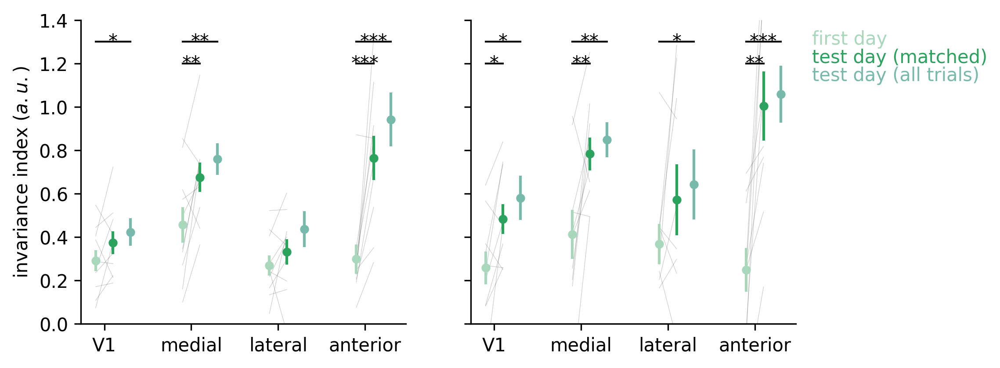

In [451]:
from src import fig1
gis_first = invariances['first training']
gis_last = invariances['last training']
gis_last_m = invariances['last training (matched)']
fig, ax = plt.subplots(1,2, figsize=(7,3), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=1.2, sig_line_control=1.3)
ax[0].set_ylim(0,1.4)
sns.despine()
plt.savefig(r"C:\Users\labadmin\Pictures\topdp_invariance_comparison.svg", dpi=300)

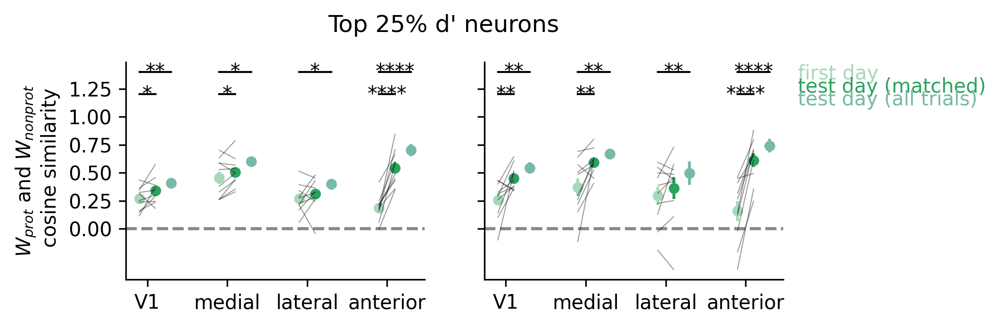

In [360]:
gis_first = angles['first training']
gis_last = angles['last training']
gis_last_m = angles['last training (matched)']
fig, ax = plt.subplots(1,2, figsize=(6,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=1.2, sig_line_control=1.4, ylabel='$W_{prot}$ and $W_{nonprot}$ \n cosine similarity')
fig.suptitle('Top 25% d\' neurons', y=1.05)
sns.despine()

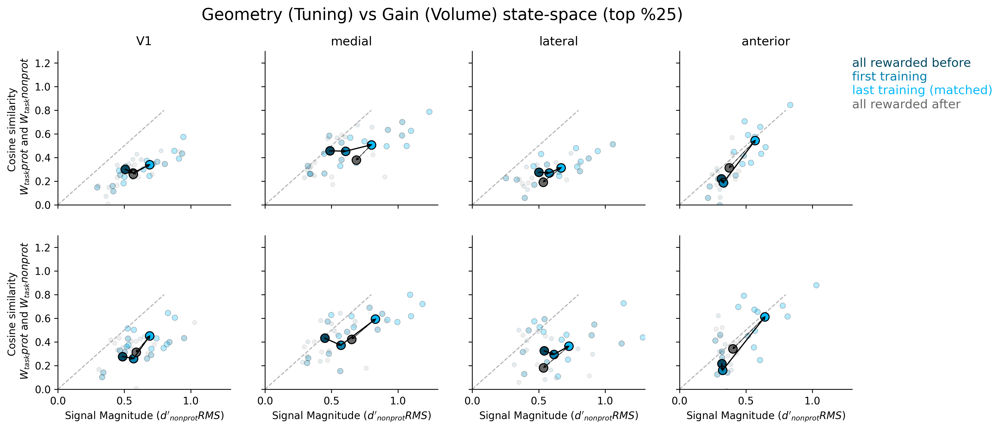

In [355]:
palette = ["#034a64", "#0682b0", "#08bafb", '#686868']
session_names = ['first training', 'last training (matched)']
sessions_names_all = ['all rewarded before', 'first training', 'last training (matched)', 'all rewarded after']
fig, axes = plt.subplots(2, len(areas), figsize=(14, 6), sharex=True, sharey=True, dpi=300)
all_means = np.zeros((len(areas), len(celltype), len(sessions_names_all), 2))
for iaa, area in enumerate(areas):
    axes[1, iaa].set_xlabel('Signal Magnitude $(d\'_{nonprot} RMS)$')
    axes[0, iaa].set_title(f"{area}")
    for ic, cell in enumerate(celltype):
        axes[ic,0].set_ylabel('Cosine similarity \n $W_{task}prot$ and $W_{task}nonprot$')
        for iss, session in enumerate(sessions_names_all):
            sub_df = topdp_gainvsgeom_df.query(f"area == '{area}' & session == '{session}' & celltype == '{cell}'")
            ax = axes[ic, iaa]
            if session in ['all rewarded before', 'all rewarded after']:
                ax.scatter(sub_df['signal_magnitude'], sub_df['angle'], alpha=0.1, color = palette[iss], edgecolors='black', linewidth=0.5,  zorder=0, s=18)
            else:
                ax.scatter(sub_df['signal_magnitude'], sub_df['angle'], alpha=0.3, color = palette[iss], edgecolors='black', linewidth=0.5,  zorder=0, s=30)
            means = (sub_df["signal_magnitude"].mean(), sub_df["angle"].mean())
            # add 45 line
            ax.plot([0, .8], [0, .8], color='gray', linestyle='--', linewidth=1, zorder=0, alpha=0.2)
            ax.scatter(*means, color=palette[iss], s=70, marker='o', edgecolors='black', linewidth=1)
            all_means[iaa, ic, iss] = means
            ax.set_ylim(0, 1.3)
            ax.set_xlim(0, 1.3)
                       
for iaa, area in enumerate(areas):
    for ic, cell in enumerate(celltype):
            origin = (all_means[iaa, ic, 0, 0], all_means[iaa, ic, 0, 1])
            direction = (all_means[iaa, ic, 1, 0] - all_means[iaa, ic, 0, 0], all_means[iaa, ic, 1, 1] - all_means[iaa, ic, 0, 1])
            axes[ic, iaa].arrow(origin[0], origin[1], direction[0], direction[1], head_width=0.02, head_length=0.02, fc='k', ec='k', linewidth=1, length_includes_head=True, zorder=1)
            origin = (all_means[iaa, ic, 1, 0], all_means[iaa, ic, 1, 1])
            direction = (all_means[iaa, ic, 2, 0] - all_means[iaa, ic, 1, 0], all_means[iaa, ic, 2, 1] - all_means[iaa, ic, 1, 1])
            axes[ic, iaa].arrow(origin[0], origin[1], direction[0], direction[1], head_width=0.02, head_length=0.02, fc='k', ec='k', linewidth=1, length_includes_head=True, zorder=1)
            origin = (all_means[iaa, ic, 2, 0], all_means[iaa, ic, 2, 1])
            direction = (all_means[iaa, ic, 3, 0] - all_means[iaa, ic, 2, 0], all_means[iaa, ic, 3, 1] - all_means[iaa, ic, 2, 1])
            axes[ic, iaa].arrow(origin[0], origin[1], direction[0], direction[1], head_width=0.02, head_length=0.02, fc='k', ec='k', linewidth=0.5, linestyle='-.',
                                 length_includes_head=True, zorder=1)
for lab in sessions_names_all:
    axes[0, 3].text(1, .9 - 0.09 * sessions_names_all.index(lab), lab, fontsize=12, transform=axes[0, 3].transAxes, color=palette[sessions_names_all.index(lab)])
fig.suptitle('Geometry (Tuning) vs Gain (Volume) state-space (top %25)', fontsize=16)
sns.despine()

In [356]:
topdp_gainvsgeom_df["area"]  = pd.Categorical(topdp_gainvsgeom_df["area"], categories=["V1", "lateral", "medial", "anterior"], ordered=True) # set area order by hierarchy?
topdp_gainvsgeom_df["sig_gain_centered"] = topdp_gainvsgeom_df["signal_magnitude"] - topdp_gainvsgeom_df["signal_magnitude"].mean()
cleaned_reg_df = reg_df.query("session in ['first training', 'last training (matched)']") 

In [357]:
exc = cleaned_reg_df.query("celltype == 'Pyr'")
model = smf.mixedlm("angle ~ (sig_gain_centered * area)", exc, groups=exc["mouse_id"])
#try differen methods 
results = model.fit()
print(results.summary())

                    Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         angle  
No. Observations:         80              Method:                     REML   
No. Groups:               10              Scale:                      0.0060 
Min. group size:          8               Log-Likelihood:             73.3056
Max. group size:          8               Converged:                  Yes    
Mean group size:          8.0                                                
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                           0.233    0.021 11.089 0.000  0.192  0.274
area[T.lateral]                    -0.008    0.025 -0.330 0.741 -0.057  0.040
area[T.medial]                      0.130    0.026  5.093 0.000  0.080  0.180
area[T

c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [358]:
exc = cleaned_reg_df.query("celltype == 'Int'")
model = smf.mixedlm("angle ~ (sig_gain_centered * area)", exc, groups=exc["mouse_id"])
#try differen methods 
results = model.fit()
print(results.summary())

                    Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         angle  
No. Observations:         80              Method:                     REML   
No. Groups:               10              Scale:                      0.0265 
Min. group size:          8               Log-Likelihood:             20.3765
Max. group size:          8               Converged:                  Yes    
Mean group size:          8.0                                                
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                           0.265    0.043  6.231 0.000  0.182  0.349
area[T.lateral]                    -0.026    0.053 -0.486 0.627 -0.130  0.078
area[T.medial]                      0.082    0.054  1.520 0.128 -0.024  0.189
area[T

c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


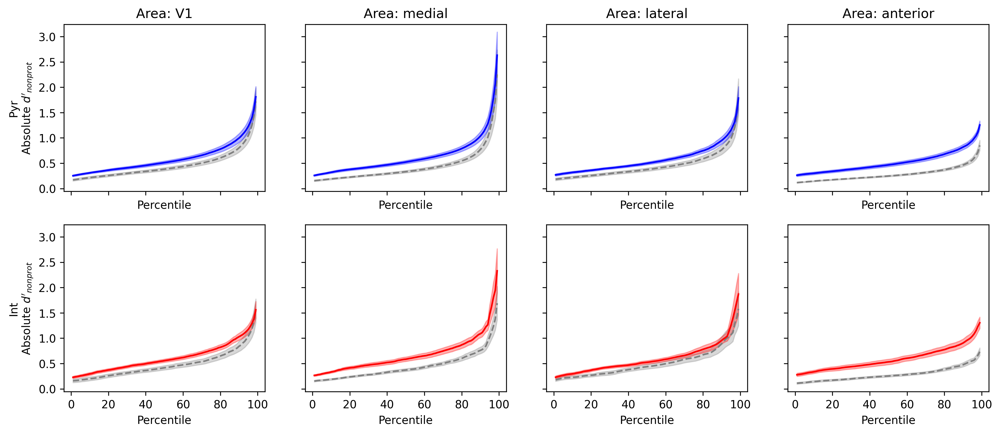

In [371]:
from scipy.stats import sem
first_training = percentils_dp[1]
last_training_matched = percentils_dp[3]
average_mice = first_training.mean(0)
average_mice_last = last_training_matched.mean(0)
sem_mice = sem(first_training, axis=0)
sem_mice_last = sem(last_training_matched, axis=0)
fig, axes = plt.subplots(len(celltype), len(areas), figsize=(15, 6), dpi=300, sharey=True, sharex=True)
for ia, area in enumerate(areas):
    for ic, ctype in enumerate(celltype):
        ax = axes[ic, ia]
        ax.fill_between(np.arange(1, 100), average_mice[ia, ic, :] - sem_mice[ia, ic, :], average_mice[ia, ic, :] + sem_mice[ia, ic, :], color='gray', alpha=0.3)
        ax.fill_between(np.arange(1, 100), average_mice_last[ia, ic, :] - sem_mice_last[ia, ic, :], average_mice_last[ia, ic, :] + sem_mice_last[ia, ic, :], color='blue' if ctype=='Pyr' else 'red', alpha=0.3)
        ax.plot(np.arange(1, 100), average_mice[ia, ic, :], color='gray', linestyle='--', label='First Training')
        ax.plot(np.arange(1, 100), average_mice_last[ia, ic, :], color='blue' if ctype=='Pyr' else 'red', label='Last Training (matched)')
        if ic == 0:
            ax.set_title(f"Area: {area}")
        if ia == 0:
            ax.set_ylabel(f"{ctype}" + "\nAbsolute $d'_{nonprot}$")
        ax.set_xlabel("Percentile")

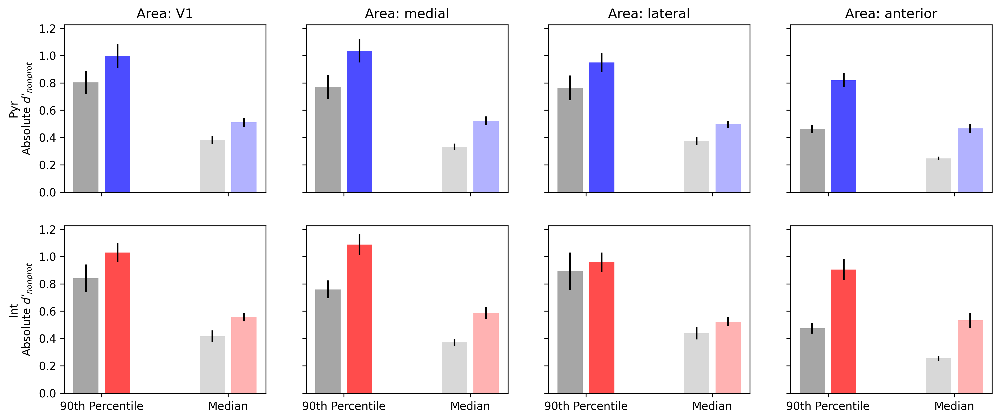

In [374]:
first_training_p90 = percentils_dp[1, :, :, :, 89]
last_training_matched_p90 = percentils_dp[3, :, :, :, 89]
first_training_median = percentils_dp[1, :, :, :, 49]
last_training_matched_median = percentils_dp[3, :, :, :, 49]
avg_first_p90 = first_training_p90.mean(0)
avg_last_matched_p90 = last_training_matched_p90.mean(0)
avg_first_median = first_training_median.mean(0)
avg_last_matched_median = last_training_matched_median.mean(0)
sem_first_p90 = sem(first_training_p90, axis=0)
sem_last_matched_p90 = sem(last_training_matched_p90, axis=0)
sem_first_median = sem(first_training_median, axis=0)
sem_last_matched_median = sem(last_training_matched_median, axis=0)
fig, axes = plt.subplots(len(celltype), len(areas), figsize=(15, 6), dpi=300, sharey=True, sharex=True)
for ia, area in enumerate(areas):
    for ic, ctype in enumerate(celltype):
        ax = axes[ic, ia]
        ax.bar(0, avg_first_p90[ia, ic], yerr=sem_first_p90[ia, ic], color='gray', alpha=0.7, width=0.4, label='First Training')
        ax.bar(0.5, avg_last_matched_p90[ia, ic], yerr=sem_last_matched_p90[ia, ic], color='blue' if ctype=='Pyr' else 'red', alpha=0.7, width=0.4, label='Last Training (matched)')
        ax.bar(2, avg_first_median[ia, ic], yerr=sem_first_median[ia, ic], color='gray', alpha=0.3, width=0.4)
        ax.bar(2.5, avg_last_matched_median[ia, ic],    yerr=sem_last_matched_median[ia, ic], color='blue' if ctype=='Pyr' else 'red', alpha=0.3, width=0.4)
        if ic == 0:
            ax.set_title(f"Area: {area}")
        if ia == 0:
            ax.set_ylabel(f"{ctype}" + "\nAbsolute $d'_{nonprot}$")
        ax.set_xticks([0.25, 2.25], labels=['90th Percentile', 'Median'])   

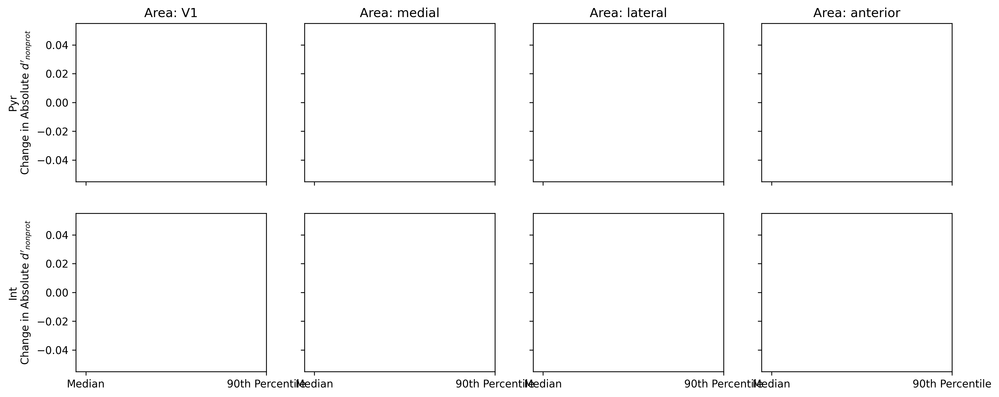

In [542]:
first_training_p90 = percentils_dp[1, :, :, :, 89]
last_training_matched_p90 = percentils_dp[3, :, :, :, 89]
first_training_median = percentils_dp[1, :, :, :, 49]
last_training_matched_median = percentils_dp[3, :, :, :, 49]
delta_p90 = last_training_matched_p90 - first_training_p90
delta_median = last_training_matched_median - first_training_median
mean_delta_p90 = delta_p90.mean(0)
mean_delta_median = delta_median.mean(0)
sem_delta_p90 = sem(delta_p90, axis=0)
sem_delta_median = sem(delta_median, axis=0)
fig, axes = plt.subplots(len(celltype), len(areas), figsize=(15, 6), dpi=300, sharey=True, sharex=True)
for ia, area in enumerate(areas):
    for ic, ctype in enumerate(celltype):
        ax = axes[ic, ia]
        ax.errorbar(1, mean_delta_p90[ia, ic], yerr=sem_delta_p90[ia, ic], fmt='o', color='blue' if ctype=='Pyr' else 'red', label='90th Percentile')
        ax.errorbar(0, mean_delta_median[ia, ic], yerr=sem_delta_median[ia, ic], fmt='o', color='blue' if ctype=='Pyr' else 'red', label='Median')
        if ic == 0:
            ax.set_title(f"Area: {area}")
        if ia == 0:
            ax.set_ylabel(f"{ctype}" + "\nChange in Absolute $d'_{nonprot}$")
        ax.set_xticks([1, 0], labels=['90th Percentile', 'Median'])

In [393]:
def dprime_cell(response, condition1, condition2, discrimination_region=(0,125), subpop=None):
    """
    Compute the d-prime for a single cell.
    """
    response = response[:,:,discrimination_region[0]:discrimination_region[1]].mean(2)
    r1 = response[:, condition1]
    r2 = response[:, condition2]
    if subpop is not None:
        r1 = r1[subpop]
        r2 = r2[subpop]
    # collect means and stds
    mu1 = r1.mean(1)
    mu2 = r2.mean(1)
    std1 = r1.std(1) + np.finfo(np.float64).tiny
    std2 = r2.std(1) + np.finfo(np.float64).tiny
    #compute the train dprime
    dp = 2 * ((mu1 - mu2) / (std1 + std2))
    return dp


In [736]:
n_sessions

4

In [737]:
sessions_names

['last training (matched)']

In [745]:
celltype

['Pyr', 'Int']

In [ ]:
rows = []
celltype = ['Pyr', 'Int']
areas = ['V1', 'medial', 'lateral', 'anterior']
n_sessions = 5
sessions_names = ['all rewarded before', 'first training', 'last training', 'last training (matched)', 'all rewarded after']
percentils_dp = np.ones((n_sessions, 10, nareas, ncelltypes, 100)) * np.nan
obj_path = Path(r"D:\mouseobj")
for iss, sess in enumerate(sessions_names):
    if sess == 'last training (matched)':
        session = 'last training'
    else:
        session = sess
    d = working_dbase.query(f"session == '{session}'")
    print(f"Processing: {sess}")
    for i, (_, row) in enumerate(d.iterrows()):
        name, datexp, blk = row["mname"], row["datexp"], row["blk"]
        save_pth = obj_path.joinpath(name,datexp,blk)
        m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")
        if sess == 'last training (matched)':
            t_dict = get_matched_trials(m)
            dp = dprime_cell(m.interp_spks, t_dict["rewarded"][::2], t_dict["non rewarded"][::2], discrimination_region=(0,100))
            dp_nonprot = np.load(save_pth.joinpath("dp_rest_nosplit_matched.npy"))
        else:
            t_dict = m.trial_dict
            dp = dprime_cell(m.interp_spks, t_dict["rewarded"][::2], t_dict["non rewarded"][::2], discrimination_region=(0,100))
            dp_nonprot = np.load(save_pth.joinpath("dp_rest_nosplit.npy"))
        for iaa, area in enumerate(areas):
            ia = utils.get_region_idx(m.iarea, area)
            for ic, cell in enumerate(celltype):
                sel_type = np.logical_not(m.isred[:, 0]).astype(bool) if cell == 'Pyr' else m.isred[:, 0].astype(bool)
                pstv_tsh, ngtv_tsh = utils.get_dp_thresholds(dp[ia*sel_type], tsh=95) # top 5%
                prefer_r = (dp>=pstv_tsh)
                prefer_nr = (dp<=ngtv_tsh)
                selective_neurons = prefer_r + prefer_nr
                selection = ia * sel_type * selective_neurons
                dp_sel = dp_nonprot[selection]
                signal_magnitude = np.sqrt(np.mean(dp_sel**2))
                percentils_dp[iss, i, iaa, ic, :] = get_percentile_vals(np.abs(dp_sel), np.arange(100))
                angle, proj_R_prot, proj_NR_prot, proj_R_rest, proj_NR_rest = get_projections(m, selection, t_dict)
                sep_prot = np.mean(proj_R_prot) - np.mean(proj_NR_prot)
                sep_rest = np.mean(proj_R_rest) - np.mean(proj_NR_rest)
                ii_centroid = sep_rest / (sep_prot + 1e-6)
                rows.append({'name': name, 'name_id': row['name_round'], 'datexp': datexp, 'blk': blk, 
                             'session': sess, 'celltype': cell, 'area': area, 
                             'invariance': ii_centroid, 'angle': angle, 'signal_magnitude': signal_magnitude})
    clear_output(wait=True)
topdpprot_gainvsgeom_df = pd.DataFrame(rows)

Processing: all rewarded after
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_01\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_15\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG14\20

In [1070]:
def select_neurons(m1, area: str, celltype:str, dprime = None, dptsh=95):
    ia = utils.get_region_idx(m1.iarea, area)
    assert celltype in ['Pyr', 'Int'], "celltype must be either 'Pyr' or 'Int'"
    selected_type = np.logical_not(m1.isred[:,0]).astype(bool) if celltype == 'Pyr' else m1.isred[:,0].astype(bool)
    if dprime is None:
        pstv_tsh, ngtv_tsh = utils.get_dp_thresholds(m1.train_dp[ia*selected_type], tsh=dptsh) #tresh based on the area
        prefer_r = (m1.train_dp>=pstv_tsh)
        prefer_nr = (m1.train_dp<=ngtv_tsh)
    else:
        pstv_tsh, ngtv_tsh = utils.get_dp_thresholds(dprime[ia*selected_type], tsh=dptsh)
        prefer_r = (dprime>=pstv_tsh)
        prefer_nr = (dprime<=ngtv_tsh)
    area_prefer_r = prefer_r * ia * selected_type
    area_prefer_nr = prefer_nr * ia * selected_type
    return area_prefer_r, area_prefer_nr, selected_type, ia

rows = []
celltype = ['Pyr', 'Int']
areas = ['V1', 'medial', 'lateral', 'anterior']
#n_sessions = 5
#sessions_names = ['all rewarded before', 'first training', 'last training', 'last training (matched)', 'all rewarded after']
#sessions_names = ['last training', 'last training (matched)']
sessions_names = ['last training (matched)']
obj_path = Path(r"D:\mouseobj")
for iss, sess in enumerate(sessions_names):
    if sess == 'last training (matched)':
        session = 'last training'
    else:
        session = sess
    d = working_dbase.query(f"session == '{session}'")
    print(f"Processing: {sess}")
    for i, (_, row) in enumerate(d.iterrows()):
        cds = np.zeros((4, len(areas), len(celltype), 400))
        name, datexp, blk = row["mname"], row["datexp"], row["blk"]
        save_pth = obj_path.joinpath(name,datexp,blk)
        m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")
        if sess == 'last training (matched)':
            t_dict = get_matched_trials(m)
            dp = dprime_cell(m.interp_spks, t_dict["rewarded"][::2], t_dict["non rewarded"][::2], discrimination_region=(0,100))
            protA = t_dict["rewarded"][1::2]
            protB = t_dict["non rewarded"][1::2]
            restA = t_dict["rewarded test"]
            restB =  t_dict["non rewarded test"]
            named = "coding_dir_100_matched.npy"
        else:
            t_dict = m.trial_dict
            dp = dprime_cell(m.interp_spks, t_dict["rewarded"][::2], t_dict["non rewarded"][::2], discrimination_region=(0,100))
            protA = t_dict["rewarded"][1::2]
            protB = t_dict["non rewarded"][1::2]
            restA = t_dict["rewarded test"]
            restB =  t_dict["non rewarded test"]
            named = "coding_dir_100.npy"
        trial_split = {"rewarded": protA, "non rewarded": protB, "rewarded test": restA, "non rewarded test": restB}
        for ia, area in enumerate(["V1", "medial", "lateral", "anterior"]):
            for ct, c_type in enumerate(["Pyr", "Int"]):
                a_prefer, b_prefer, _ , _ = select_neurons(m, area, c_type, dprime=dp, dptsh=95)
                cd = m.interp_spks[a_prefer].mean(0) - m.interp_spks[b_prefer].mean(0)
                for it, trials in enumerate(trial_split.values()):
                    cds[it, ia, ct,:] = cd[trials,:].mean(0)
        np.save(save_pth.joinpath(named), cds)
    clear_output(wait=True)

Processing: last training (matched)
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_10_31\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_14\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG

In [1483]:
celltype = ['Pyr', 'Int']
areas = ['V1', 'medial', 'lateral', 'anterior']
n_sessions = 3
sessions_names = ['first training', 'last training', 'last training (matched)']
obj_path = Path(r"D:\mouseobj")
cds_all = np.zeros((n_sessions, 10, 4, len(areas), len(celltype), 400))
named = "coding_dir_100.npy"
for iss, sess in enumerate(sessions_names):
    if sess == 'last training (matched)':
        session = 'last training'
        named = "coding_dir_100_matched.npy"
    else:   
        session = sess
    d = working_dbase.query(f"session == '{session}'")
    print(f"Processing: {sess}")
    for i, (_, row) in enumerate(d.iterrows()):
        name, datexp, blk = row["mname"], row["datexp"], row["blk"]
        save_pth = obj_path.joinpath(name,datexp,blk)
        cd = np.load(save_pth.joinpath(named))
        cds_all[iss, i] = cd

Processing: first training
Processing: last training
Processing: last training (matched)


In [927]:
import matplotlib.pyplot as plt

In [1261]:
cds_all.shape

(3, 10, 4, 4, 2, 400)

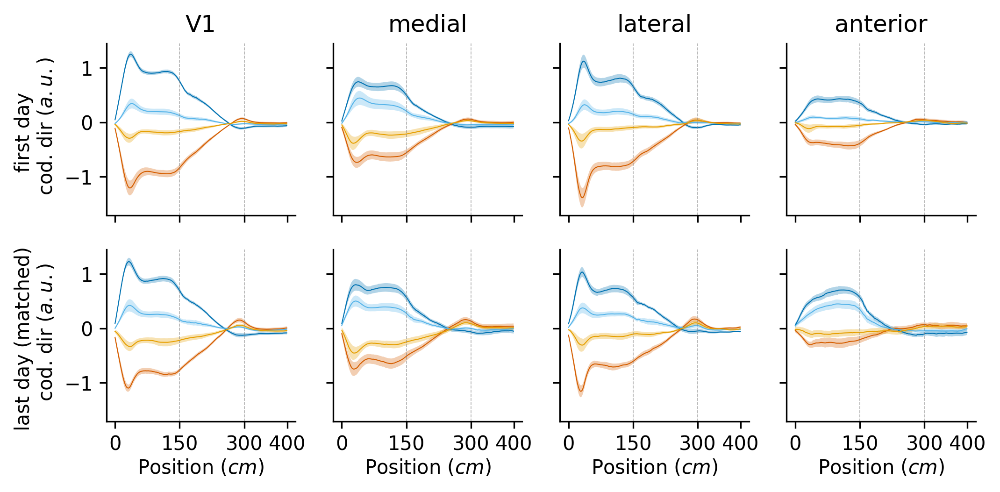

In [1158]:
fig, cds_axs = plt.subplots(2, len(areas), figsize=(8, 3.5), dpi=300,sharex=True, sharey=True)
for a, area in enumerate(areas):
    for ttype in range(4):
        fig1.plot_cds(cds_all[0], ttype, a, 0, cds_axs[0, a], references=True)
        fig1.plot_cds(cds_all[2], ttype, a, 0, cds_axs[1, a], references=True)
rows, cols = cds_axs.shape
for i in range(rows):
    for j in range(cols):
        cds_axs[i, j].set_xticks([0, 150, 300, 400])
        cds_axs[0, j].set_title(f"{areas[j]}")
        if i == 1:
            cds_axs[i, j].set_xlabel("Position ($cm$)", labelpad=2)
cds_axs[0,0].set_ylabel("first day \n cod. dir ($a.u.$)")
cds_axs[1,0].set_ylabel("last day (matched) \n cod. dir ($a.u.$)")
sns.despine()

In [1075]:
def get_ii_from_cds(cds):
    rew_trials = [0, 2]
    nr_trials = [1, 3]
    avg_cd = cds[:,:,:,:,:100].mean(-1)
    sep = avg_cd[:,rew_trials] - avg_cd[:,nr_trials]
    prot_sep = sep[:,0]  # rewarded - non rewarded prot
    rest_sep = sep[:,1]  # rewarded - non rewarded rest
    ii_centroid = rest_sep / (prot_sep + 1e-6)
    return ii_centroid

In [897]:
get_ii_from_cds(cds_all[0]).shape

(10, 4, 2)

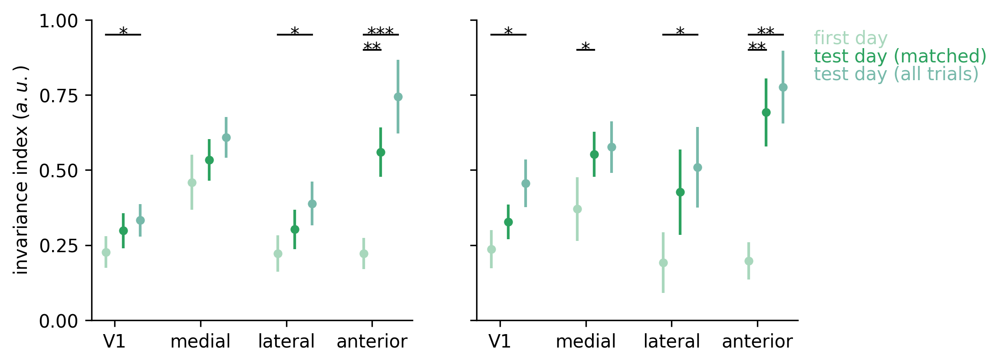

In [ ]:
from src import fig1
gis_first = get_ii_from_cds(cds_all[0])
gis_last = get_ii_from_cds(cds_all[1])
gis_last_m = get_ii_from_cds(cds_all[2])
fig, ax = plt.subplots(1,2, figsize=(7,3), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=.9, sig_line_control=.95, alternative=("two-sided", "two-sided"), lines=False)
ax[0].set_ylim(0,1)
ax[0].set_yticks([0, .25, 0.5, .75, 1])
sns.despine()

In [764]:
topdpprot_gainvsgeom_df.to_csv(r"D:\mouseobj\overall\topdpprot_gain_vs_geometry_analysis.csv", index=False)

In [765]:
df_no34 = topdpprot_gainvsgeom_df.query("name != 'VG34'")

In [766]:
get_feature_values(topdpprot_gainvsgeom_df, "V1", "Pyr", "first training", 'angle')

array([0.27280137, 0.38071126, 0.29949788, 0.49749135, 0.52221448,
       0.47209679, 0.10624862, 0.47326055, 0.54596737, 0.39840986])

In [767]:
sessions = ['first training', 'last training', 'last training (matched)']
areas = ['V1', 'medial', 'lateral', 'anterior']
celltype = ['Pyr', 'Int']
nmice = 10
angles = {}
for sess in sessions: 
    angle = np.empty((nmice, len(areas), len(celltype)))
    for ia, area in enumerate(areas):
        for ic, ctype in enumerate(celltype):
            print(area, ctype, sess)
            inv = get_feature_values(topdpprot_gainvsgeom_df, area, ctype, sess, 'angle')
            #store values
            angle[:,ia,ic] = inv
    angles[sess] = angle

sessions = ['all rewarded before', 'all rewarded after']
nmice = 9
for sess in sessions: 
    angle = np.empty((nmice, len(areas), len(celltype)))
    for ia, area in enumerate(areas):
        for ic, ctype in enumerate(celltype):
            inv = get_feature_values(df_no34, area, ctype, sess, 'angle')
            #store values
            angle[:,ia,ic] = inv
    angles[sess] = angle

V1 Pyr first training
V1 Int first training
medial Pyr first training
medial Int first training
lateral Pyr first training
lateral Int first training
anterior Pyr first training
anterior Int first training
V1 Pyr last training
V1 Int last training
medial Pyr last training
medial Int last training
lateral Pyr last training
lateral Int last training
anterior Pyr last training
anterior Int last training
V1 Pyr last training (matched)
V1 Int last training (matched)
medial Pyr last training (matched)
medial Int last training (matched)
lateral Pyr last training (matched)
lateral Int last training (matched)
anterior Pyr last training (matched)
anterior Int last training (matched)


In [768]:
def get_feature_fromdf(feature_name: str, df: pd.DataFrame):
    sessions = ['first training', 'last training', 'last training (matched)']
    areas = ['V1', 'medial', 'lateral', 'anterior']
    celltype = ['Pyr', 'Int']
    nmice = 10
    f_dict = {}
    for sess in sessions: 
        fts = np.empty((nmice, len(areas), len(celltype)))
        for ia, area in enumerate(areas):
            for ic, ctype in enumerate(celltype):
                ft = get_feature_values(df, area, ctype, sess, feature_name)
                #store values
                fts[:,ia,ic] = ft
        f_dict[sess] = fts
    df_no34 = df.query("name != 'VG34'")
    sessions = ['all rewarded before', 'all rewarded after']
    nmice = 9
    for sess in sessions: 
        fts = np.empty((nmice, len(areas), len(celltype)))
        for ia, area in enumerate(areas):
            for ic, ctype in enumerate(celltype):
                ft = get_feature_values(df_no34, area, ctype, sess, feature_name)
                #store values
                fts[:,ia,ic] = ft
        f_dict[sess] = fts
    return f_dict   

In [769]:
sessions = ['first training', 'last training', 'last training (matched)']
areas = ['V1', 'medial', 'lateral', 'anterior']
celltype = ['Pyr', 'Int']
nmice = 10
invariances = {}
for sess in sessions: 
    invariance = np.empty((nmice, len(areas), len(celltype)))
    for ia, area in enumerate(areas):
        for ic, ctype in enumerate(celltype):
            inv = get_feature_values(topdpprot_gainvsgeom_df, area, ctype, sess, 'invariance')
            #store values
            invariance[:,ia,ic] = inv
    invariances[sess] = invariance

sessions = ['all rewarded before', 'all rewarded after']
nmice = 9
for sess in sessions: 
    invariance = np.empty((nmice, len(areas), len(celltype)))
    for ia, area in enumerate(areas):
        for ic, ctype in enumerate(celltype):
            inv = get_feature_values(df_no34, area, ctype, sess, 'invariance')
            #store values
            invariance[:,ia,ic] = inv
    invariances[sess] = invariance

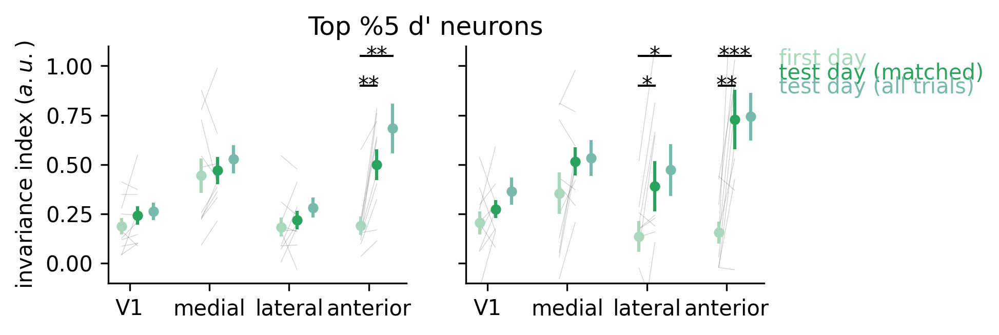

In [776]:
from src import fig1
gis_first = invariances['first training']
gis_last = invariances['last training']
gis_last_m = invariances['last training (matched)']
fig, ax = plt.subplots(1,2, figsize=(5.5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=.9, sig_line_control=1.05, alternative=("two-sided", "two-sided"))
for a in ax.flatten():
    a.set_ylim(-.1,1.1)
fig.suptitle('Top %5 d\' neurons')
sns.despine()

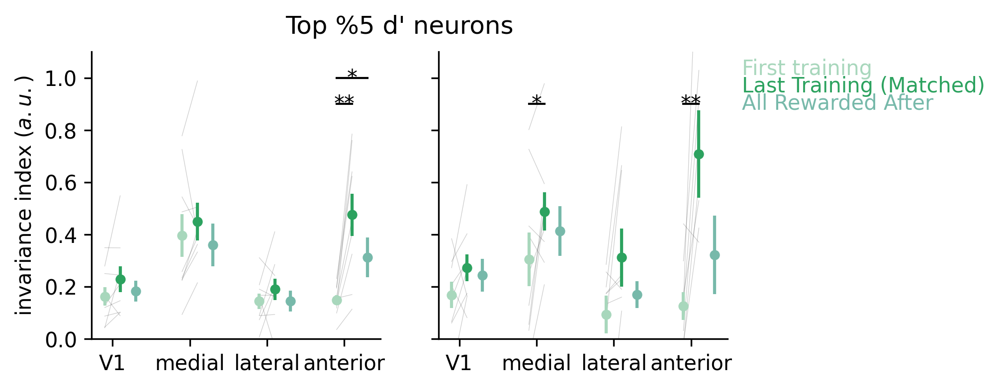

In [975]:
from src import fig1
gis_first = np.delete(invariances['first training'],8, axis=0)    #remove VG34 that is not in the all rewarded after
gis_last =  invariances['all rewarded after']   #remove VG34 that is not in the all rewarded after
gis_last_m =   np.delete(invariances['last training (matched)'],8, axis=0)
fig, ax = plt.subplots(1,2, figsize=(5.5,2.5), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=.9, 
                                 sig_line_control=1, alternative=("two-sided", "two-sided"),
                                 labels = ['First training','Last Training (Matched)',  'All Rewarded After'])
for a in ax.flatten():
    a.set_ylim(0,1.1)
fig.suptitle('Top %5 d\' neurons')
sns.despine()

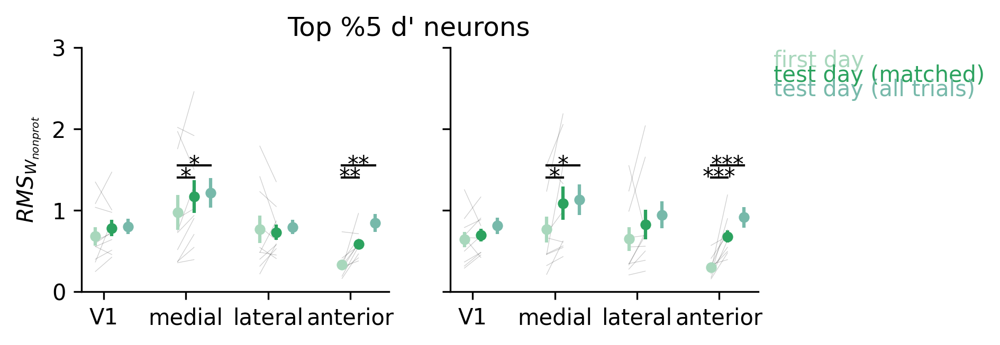

In [788]:
signal_mag = get_feature_fromdf("signal_magnitude", topdpprot_gainvsgeom_df)
from src import fig1
gis_first = signal_mag['first training']
gis_last = signal_mag['last training']
gis_last_m = signal_mag['last training (matched)']
fig, ax = plt.subplots(1,2, figsize=(5.5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=1.4, sig_line_control=1.55, alternative=("greater", "greater"), ylabel='$RMS_{W_{nonprot}}$')
for a in ax.flatten():
    a.set_ylim(0,3)
fig.suptitle('Top %5 d\' neurons')
sns.despine()

In [ ]:
def calculate_gini_information(d_primes):
    """
    d_primes: array of d' values for all neurons in an area
    """
    info = np.sort(d_primes**2)
    n = len(info)
    index = np.arange(1, n + 1)
    gini = (np.sum((2 * index - n - 1) * info)) / (n * np.sum(info))
    return gini

rows = []
common_dprime_axis = np.linspace(0, 6, 100)
celltype = ['Pyr', 'Int']
areas = ['V1', 'medial', 'lateral', 'anterior']
n_sessions = 3
sessions_names = ['first training', 'last training', 'last training (matched)']
cdfs = np.full((n_sessions, 10, nareas, ncelltypes, len(common_dprime_axis)), np.nan)
obj_path = Path(r"D:\mouseobj")
for iss, sess in enumerate(sessions_names):
    if sess == 'last training (matched)':
        session = 'last training'
    else:
        session = sess
    d = working_dbase.query(f"session == '{session}'")
    print(f"Processing: {sess}")
    for i, (_, row) in enumerate(d.iterrows()):
        name, datexp, blk = row["mname"], row["datexp"], row["blk"]
        save_pth = obj_path.joinpath(name,datexp,blk)
        m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")
        if sess == 'last training (matched)':
            dp_nonprot = np.load(save_pth.joinpath("dp_rest_nosplit_matched.npy"))
        else:
            dp_nonprot = np.load(save_pth.joinpath("dp_rest_nosplit.npy"))
        for iaa, area in enumerate(areas):
            ia = utils.get_region_idx(m.iarea, area)
            for ic, cell in enumerate(celltype):
                sel_type = np.logical_not(m.isred[:, 0]).astype(bool) if cell == 'Pyr' else m.isred[:, 0].astype(bool)
                #pstv_tsh, ngtv_tsh = utils.get_dp_thresholds(dp[ia*sel_type], tsh=95) # top 5%
                #prefer_r = (dp>=pstv_tsh)
                #prefer_nr = (dp<=ngtv_tsh)
                #selective_neurons = prefer_r + prefer_nr
                selection = ia * sel_type #* selective_neurons
                dp_sel = dp_nonprot[selection]
                info = np.abs(dp_sel)
                sorted_data = np.sort(info)
                y_values = np.arange(len(info)) / float(len(info))
                interp_cdf = np.interp(common_dprime_axis, sorted_data, y_values, left=0, right=1)
                cdfs[iss, i, iaa, ic, :] = interp_cdf
                gini = calculate_gini_information(dp_sel)
                rows.append({'name': name, 'name_id': row['name_round'], 'datexp': datexp, 'blk': blk, 
                             'session': sess, 'celltype': cell, 'area': area, 'gini': gini})
    clear_output(wait=True)
gini_df = pd.DataFrame(rows)

Processing: last training (matched)
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_10_31\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_14\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG

In [821]:
def get_feature_fromdf_gini(feature_name: str, df: pd.DataFrame):
    sessions = ['first training', 'last training', 'last training (matched)']
    areas = ['V1', 'medial', 'lateral', 'anterior']
    celltype = ['Exc', 'Inh']
    nmice = 10
    f_dict = {}
    for sess in sessions: 
        fts = np.empty((nmice, len(areas), len(celltype)))
        for ia, area in enumerate(areas):
            for ic, ctype in enumerate(celltype):
                ft = get_feature_values(df, area, ctype, sess, feature_name)
                #store values
                fts[:,ia,ic] = ft
        f_dict[sess] = fts
    return f_dict

In [799]:
order = [0, 2, 1, 3]  # V1, medial, lateral, anterior
cdfs = cdfs[:, :, order, :, :]  # reorder areas

In [800]:
np.save(r"D:\mouseobj\overall\interp_cdfs.npy", cdfs)

In [801]:
cdfs.shape

(3, 10, 4, 2, 100)

In [803]:
areas = ['V1', 'medial', 'lateral', 'anterior']

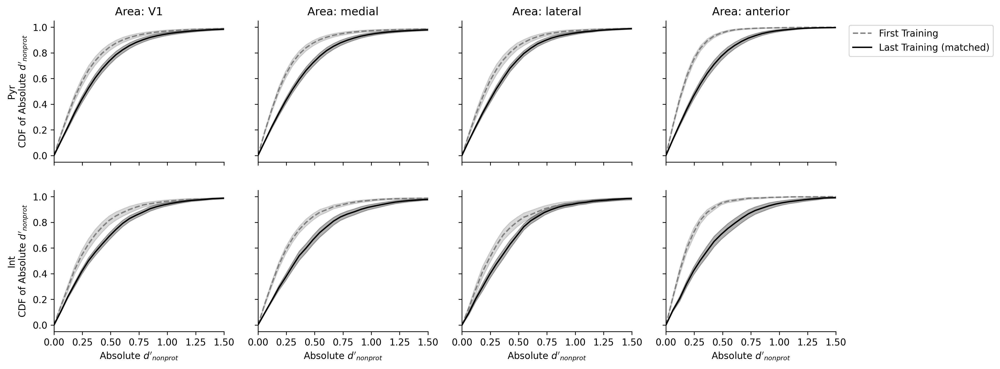

In [813]:
mean_cdfs = cdfs.mean(1)  # average over mice
sem_cdfs = sem(cdfs, axis=1)  # sem over mice

#plot them 
fig, axes = plt.subplots(len(celltype), len(areas), figsize=(15, 6), dpi=300, sharey=True, sharex=True)
for ia, area in enumerate(areas):
    for ic, ctype in enumerate(celltype):
        axes[1, ia].set_xlabel("Absolute $d'_{nonprot}$")
        ax = axes[ic, ia]
        ax.fill_between(common_dprime_axis, mean_cdfs[0, ia, ic, :] - sem_cdfs[0, ia, ic, :], mean_cdfs[0, ia, ic, :] + sem_cdfs[0, ia, ic, :], color='gray', alpha=0.3)
        ax.fill_between(common_dprime_axis, mean_cdfs[2, ia, ic, :] - sem_cdfs[2, ia, ic, :], mean_cdfs[2, ia, ic, :] + sem_cdfs[2, ia, ic, :], color='k',alpha=0.3)
        ax.plot(common_dprime_axis, mean_cdfs[0, ia, ic, :], color='gray', linestyle='--', label='First Training')
        ax.plot(common_dprime_axis, mean_cdfs[2, ia, ic, :], color='k', label='Last Training (matched)')
        if ic == 0:
            ax.set_title(f"Area: {area}")
            if ia == 3:
                ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        if ia == 0:
            ax.set_ylabel(f"{ctype}" + "\nCDF of Absolute $d'_{nonprot}$")
        
        ax.set_xlim(0, 1.5)
sns.despine()

In [976]:
def extract_cdf_metrics(cdf_tensor, common_axis):
    days, mice, areas, celltypes, bins = cdf_tensor.shape
    results = []

    area_names = ['V1', 'medial', 'lateral', 'anterior']
    cell_names = ['Exc', 'Inh']
    day_names = ['first training', 'last training', 'last training (matched)']

    for d in range(days):
        for m in range(mice):
            for a in range(areas):
                for c in range(celltypes):
                    # Get the specific CDF for this mouse/area/day/cell
                    cdf = cdf_tensor[d, m, a, c, :]
                    
                    # 1. Median d' (50th percentile)
                    median_dp = common_axis[np.searchsorted(cdf, 0.5)]
                    
                    # 2. Expert Ceiling (95th percentile)
                    expert_dp = common_axis[np.searchsorted(cdf, 0.95)]

                    iqr_e = common_axis[np.searchsorted(cdf, 0.75)] - common_axis[np.searchsorted(cdf, 0.25)]
                    
                    # 3. AUC (Total Information Volume)
                    area_above_curve = np.trapezoid(1 - cdf, common_axis)
                    
                    # 4. Expert Gap (Concentration)
                    expert_gap = expert_dp - median_dp
                    
                    results.append({
                        'session': day_names[d],
                        'Mouse': m,
                        'area': area_names[a],
                        'celltype': cell_names[c],
                        'Median_dP': median_dp,
                        'Expert_dP': expert_dp,
                        'Info_Volume': area_above_curve,
                        'Expert_Gap': expert_gap,
                        'IQR': iqr_e
                    })
                    
    return pd.DataFrame(results)

In [977]:
cdf_df = extract_cdf_metrics(cdfs, common_dprime_axis)
cdf_df

,session,Mouse,area,celltype,Median_dP,Expert_dP,Info_Volume,Expert_Gap,IQR
0,first training,0,V1,Exc,0.181818,0.666667,0.229203,0.484848,0.242424
1,first training,0,V1,Inh,0.181818,0.545455,0.197334,0.363636,0.181818
2,first training,0,medial,Exc,0.181818,0.484848,0.175631,0.303030,0.121212
3,first training,0,medial,Inh,0.181818,0.484848,0.193570,0.303030,0.181818
4,first training,0,lateral,Exc,0.242424,0.727273,0.253128,0.484848,0.242424
...,...,...,...,...,...,...,...,...,...
235,last training (matched),9,medial,Inh,0.545455,1.454545,0.600436,0.909091,0.545455
236,last training (matched),9,lateral,Exc,0.363636,0.969697,0.374383,0.606061,0.363636
237,last training (matched),9,lateral,Inh,0.424242,1.151515,0.414549,0.727273,0.424242
238,last training (matched),9,anterior,Exc,0.303030,0.909091,0.354680,0.606061,0.363636


In [ ]:
cdf_first = cdf_df.query("session == 'first training'")
cdf_last_matched = cdf_df.query("session == 'last training (matched)'") 


<>:14: SyntaxWarning: invalid escape sequence '\D'
<>:14: SyntaxWarning: invalid escape sequence '\D'
C:\Users\labadmin\AppData\Local\Temp\ipykernel_12596\138316776.py:14: SyntaxWarning: invalid escape sequence '\D'
  axes[icc].set_ylabel("$ \Delta IQR d'_{nonprot}$ \n (sparsity)")


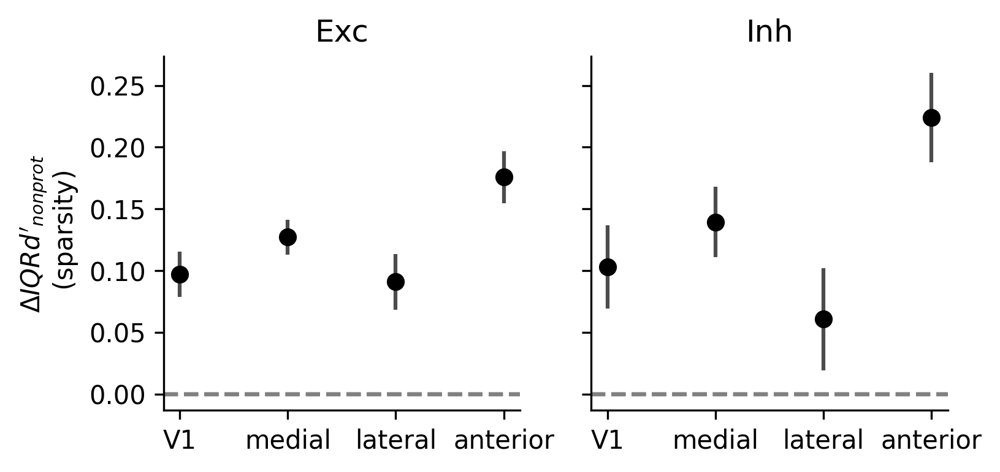

In [1004]:
celltype = ["Exc", "Inh"]
fig, axes = plt.subplots(1, 2, figsize=(5.5, 2.5), dpi=300, sharey=True, sharex=True)
for ia, area in enumerate(areas):
    for icc , cell in enumerate(celltype):
        cdf_area_cell_first = cdf_first.query(f"area == '{area}' and celltype == '{cell}'")
        cdf_area_cell_last_matched = cdf_last_matched.query(f"area == '{area}' and celltype == '{cell}'")
        shift = cdf_area_cell_last_matched['IQR'].values - cdf_area_cell_first['IQR'].values
        axes[icc].errorbar(ia, shift.mean(), yerr=sem(shift), color='k', alpha=0.7)
        axes[icc].plot(ia, shift.mean(), 'o', color='k')
        axes[icc].set_xticks(range(len(areas)), labels=areas)
        axes[icc].set_title(f"{cell}")
        axes[icc].axhline(0, color='gray', linestyle='--')
        if icc == 0:
            axes[icc].set_ylabel("$ \Delta IQR d'_{nonprot}$ \n (sparsity)")
sns.despine()

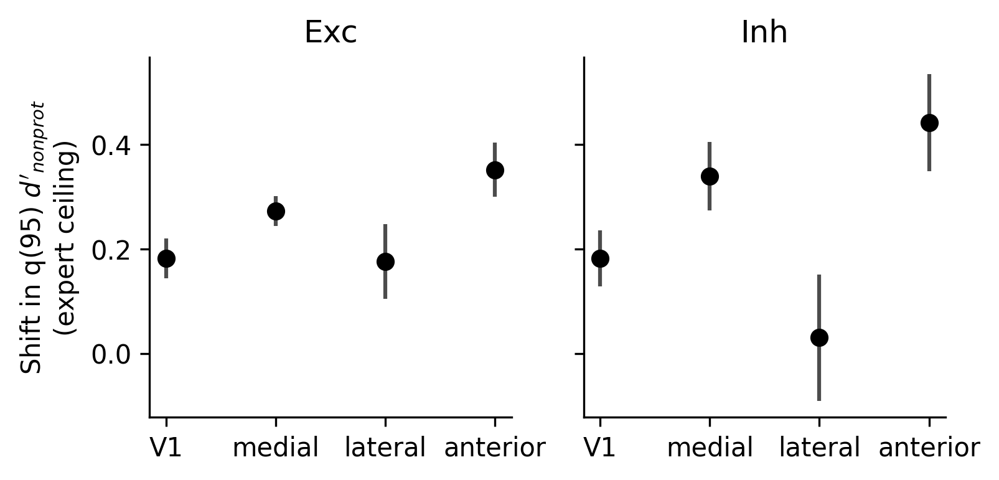

In [995]:
celltype = ["Exc", "Inh"]
fig, axes = plt.subplots(1, 2, figsize=(5.5, 2.5), dpi=300, sharey=True, sharex=True)
for ia, area in enumerate(areas):
    for icc , cell in enumerate(celltype):
        cdf_area_cell_first = cdf_first.query(f"area == '{area}' and celltype == '{cell}'")
        cdf_area_cell_last_matched = cdf_last_matched.query(f"area == '{area}' and celltype == '{cell}'")
        shift = cdf_area_cell_last_matched['Expert_dP'].values - cdf_area_cell_first['Expert_dP'].values
        axes[icc].errorbar(ia, shift.mean(), yerr=sem(shift), color='k', alpha=0.7)
        axes[icc].plot(ia, shift.mean(), 'o', color='k')
        axes[icc].set_xticks(range(len(areas)), labels=areas)
        axes[icc].set_title(f"{cell}")
        if icc == 0:
            axes[icc].set_ylabel("Shift in q(95) $d'_{nonprot}$\n(expert ceiling)")
sns.despine()

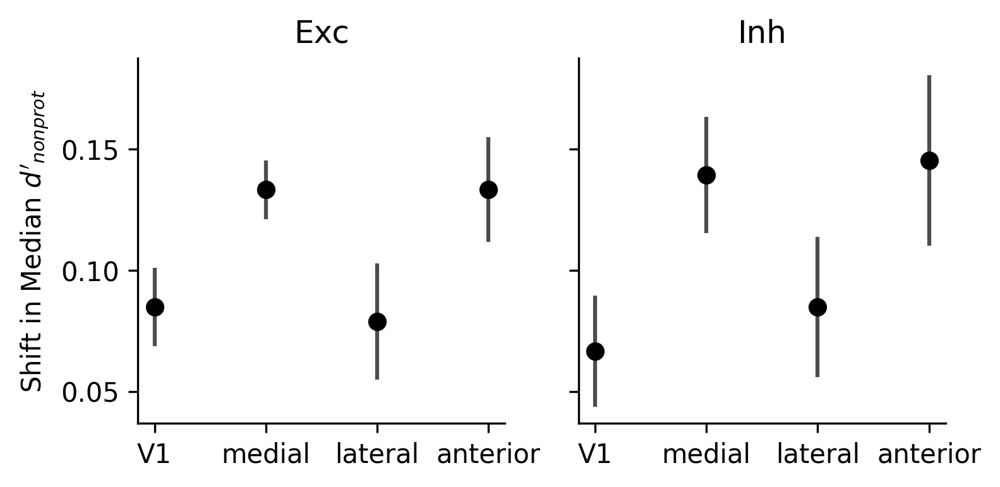

In [994]:
celltype = ["Exc", "Inh"]
fig, axes = plt.subplots(1, 2, figsize=(5.5, 2.5), dpi=300, sharey=True, sharex=True)
for ia, area in enumerate(areas):
    for icc , cell in enumerate(celltype):
        cdf_area_cell_first = cdf_first.query(f"area == '{area}' and celltype == '{cell}'")
        cdf_area_cell_last_matched = cdf_last_matched.query(f"area == '{area}' and celltype == '{cell}'")
        shift = cdf_area_cell_last_matched['Median_dP'].values - cdf_area_cell_first['Median_dP'].values
        axes[icc].errorbar(ia, shift.mean(), yerr=sem(shift), color='k', alpha=0.7)
        axes[icc].plot(ia, shift.mean(), 'o', color='k')
        axes[icc].set_xticks(range(len(areas)), labels=areas)
        axes[icc].set_title(f"{cell}")
        if icc == 0:
            axes[icc].set_ylabel("Shift in Median $d'_{nonprot}$")
sns.despine()

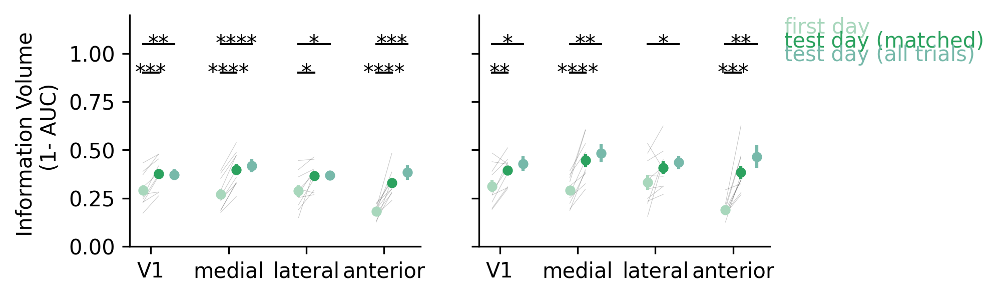

In [830]:
expert_gap = get_feature_fromdf_gini('Info_Volume', cdf_df)
from src import fig1
gis_first = expert_gap['first training']
gis_last = expert_gap['last training']
gis_last_m = expert_gap['last training (matched)']
fig, ax = plt.subplots(1,2, figsize=(5.5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=.9, sig_line_control=1.05,
                                  alternative=("two-sided", "two-sided"), ylabel='Information Volume \n (1- AUC)')
for a in ax.flatten():
    a.set_ylim(0,1.2)
sns.despine()

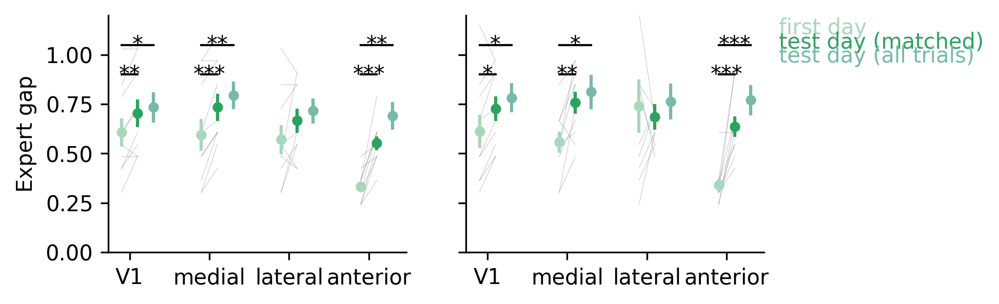

In [827]:
expert_gap = get_feature_fromdf_gini('Expert_Gap', cdf_df)
from src import fig1
gis_first = expert_gap['first training']
gis_last = expert_gap['last training']
gis_last_m = expert_gap['last training (matched)']
fig, ax = plt.subplots(1,2, figsize=(5.5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=.9, sig_line_control=1.05,
                                  alternative=("two-sided", "two-sided"), ylabel='Expert gap')
for a in ax.flatten():
    a.set_ylim(0,1.2)
sns.despine()

In [771]:
ft_inv=invariances["first training"]
ft_inv = ft_inv[:, :, 0]  # Pyr cells only
#compare the difference between areas means and plot as point plot, with ttest rel
area_names = ['V1', 'medial', 'lateral', 'anterior']

C:\Users\labadmin\AppData\Local\Temp\ipykernel_12596\1158865642.py:15: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=df_ft, x='area', y='invariance', errorbar='se', capsize=0.15,


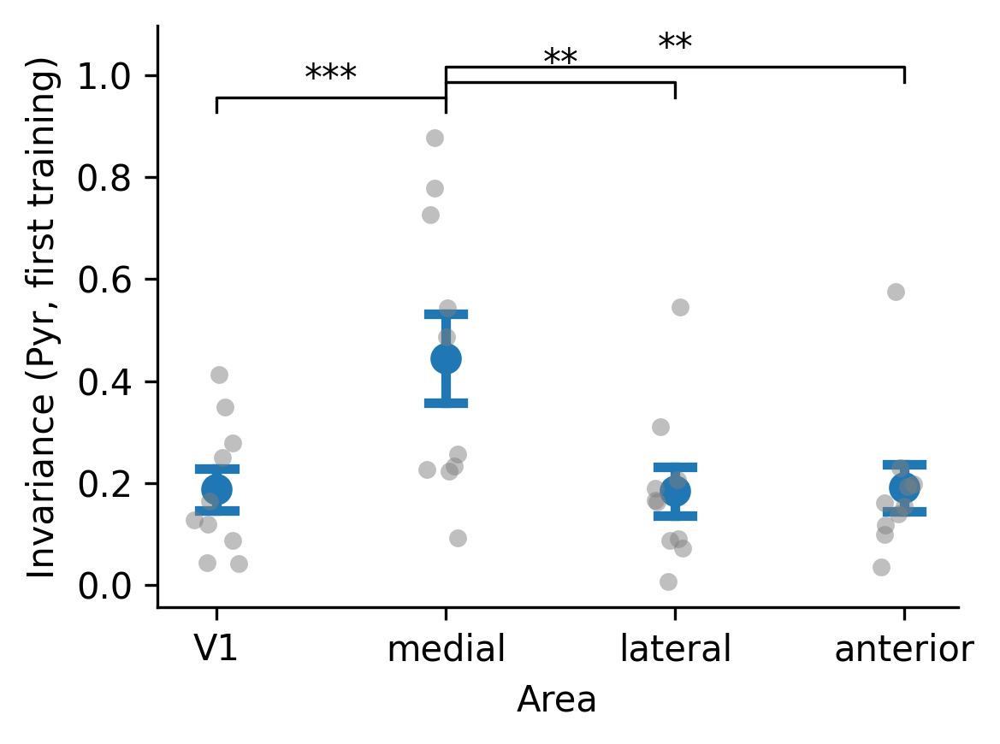

In [772]:
from itertools import combinations
from scipy.stats import ttest_rel

# ft_inv: shape (nmice, nareas) for Pyr cells on first training
nmice, nareas = ft_inv.shape
df_ft = pd.DataFrame({
    'mouse': np.repeat(np.arange(nmice), nareas),
    'area': np.tile(area_names, nmice),
    'invariance': ft_inv.reshape(-1)
})

fig, ax = plt.subplots(figsize=(4,3), dpi=300)

# Mean ± SEM pointplot + individual points
sns.pointplot(data=df_ft, x='area', y='invariance', errorbar='se', capsize=0.15,
              join=False, color='tab:blue', ax=ax)
sns.stripplot(data=df_ft, x='area', y='invariance', color='gray', alpha=0.5, ax=ax)

ax.set_ylabel("Invariance (Pyr, first training)")
ax.set_xlabel("Area")
sns.despine(ax=ax)

def add_sig_line(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=0.8, c='k')
    ax.text((x1 + x2) / 2, y + h, text, ha='center', va='bottom')

# Pairwise paired t-tests across areas; annotate only significant pairs
pairs_idx = list(combinations(range(len(area_names)), 2))
y_base = df_ft['invariance'].max() + 0.05
h = 0.03
stack = 0

for i, j in pairs_idx:
    a = ft_inv[:, i]
    b = ft_inv[:, j]
    mask = ~np.isnan(a) & ~np.isnan(b)
    if mask.sum() < 2:
        continue
    tstat, pval = ttest_rel(a[mask], b[mask])
    if pval < 0.05:
        stars = '***' if pval < 0.001 else '**' if pval < 0.01 else '*'
        y = y_base + stack * 0.03
        add_sig_line(ax, i, j, y, h, stars)
        stack += 1

# Expand ylim if any annotations were drawn
if stack > 0:
    ax.set_ylim(top=y_base + stack * 0.04 + 0.05)

plt.tight_layout()

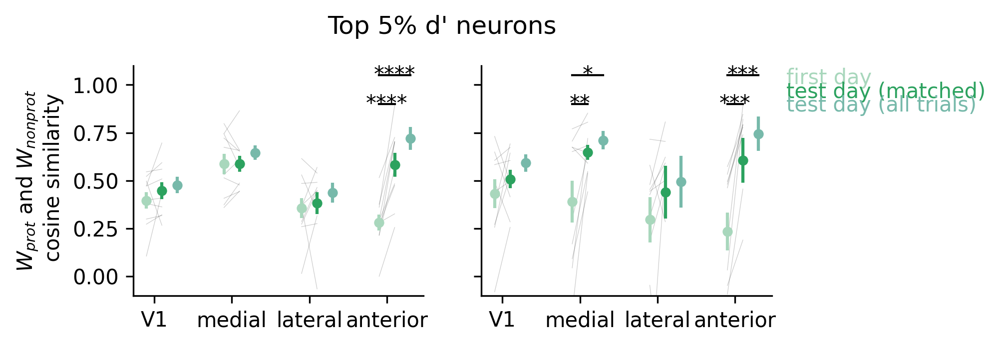

In [777]:
gis_first = angles['first training']
gis_last = angles['last training']
gis_last_m = angles['last training (matched)']
fig, ax = plt.subplots(1,2, figsize=(5.5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=.9, sig_line_control=1.05, ylabel='$W_{prot}$ and $W_{nonprot}$ \n cosine similarity')
for a in ax.flatten():
    a.set_ylim(-.1,1.1)
fig.suptitle('Top 5% d\' neurons', y=1.05)
sns.despine()

In [1161]:
invar = get_ii_from_cds(cds_all[2])

In [1213]:
celltype = ['Pyr', 'Int']
areas = ['V1', 'medial', 'lateral', 'anterior']
n_sessions = 4
sessions_names = ['all rewarded before', 'first training', 'last training (matched)', 'all rewarded after']
obj_path = Path(r"D:\mouseobj")
cds_all = np.zeros((n_sessions, 10, 4, len(areas), len(celltype), 400))
named = "coding_dir_100.npy"
for iss, sess in enumerate(sessions_names):
    if sess == 'last training (matched)':
        session = 'last training'
        named = "coding_dir_100_matched.npy"
    else:   
        session = sess
        named = "coding_dir_100.npy"
    d = working_dbase.query(f"session == '{session}'")
    print(f"Processing: {sess}")
    for i, (_, row) in enumerate(d.iterrows()):
        name, datexp, blk = row["mname"], row["datexp"], row["blk"]
        save_pth = obj_path.joinpath(name,datexp,blk)
        cd = np.load(save_pth.joinpath(named))
        cds_all[iss, i] = cd

Processing: all rewarded before
Processing: first training
Processing: last training (matched)
Processing: all rewarded after


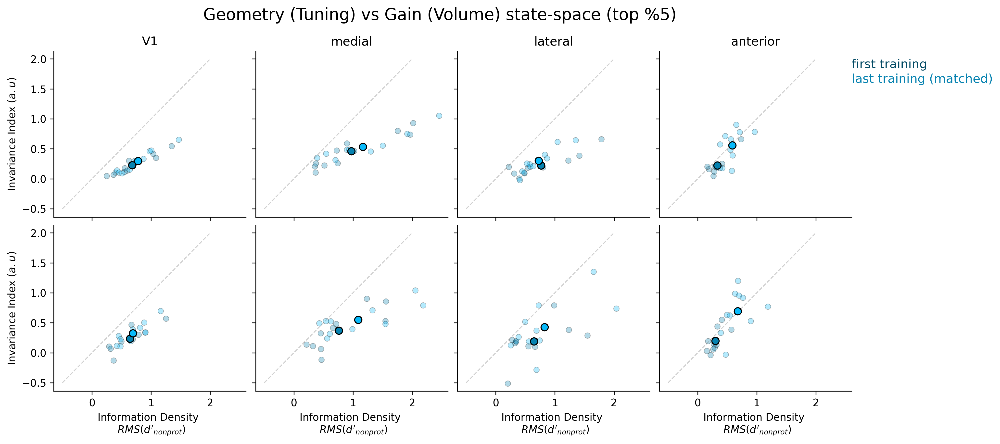

In [1242]:
palette = ["#034a64", "#0682b0", "#08bafb", '#686868']
#session_names = ['first training', 'last training (matched)']
sessions_names_all = ['first training', 'last training (matched)']
fig, axes = plt.subplots(2, len(areas), figsize=(14, 6), sharex=True, sharey=True, dpi=300)
plt.subplots_adjust(wspace=0.05, hspace=0.05)
all_means = np.zeros((len(areas), len(celltype), len(sessions_names_all), 2))
for iaa, area in enumerate(areas):
    axes[1, iaa].set_xlabel('Information Density \n $RMS(d\'_{nonprot})$')
    axes[0, iaa].set_title(f"{area}")
    for ic, cell in enumerate(celltype):
        axes[ic,0].set_ylabel('Invariance Index $(a.u)$')
        for iss, session in enumerate(sessions_names_all):
            sub_df = topdpprot_gainvsgeom_df.query(f"area == '{area}' & session == '{session}' & celltype == '{cell}'")
            invar = get_ii_from_cds(cds_all[iss+1])
            invar_vals = invar[:, iaa, ic]
            topdpprot_gainvsgeom_df.loc[sub_df.index, 'invariance'] = invar_vals
            ax = axes[ic, iaa]
            if session in ['all rewarded before', 'all rewarded after']:
                ax.scatter(sub_df['signal_magnitude'], invar_vals, alpha=0.1, color = palette[iss+1], edgecolors='black', linewidth=0.5,  zorder=0, s=18)
            else:
                ax.scatter(sub_df['signal_magnitude'], invar_vals, alpha=0.3, color = palette[iss+1], edgecolors='black', linewidth=0.5,  zorder=0, s=30)
            means = (sub_df["signal_magnitude"].mean(), invar_vals.mean())
            # add 45 line
            ax.plot([-0.5, 2], [-0.50, 2], color='gray', linestyle='--', linewidth=1, zorder=0, alpha=0.2)
            ax.scatter(*means, color=palette[iss+1], s=50, marker='o', edgecolors='black', linewidth=1)
            all_means[iaa, ic, iss] = means
            #ax.axis('square')
            #ax.set_ylim(-0.5, 2.5)
            #ax.set_xlim(-0.5, 2.5)
                       
#for iaa, area in enumerate(areas):
#    for ic, cell in enumerate(celltype):
#            origin = (all_means[iaa, ic, 0, 0], all_means[iaa, ic, 0, 1])
#            direction = (all_means[iaa, ic, 1, 0] - all_means[iaa, ic, 0, 0], all_means[iaa, ic, 1, 1] - all_means[iaa, ic, 0, 1])
#            axes[ic, iaa].arrow(origin[0], origin[1], direction[0], direction[1], head_width=0.02, head_length=0.02, fc='k', ec='k', linewidth=1, length_includes_head=True, zorder=1)
#            origin = (all_means[iaa, ic, 1, 0], all_means[iaa, ic, 1, 1])
#            direction = (all_means[iaa, ic, 2, 0] - all_means[iaa, ic, 1, 0], all_means[iaa, ic, 2, 1] - all_means[iaa, ic, 1, 1])
#            axes[ic, iaa].arrow(origin[0], origin[1], direction[0], direction[1], head_width=0.02, head_length=0.02, fc='k', ec='k', linewidth=1, length_includes_head=True, zorder=1)
#            origin = (all_means[iaa, ic, 2, 0], all_means[iaa, ic, 2, 1])
            #direction = (all_means[iaa, ic, 3, 0] - all_means[iaa, ic, 2, 0], all_means[iaa, ic, 3, 1] - all_means[iaa, ic, 2, 1])
            #axes[ic, iaa].arrow(origin[0], origin[1], direction[0], direction[1], head_width=0.02, head_length=0.02, fc='k', ec='k', linewidth=0.5, linestyle='-.',
            #                     length_includes_head=True, zorder=1)
for lab in sessions_names_all:
    axes[0, 3].text(1, .9 - 0.09 * sessions_names_all.index(lab), lab, fontsize=12, transform=axes[0, 3].transAxes, color=palette[sessions_names_all.index(lab)])
fig.suptitle('Geometry (Tuning) vs Gain (Volume) state-space (top %5)', fontsize=16)
sns.despine()

In [1224]:
cleaned_reg_df = topdpprot_gainvsgeom_df.query("session in ['first training', 'last training (matched)']").copy()
cleaned_reg_df["area"]  = pd.Categorical(cleaned_reg_df["area"], categories=["V1", "lateral", "medial", "anterior"], ordered=True) 
cleaned_reg_df["sig_gain_centered"] = cleaned_reg_df["signal_magnitude"] - cleaned_reg_df["signal_magnitude"].mean()

In [1239]:
cleaned_reg_df

,name,name_id,datexp,blk,session,celltype,area,invariance,angle,signal_magnitude,sig_gain_centered
80,VG11,VG11_1,2024_10_16,2,first training,Pyr,V1,0.086793,0.272801,0.397771,-0.329344
81,VG11,VG11_1,2024_10_16,2,first training,Int,V1,0.065500,0.256296,0.288060,-0.439056
82,VG11,VG11_1,2024_10_16,2,first training,Pyr,lateral,0.088387,0.259629,0.483153,-0.243963
83,VG11,VG11_1,2024_10_16,2,first training,Int,lateral,0.172831,0.311651,0.344188,-0.382928
84,VG11,VG11_1,2024_10_16,2,first training,Pyr,medial,0.227226,0.514535,0.354130,-0.372985
...,...,...,...,...,...,...,...,...,...,...,...
315,VGa9,VGa9_1,2025_11_20,2,last training (matched),Int,lateral,0.159582,0.285446,0.556851,-0.170265
316,VGa9,VGa9_1,2025_11_20,2,last training (matched),Pyr,medial,0.388244,0.609203,1.299070,0.571954
317,VGa9,VGa9_1,2025_11_20,2,last training (matched),Int,medial,0.372689,0.683820,0.987784,0.260668
318,VGa9,VGa9_1,2025_11_20,2,last training (matched),Pyr,anterior,0.324319,0.483764,0.590462,-0.136654


In [1240]:
exc = cleaned_reg_df.query("celltype == 'Pyr'")
model = smf.mixedlm("invariance ~ (sig_gain_centered * area)", exc, groups=exc["name_id"])
#try differen methods 
results = model.fit()
print(results.summary())

                    Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        invariance
No. Observations:        80             Method:                    REML      
No. Groups:              10             Scale:                     0.0096    
Min. group size:         8              Log-Likelihood:            53.8114   
Max. group size:         8              Converged:                 Yes       
Mean group size:         8.0                                                 
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                           0.214    0.025  8.562 0.000  0.165  0.263
area[T.lateral]                    -0.019    0.031 -0.599 0.549 -0.079  0.042
area[T.medial]                      0.130    0.034  3.865 0.000  0.064  0.196
area[T

c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [ ]:
class SequentialScaffold(nn.Module):
    def __init__(self, num_filters=16):
        super().__init__()
        # Basic idea 
        self.v1_exc = nn.Conv2d(1, num_filters, kernel_size=5, padding=2)
        self.medial_pool = nn.AvgPool2d(kernel_size=8)
        self.anterior_readout = nn.Linear(num_filters, 2)
        # each area sends a feedback signal to the previous one, but not directly to the input
        # 1. Anterior sends categorical goal to Medial
        self.anterior_to_medial_feedback = nn.Linear(2, num_filters)
        # 2. Medial control signal sent to V1 to gate features
        self.medial_to_v1_feedback = nn.Linear(num_filters, num_filters)
    def forward(self, x, context_rule=False, attention=True):
        # here V1 "excitatory" responses are computed, 
        # then pooled by Medial (just the simplest way I could think about the day 1 invariance), 
        # and read out by Anterior to form a categorical goal representation
        v1_raw = F.relu(self.v1_exc(x))
        medial_gist = torch.flatten(self.medial_pool(v1_raw), 1)
        logits_gist = self.anterior_readout(medial_gist)
        if context_rule == False:
            # Here anterior role is not "active" because the context is not rule-based, so it cannot form a categorical goal
            logits_gist = torch.zeros_like(logits_gist) 
        elif attention == False:
            # Anterior is active, but misaligned/noisy, so the gaiting signal is corrupted, simulating inattention
            logits_gist = logits_gist + torch.randn_like(logits_gist) * 1.5
        # we pass the signal back to V1 via Medial to refine the V1 representation
        # Anterior sends categorical goal to Medial
        medial_control_signal = torch.sigmoid(self.anterior_to_medial_feedback(logits_gist))
        # Medial translates goal into V1 inhibitory mask to 
        # This allows Medial's high-baseline invariance to 'shape' the V1 mask
        v1_inh_mask = torch.sigmoid(self.medial_to_v1_feedback(medial_control_signal))
        # if context_rule == False, v1_mask is zero
        v1_gated = v1_raw / (1 + v1_inh_mask)
        medial_refined = torch.flatten(self.medial_pool(v1_gated), 1)
        logits_final = self.anterior_readout(medial_refined)
        return logits_final, v1_gated, v1_inh_mask

In [1241]:
exc = cleaned_reg_df.query("celltype == 'Int'")
model = smf.mixedlm("invariance ~ (sig_gain_centered * area)", exc, groups=exc["name_id"])
#try differen methods 
results = model.fit()
print(results.summary())

                    Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        invariance
No. Observations:        80             Method:                    REML      
No. Groups:              10             Scale:                     0.0596    
Min. group size:         8              Log-Likelihood:            -9.8986   
Max. group size:         8              Converged:                 Yes       
Mean group size:         8.0                                                 
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                           0.273    0.058  4.675 0.000  0.158  0.387
area[T.lateral]                    -0.014    0.078 -0.175 0.861 -0.167  0.140
area[T.medial]                      0.086    0.081  1.062 0.288 -0.072  0.244
area[T

c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [413]:
exc

,name,datexp,blk,session,celltype,area,signal_magnitude,median_gain,p90_val,invariance,angle,ei_angle,mouse_id,sig_gain_centered
81,VG11,2024_10_16,2,first training,Int,V1,0.250748,0.158637,0.430295,0.070574,0.118991,0.532669,VG11,-0.185533
83,VG11,2024_10_16,2,first training,Int,medial,0.238456,0.154718,0.385579,0.098519,0.200848,0.578511,VG11,-0.197825
85,VG11,2024_10_16,2,first training,Int,lateral,0.288646,0.202439,0.446920,0.119424,0.085639,0.282887,VG11,-0.147635
87,VG11,2024_10_16,2,first training,Int,anterior,0.209577,0.146854,0.329343,0.137486,0.120826,0.270422,VG11,-0.226704
89,VG11,2024_11_05,3,first training,Int,V1,0.345155,0.205415,0.574231,0.151435,0.247542,0.566266,VG11_2,-0.091126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
311,VG34,2025_10_10,3,last training (matched),Int,anterior,0.416927,0.283793,0.674633,0.632716,0.603283,0.904289,VG34,-0.019354
313,VGa9,2025_11_20,2,last training (matched),Int,V1,0.594657,0.337833,0.981651,0.341492,0.320597,0.892082,VGa9,0.158376
315,VGa9,2025_11_20,2,last training (matched),Int,medial,0.748725,0.515358,1.234917,0.611181,0.495584,0.950771,VGa9,0.312444
317,VGa9,2025_11_20,2,last training (matched),Int,lateral,0.526319,0.369001,0.935807,0.157408,0.177448,0.692894,VGa9,0.090038


In [1243]:
from scipy.spatial.distance import euclidean
def calculate_manifold_geometry(m, selection, trial_dict):
    """
    data: (n_trials, n_neurons) array of neural responses
    labels: (n_trials,) array of category labels (0 or 1)
    """

    all_means = m.interp_spks[:,:,:100].mean(2)
    all_means = all_means[selection,:]
    all_means = all_means.T
    Rprot, NRprot, Rrest, NRrest = trial_dict["rewarded"], trial_dict["non rewarded"], trial_dict["rewarded test"], trial_dict["non rewarded test"]
    cat_a = all_means[Rrest]
    cat_b = all_means[NRrest]
    centroid_a = np.mean(cat_a, axis=0)
    centroid_b = np.mean(cat_b, axis=0)
    signal_separation = euclidean(centroid_a, centroid_b)
    var_a = np.mean(np.var(cat_a, axis=0))
    var_b = np.mean(np.var(cat_b, axis=0))
    noise_width = (var_a + var_b) / 2
    task_axis = centroid_b - centroid_a
    task_axis_unit = task_axis / np.linalg.norm(task_axis)
    resid_a = cat_a - centroid_a
    resid_b = cat_b - centroid_b
    all_residuals = np.vstack([resid_a, resid_b])
    noise_projections = np.dot(all_residuals, task_axis_unit)
    noise_alignment = np.mean(np.abs(noise_projections))
    
    return {
        "separation": signal_separation,
        "noise_width": noise_width,
        "noise_alignment": noise_alignment
    }

import numpy as np
from scipy.spatial.distance import euclidean

def calculate_manifold_geometry_v2(m, selection, trial_dict, reg=1e-6):
    """
    Covariance-aware manifold geometry metrics.

    Returns:
        separation_euclid   → raw centroid distance
        separation_mahal    → noise-normalized separation
        noise_width         → total noise variance
        noise_along_task    → noise variance along task axis
        alignment_ratio     → fraction of noise aligned with task
        snr                 → signal-to-noise ratio
    """

    # --- Mean responses ---
    all_means = m.interp_spks[:, :, :100].mean(2)
    all_means = all_means[selection, :].T  # (trials × neurons)

    Rrest = trial_dict["rewarded test"]
    NRrest = trial_dict["non rewarded test"]

    cat_a = all_means[Rrest]
    cat_b = all_means[NRrest]

    centroid_a = np.mean(cat_a, axis=0)
    centroid_b = np.mean(cat_b, axis=0)

    # --- Signal separation ---
    separation_euclid = euclidean(centroid_a, centroid_b)

    task_axis = centroid_b - centroid_a
    task_axis_norm = np.linalg.norm(task_axis)
    task_axis_unit = task_axis / task_axis_norm

    # --- Residuals (noise) ---
    resid_a = cat_a - centroid_a
    resid_b = cat_b - centroid_b
    all_residuals = np.vstack([resid_a, resid_b])

    # --- Noise covariance ---
    C = np.cov(all_residuals.T)

    # Regularization (critical for stability)
    C_reg = C + reg * np.eye(C.shape[0])

    # --- Noise metrics ---
    noise_width = np.trace(C_reg)  # total noise variance

    noise_along_task = task_axis_unit @ C_reg @ task_axis_unit

    alignment_ratio = noise_along_task / noise_width

    # --- Mahalanobis separation ---
    separation_mahal = np.sqrt(task_axis @ np.linalg.inv(C_reg) @ task_axis)

    # --- Signal-to-noise ratio ---
    snr = task_axis_norm / np.sqrt(noise_along_task)

    return {
        "separation_euclid": separation_euclid,
        "separation_mahal": separation_mahal,
        "noise_width": noise_width,
        "noise_along_task": noise_along_task,
        "alignment_ratio": alignment_ratio,
        "snr": snr
    }

In [1244]:
rows = []
#percentils_dp = np.ones((n_sessions+1, nmice, nareas, ncelltypes, 99)) * np.nan
sessions_names = ['all rewarded before', 'first training', 'last training', 'last training (matched)', 'all rewarded after']
obj_path = Path(r"D:\mouseobj")
for iss, sess in enumerate(sessions_names):
    if sess == 'last training (matched)':
        session = 'last training'
    else:
        session = sess
    d = working_dbase.query(f"session == '{session}'")
    print(f"Processing: {sess}")
    for i, (_, row) in enumerate(d.iterrows()):
        name, datexp, blk = row["mname"], row["datexp"], row["blk"]
        save_pth = obj_path.joinpath(name,datexp,blk)
        m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")
        if sess == 'last training (matched)':
            t_dict = get_matched_trials(m)
            dp_prot = np.load(save_pth.joinpath("dp_prot_nosplit_matched.npy"))
        else:
            t_dict = m.trial_dict
            dp_prot = np.load(save_pth.joinpath("dp_prot_nosplit.npy"))
        for iaa, area in enumerate(areas):
            ia = utils.get_region_idx(m.iarea, area)
            for ic, cell in enumerate(celltype):
                sel_type = np.logical_not(m.isred[:, 0]).astype(bool) if cell == 'Pyr' else m.isred[:, 0].astype(bool)
                #pstv_tsh, ngtv_tsh = utils.get_dp_thresholds(dp_prot[ia*sel_type], tsh=95) # top 25% and bottom 25%
                #prefer_r = (dp_prot>=pstv_tsh)
                #prefer_nr = (dp_prot<=ngtv_tsh)
                #selective_neurons = prefer_r + prefer_nr
                selection = ia * sel_type # * selective_neurons
                geom_metrics = calculate_manifold_geometry_v2(m, selection, t_dict)
                rows.append({'name': name, 'name_id': row['name_round'], 'datexp': datexp, 'blk': blk, 
                             'session': sess, 'celltype': cell, 'area': area, 
                             'separation_euclid': geom_metrics["separation_euclid"], 'separation_mahal': geom_metrics["separation_mahal"], 
                             'noise_width': geom_metrics["noise_width"], 'noise_along_task': geom_metrics["noise_along_task"], 'alignment_ratio': geom_metrics["alignment_ratio"], 'snr': geom_metrics["snr"]})
    clear_output(wait=True)
manifold_geom_df = pd.DataFrame(rows)

Processing: all rewarded after
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_01\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_15\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG14\20

In [1245]:
manifold_geom_df.to_csv(r"D:\mouseobj\overall\manifold_geometry_analysis.csv", index=False)

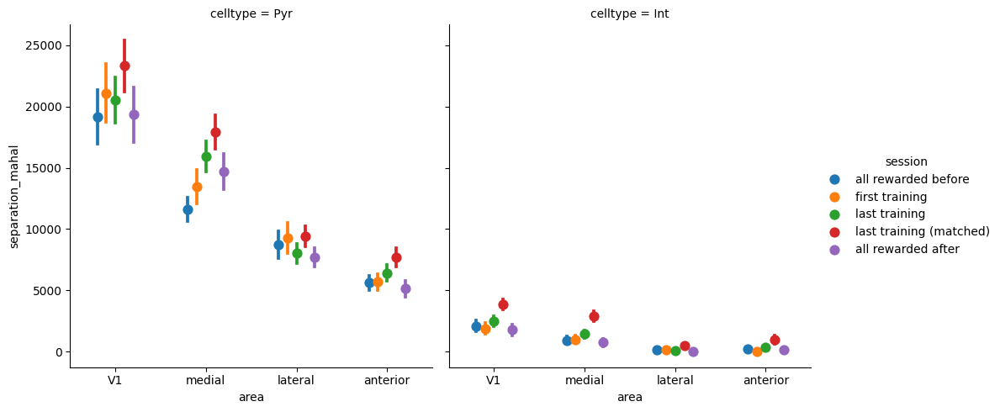

In [1249]:
sns.catplot(data=manifold_geom_df, x='area', y='separation_mahal', col="celltype", hue='session', errorbar='se', kind='point', width=4, aspect=1, dodge=.4, linestyle='none')

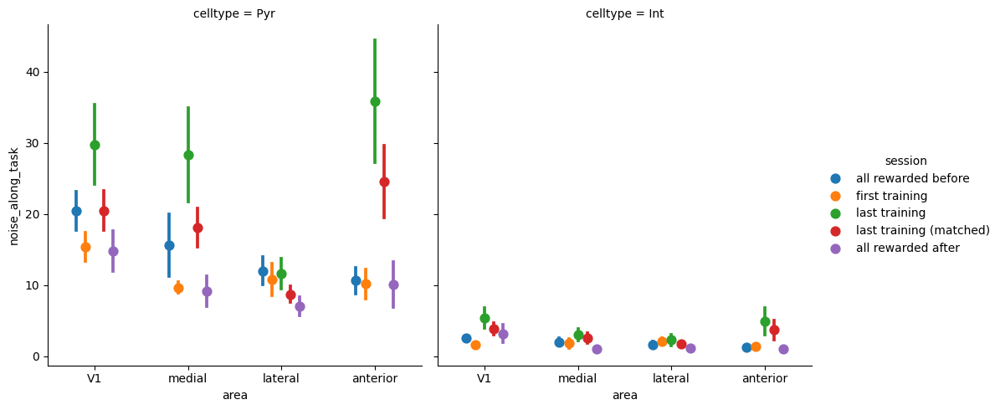

In [1247]:
sns.catplot(data=manifold_geom_df, x='area', y='noise_along_task', col="celltype", hue='session', errorbar='se', kind='point', width=4, aspect=1, dodge=.4, linestyle='none')

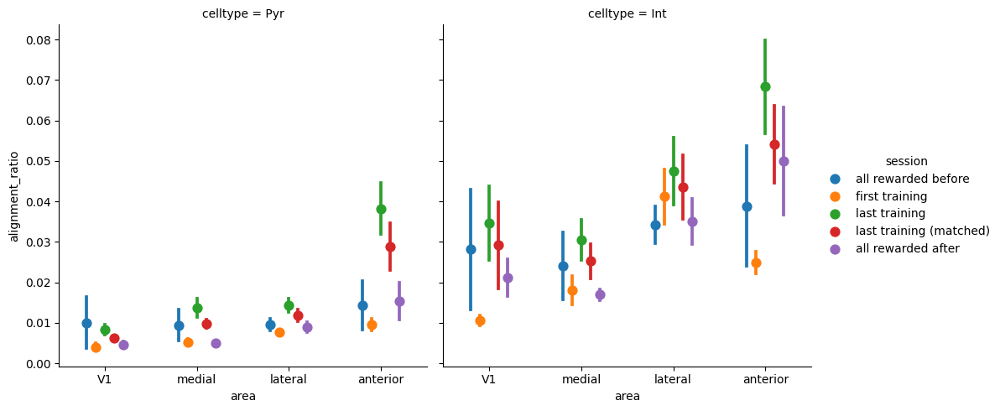

In [1248]:
sns.catplot(data=manifold_geom_df, x='area', y='alignment_ratio', col="celltype", hue='session', errorbar='se', kind='point', width=4, aspect=1, dodge=.4, linestyle='none')

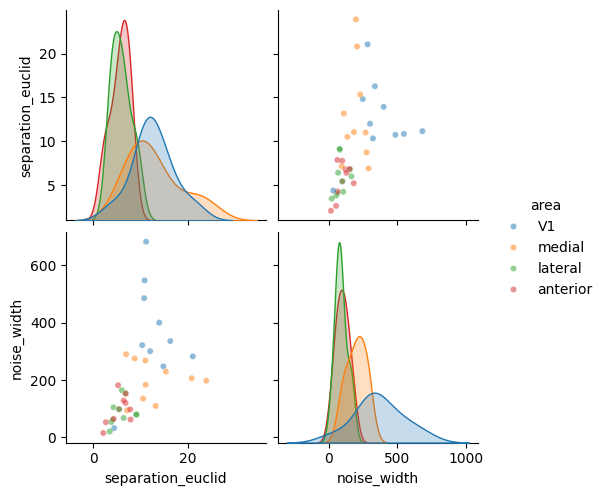

In [1206]:
sns.pairplot(manifold_geom_df.query("celltype == 'Pyr' & session == 'last training (matched)'"), vars=['separation_euclid', 'noise_width'], hue='area', diag_kind='kde', plot_kws={'alpha':0.5, 's':20})

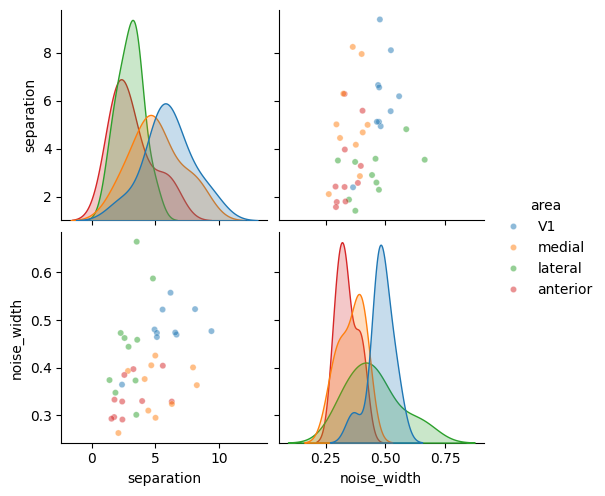

In [436]:
sns.pairplot(manifold_geom_df.query("celltype == 'Int' & session == 'last training (matched)'"), vars=['separation', 'noise_width'], hue='area', diag_kind='kde', plot_kws={'alpha':0.5, 's':20})

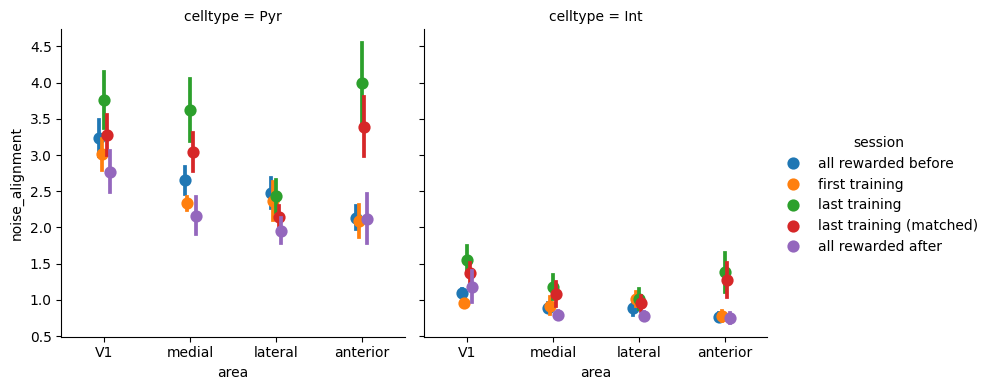

In [430]:
sns.catplot(data=manifold_geom_df, x='area', y='noise_alignment', col="celltype", hue='session', errorbar='se', dodge=True, kind='point', height=4, aspect=1, linestyle="none")

In [487]:
from scipy.stats import mannwhitneyu
def calculate_invariance_indices(proj_R_prot, proj_NR_prot, proj_R_rest, proj_NR_rest):
    """
    Computes three flavors of the Invariance Index based on projection scores.
    """
    epsilon = 1e-6
    
    # --- Helper: d-prime calculation ---
    def get_dprime(pos, neg):
        mu_diff = np.mean(pos) - np.mean(neg)
        std_avg = np.sqrt(0.5 * (np.var(pos) + np.var(neg)))
        return mu_diff / (std_avg + epsilon)

    # --- Helper: AUC calculation ---
    def get_auc(pos, neg):
        # Mann-Whitney U is mathematically equivalent to AUC
        try:
            u_stat, p_val = mannwhitneyu(pos, neg, alternative='two-sided')
            return u_stat / (len(pos) * len(neg))
        except ValueError:
            return 0.5 # Chance level
    
    def calculate_ii_auc(auc_prot, auc_rest, threshold=0.05):
        """
        Calculates the percentage of category information preserved.
        Ideal = 1.0
        """
        # Isolate signal above chance
        signal_prot = auc_prot - 0.5
        signal_rest = auc_rest - 0.5
        
        # Stability Guard: If there's no signal in the Prototypes, 
        # we can't measure transfer (set to 0 or NaN)
        if signal_prot < threshold:
            return 0.0
        
        # Calculate the ratio of preserved information
        ii_auc = signal_rest / signal_prot
        
        # Optional: Clip at 1.0 if you want to cap "better than prototype" cases
        # return np.clip(ii_auc, None, 1.0) 
        return ii_auc

    # 1. Centroid Separation Ratio (Pure Geometry)
    sep_prot = np.mean(proj_R_prot) - np.mean(proj_NR_prot)
    sep_rest = np.mean(proj_R_rest) - np.mean(proj_NR_rest)
    ii_centroid = sep_rest / (sep_prot + epsilon)

    # 2. d-Prime Ratio (Signal-to-Noise / Reliability)
    dp_prot = get_dprime(proj_R_prot, proj_NR_prot)
    dp_rest = get_dprime(proj_R_rest, proj_NR_rest)
    ii_dprime = dp_rest / (dp_prot + epsilon)

    # 3. AUC Ratio (Non-parametric / Probability)
    auc_prot = get_auc(proj_R_prot, proj_NR_prot)
    auc_rest = get_auc(proj_R_rest, proj_NR_rest)
    # We normalize AUC to be centered at 0 (range -0.5 to 0.5) to make the ratio meaningful
    ii_auc = calculate_ii_auc(auc_prot, auc_rest, threshold=0.05)

    return {
        "ii_centroid": ii_centroid,
        "ii_dprime": ii_dprime,
        "ii_auc": ii_auc,
        "auc_prot": auc_prot,
        "auc_rest": auc_rest
    }

In [488]:
obj_path = Path(r"D:\mouseobj")
rows = []
for iss, sess in enumerate(sessions_names):
    if sess == 'last training (matched)':
        session = 'last training'
    else:
        session = sess
    d = working_dbase.query(f"session == '{session}'")
    print(f"Processing: {sess}")
    for i, (_, row) in enumerate(d.iterrows()):
        name, datexp, blk = row["mname"], row["datexp"], row["blk"]
        m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")
        save_pth = obj_path.joinpath(name,datexp,blk)
        if sess == 'last training (matched)':
            t_dict = get_matched_trials(m)
            dp_nonprot = np.load(save_pth.joinpath("dp_rest_nosplit_matched.npy"))
        else:
            t_dict = m.trial_dict
            dp_nonprot = np.load(save_pth.joinpath("dp_rest_nosplit.npy"))
        for iaa, area in enumerate(areas):
            ia = utils.get_region_idx(m.iarea, area)
            alignment = ei_alignment(m, ia, t_dict)
            for ic, cell in enumerate(celltype):
                sel_type = np.logical_not(m.isred[:, 0]).astype(bool) if cell == 'Pyr' else m.isred[:, 0].astype(bool)
                selection = ia * sel_type
                angle, proj_R_prot, proj_NR_prot, proj_R_rest, proj_NR_rest = get_projections(m, selection, t_dict)
                invariances = calculate_invariance_indices(proj_R_prot, proj_NR_prot, proj_R_rest, proj_NR_rest)
                dp_sel = dp_nonprot[selection]
                signal_magnitude = np.sqrt(np.mean(dp_sel**2))
                prot_sep = dp_inv(proj_R_prot, proj_NR_prot)
                rows.append({'name': name, 'datexp': datexp, 'blk': blk, 
                             'session': sess, 'celltype': cell, 'area': area, "fidelity": prot_sep, "signal_magnitude": signal_magnitude,
                             **invariances, 'angle': angle, 'ei_angle': alignment})
    clear_output(wait=True)
multiple_invariances_df = pd.DataFrame(rows)

Processing: all rewarded after
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_01\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_15\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG14\20

In [637]:
multiple_invariances_df.shape

(392, 16)

In [639]:
multiple_invariances_df["mouse_id"] = topdpprot_gainvsgeom_df["name_id"]

In [489]:
multiple_invariances_df.query("area == 'V1' & celltype == 'Pyr' & session == 'first training'")

,name,datexp,blk,session,celltype,area,fidelity,signal_magnitude,ii_centroid,ii_dprime,ii_auc,auc_prot,auc_rest,angle,ei_angle
80,VG11,2024_10_16,2,first training,Pyr,V1,11.367460,0.299881,0.101388,0.111873,0.617576,1.0,0.808788,0.121009,0.532669
88,VG11,2024_11_05,3,first training,Pyr,V1,10.874489,0.340302,0.117595,0.155466,0.773737,1.0,0.886869,0.196493,0.566266
96,VG14,2024_10_16,2,first training,Pyr,V1,11.278875,0.217028,0.046902,0.063831,0.368283,1.0,0.684141,0.110873,0.643191
104,VG15,2024_10_16,2,first training,Pyr,V1,10.998720,0.364837,0.176707,0.300472,0.987400,1.0,0.993700,0.251360,0.787436
112,VG21,2025_06_25,2,first training,Pyr,V1,13.365632,0.540220,0.361644,0.365205,1.000000,1.0,1.000000,0.311457,0.798173
120,VG21,2025_07_22,2,first training,Pyr,V1,11.450277,0.369692,0.264170,0.240845,0.943000,1.0,0.971500,0.271332,0.771390
128,VG24,2025_06_26,2,first training,Pyr,V1,7.776514,0.302417,0.050974,0.039753,0.167000,1.0,0.583500,0.074890,0.383613
136,VG33,2025_10_01,2,first training,Pyr,V1,15.259937,0.579996,0.291749,0.307098,1.000000,1.0,1.000000,0.274044,0.867310
144,VG34,2025_10_01,2,first training,Pyr,V1,12.969958,0.670706,0.445322,0.454780,1.000000,1.0,1.000000,0.361330,0.869591
152,VGa9,2025_11_07,3,first training,Pyr,V1,14.950986,0.417319,0.132517,0.174246,0.949697,1.0,0.974848,0.186155,0.708830


In [490]:
multiple_invariances_df.query("area == 'V1' & celltype == 'Pyr' & session == 'last training (matched)'")

,name,datexp,blk,session,celltype,area,fidelity,signal_magnitude,ii_centroid,ii_dprime,ii_auc,auc_prot,auc_rest,angle,ei_angle
240,VG11,2024_10_31,2,last training (matched),Pyr,V1,8.847732,0.365039,0.096099,0.111980,0.514575,1.0,0.757287,0.181079,0.725026
248,VG11,2024_11_14,2,last training (matched),Pyr,V1,10.640362,0.471187,0.208350,0.191638,0.818878,1.0,0.909439,0.226537,0.824859
256,VG14,2024_11_21,2,last training (matched),Pyr,V1,11.559549,0.336186,0.146415,0.157219,0.777392,1.0,0.888696,0.228022,0.820147
264,VG15,2024_10_31,2,last training (matched),Pyr,V1,11.824273,0.362314,0.087174,0.114240,0.644231,1.0,0.822115,0.139965,0.661110
272,VG21,2025_07_17,3,last training (matched),Pyr,V1,10.295974,0.636453,0.435464,0.389456,0.999444,1.0,0.999722,0.391671,0.955790
280,VG21,2025_08_07,2,last training (matched),Pyr,V1,15.736404,0.530873,0.275983,0.212932,0.980800,1.0,0.990400,0.278082,0.816184
288,VG24,2025_07_10,2,last training (matched),Pyr,V1,5.295375,0.487751,0.294737,0.297010,0.779773,1.0,0.889887,0.297769,0.796776
296,VG33,2025_10_09,3,last training (matched),Pyr,V1,9.084693,0.679474,0.569899,0.613681,0.999228,1.0,0.999614,0.503176,0.929228
304,VG34,2025_10_10,3,last training (matched),Pyr,V1,12.613262,0.663504,0.409554,0.332993,0.995473,1.0,0.997737,0.333109,0.864910
312,VGa9,2025_11_20,2,last training (matched),Pyr,V1,11.221173,0.501040,0.249488,0.310845,0.986395,1.0,0.993197,0.188908,0.892082


In [641]:
multiple_invariances_df.to_csv(r"D:\mouseobj\overall\multiple_invariances_gain_vs_geometry_analysis.csv", index=False)

In [532]:
ii_dp = get_feature_fromdf("ii_dprime", multiple_invariances_df)

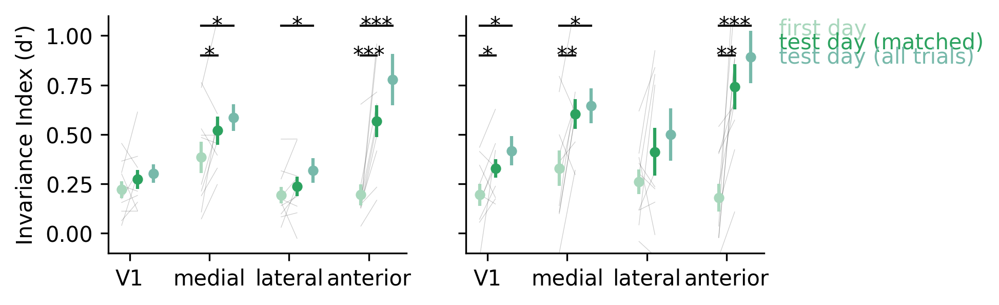

In [568]:
gis_first = ii_dp['first training']
gis_last = ii_dp['last training']
gis_last_m = ii_dp['last training (matched)']
fig, ax = plt.subplots(1,2, figsize=(5.5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=.9, sig_line_control=1.05, ylabel='Invariance Index (d\')')
for a in ax.flatten():
    a.set_ylim(-.1,1.1)
sns.despine()

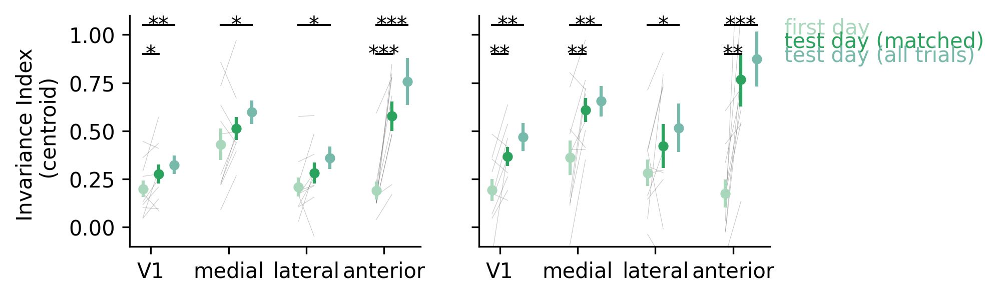

In [539]:
ii_centroid = get_feature_fromdf("ii_centroid", multiple_invariances_df)
gis_first = ii_centroid['first training']
gis_last = ii_centroid['last training']
gis_last_m = ii_centroid['last training (matched)']
fig, ax = plt.subplots(1,2, figsize=(5.5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=.9, sig_line_control=1.05, ylabel='Invariance Index \n (centroid)')
for a in ax.flatten():
    a.set_ylim(-.1,1.1)
sns.despine()

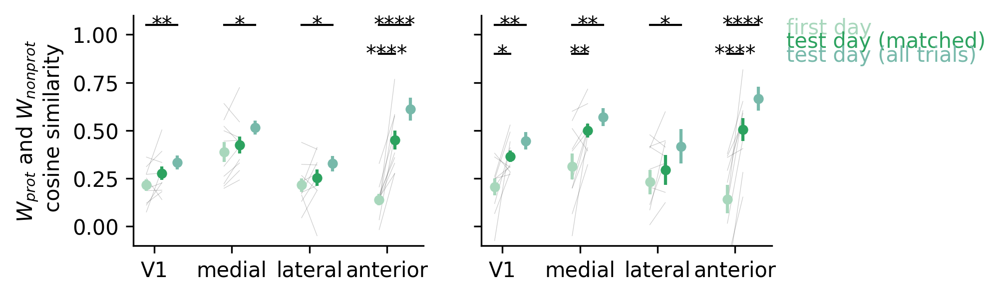

In [536]:
angles = get_feature_fromdf("angle", multiple_invariances_df)
gis_first = angles['first training']
gis_last = angles['last training']
gis_last_m = angles['last training (matched)']
fig, ax = plt.subplots(1,2, figsize=(5.5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=.9, sig_line_control=1.05, ylabel='$W_{prot}$ and $W_{nonprot}$ \n cosine similarity')
for a in ax.flatten():
    a.set_ylim(-.1,1.1)
sns.despine()

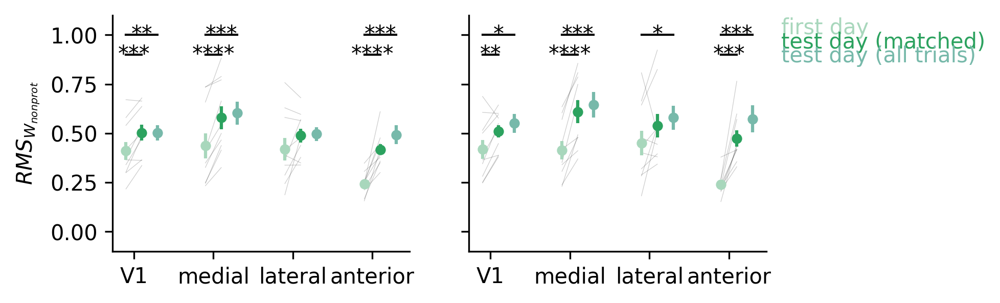

In [541]:
angles = get_feature_fromdf("signal_magnitude", multiple_invariances_df)
gis_first = angles['first training']
gis_last = angles['last training']
gis_last_m = angles['last training (matched)']
fig, ax = plt.subplots(1,2, figsize=(5.5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=.9, sig_line_control=1, ylabel='$RMS_{W_{nonprot}}$')
for a in ax.flatten():
    a.set_ylim(-.1,1.1)
sns.despine()

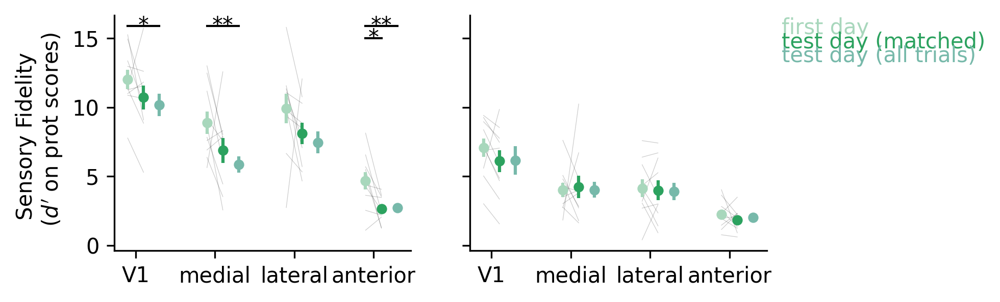

In [561]:
fidelity = get_feature_fromdf("fidelity", multiple_invariances_df)
gis_first = fidelity['first training']
gis_last = fidelity['last training']
gis_last_m = fidelity['last training (matched)']
fig, ax = plt.subplots(1,2, figsize=(5.5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=15, sig_line_control=15.9, ylabel='Sensory Fidelity \n $(d\'$ on prot scores)', alternative='two-sided')
#for a in ax.flatten():
#    a.set_ylim(-.1,1.1)
sns.despine()

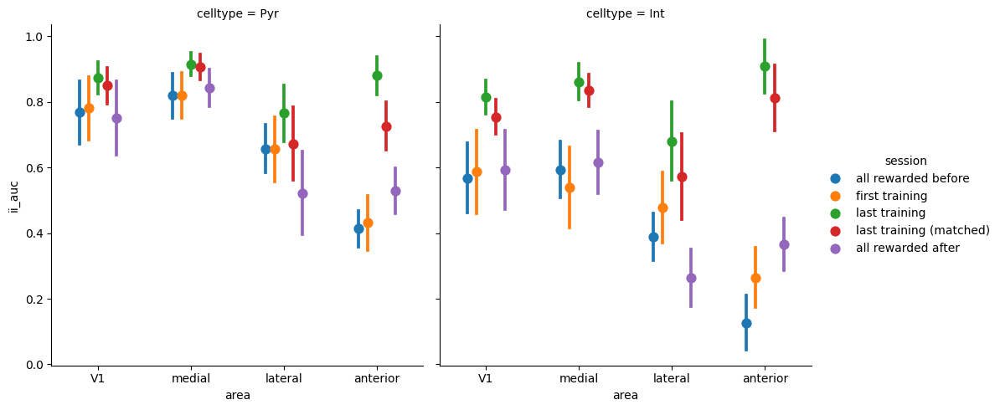

In [498]:
sns.catplot(data=multiple_invariances_df, x='area', y='ii_auc', col="celltype", hue='session', errorbar='se', kind='point', width=4, aspect=1, dodge=.4, linestyle='none')

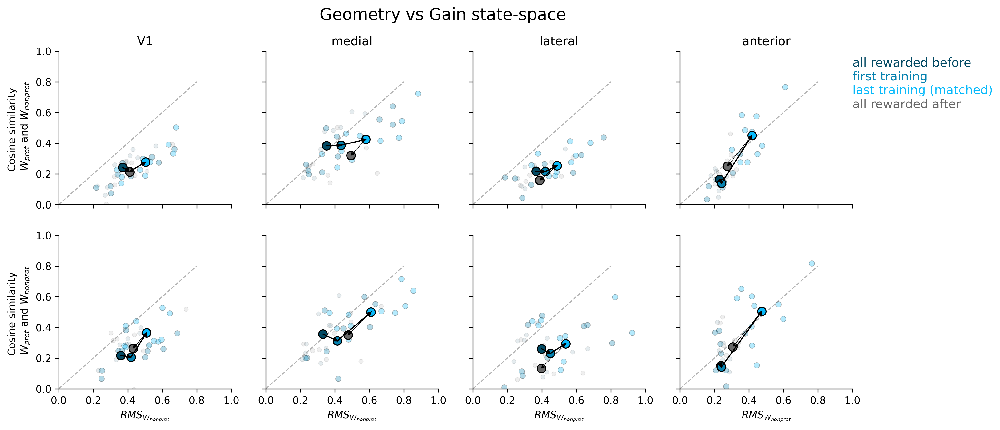

In [642]:
palette = ["#034a64", "#0682b0", "#08bafb", '#686868']
session_names = ['first training', 'last training (matched)']
sessions_names_all = ['all rewarded before', 'first training', 'last training (matched)', 'all rewarded after']
fig, axes = plt.subplots(2, len(areas), figsize=(14, 6), sharex=True, sharey=True, dpi=300)
all_means = np.zeros((len(areas), len(celltype), len(sessions_names_all), 2))
for iaa, area in enumerate(areas):
    axes[1, iaa].set_xlabel('$RMS_{W_{nonprot}}$')
    axes[0, iaa].set_title(f"{area}")
    for ic, cell in enumerate(celltype):
        axes[ic,0].set_ylabel('Cosine similarity \n $W_{prot}$ and $W_{nonprot}$')
        for iss, session in enumerate(sessions_names_all):
            sub_df = multiple_invariances_df.query(f"area == '{area}' & session == '{session}' & celltype == '{cell}'")
            ax = axes[ic, iaa]
            if session in ['all rewarded before', 'all rewarded after']:
                ax.scatter(sub_df['signal_magnitude'], sub_df['angle'], alpha=0.1, color = palette[iss], edgecolors='black', linewidth=0.5,  zorder=0, s=18)
            else:
                ax.scatter(sub_df['signal_magnitude'], sub_df['angle'], alpha=0.3, color = palette[iss], edgecolors='black', linewidth=0.5,  zorder=0, s=30)
            means = (sub_df["signal_magnitude"].mean(), sub_df["angle"].mean())
            # add 45 line
            ax.plot([0, .8], [0, .8], color='gray', linestyle='--', linewidth=1, zorder=0, alpha=0.2)
            ax.scatter(*means, color=palette[iss], s=70, marker='o', edgecolors='black', linewidth=1)
            all_means[iaa, ic, iss] = means
            ax.set_ylim(0, 1)
            ax.set_xlim(0, 1)
                       
for iaa, area in enumerate(areas):
    for ic, cell in enumerate(celltype):
            origin = (all_means[iaa, ic, 0, 0], all_means[iaa, ic, 0, 1])
            direction = (all_means[iaa, ic, 1, 0] - all_means[iaa, ic, 0, 0], all_means[iaa, ic, 1, 1] - all_means[iaa, ic, 0, 1])
            axes[ic, iaa].arrow(origin[0], origin[1], direction[0], direction[1], head_width=0.02, head_length=0.02, fc='k', ec='k', linewidth=1, length_includes_head=True, zorder=1)
            origin = (all_means[iaa, ic, 1, 0], all_means[iaa, ic, 1, 1])
            direction = (all_means[iaa, ic, 2, 0] - all_means[iaa, ic, 1, 0], all_means[iaa, ic, 2, 1] - all_means[iaa, ic, 1, 1])
            axes[ic, iaa].arrow(origin[0], origin[1], direction[0], direction[1], head_width=0.02, head_length=0.02, fc='k', ec='k', linewidth=1, length_includes_head=True, zorder=1)
            origin = (all_means[iaa, ic, 2, 0], all_means[iaa, ic, 2, 1])
            direction = (all_means[iaa, ic, 3, 0] - all_means[iaa, ic, 2, 0], all_means[iaa, ic, 3, 1] - all_means[iaa, ic, 2, 1])
            axes[ic, iaa].arrow(origin[0], origin[1], direction[0], direction[1], head_width=0.02, head_length=0.02, fc='k', ec='k', linewidth=0.5, linestyle='-.',
                                 length_includes_head=True, zorder=1)
for lab in sessions_names_all:
    axes[0, 3].text(1, .9 - 0.09 * sessions_names_all.index(lab), lab, fontsize=12, transform=axes[0, 3].transAxes, color=palette[sessions_names_all.index(lab)])
fig.suptitle('Geometry vs Gain state-space', fontsize=16)
sns.despine()

In [643]:
cleaned_reg_df  = multiple_invariances_df.query("session in ['first training', 'last training (matched)']").copy() 
cleaned_reg_df["area"]  = pd.Categorical(cleaned_reg_df["area"], categories=["V1", "lateral", "medial", "anterior"], ordered=True) 
cleaned_reg_df["sig_gain_centered"] = cleaned_reg_df["signal_magnitude"] - cleaned_reg_df["signal_magnitude"].mean()

In [645]:
exc = cleaned_reg_df.query("celltype == 'Pyr'")
model = smf.mixedlm("angle ~ (sig_gain_centered * area)", exc, groups=exc["mouse_id"])
results = model.fit()
print(results.summary())

                    Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         angle  
No. Observations:         80              Method:                     REML   
No. Groups:               10              Scale:                      0.0060 
Min. group size:          8               Log-Likelihood:             73.3056
Max. group size:          8               Converged:                  Yes    
Mean group size:          8.0                                                
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                           0.240    0.021 11.500 0.000  0.199  0.281
area[T.lateral]                    -0.009    0.025 -0.368 0.713 -0.057  0.039
area[T.medial]                      0.130    0.025  5.134 0.000  0.080  0.179
area[T

c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [646]:
exc = cleaned_reg_df.query("celltype == 'Int'")
model = smf.mixedlm("angle ~ (sig_gain_centered * area)", exc, groups=exc["mouse_id"])
#try differen methods 
results = model.fit()
print(results.summary())

                    Mixed Linear Model Regression Results
Model:                    MixedLM         Dependent Variable:         angle  
No. Observations:         80              Method:                     REML   
No. Groups:               10              Scale:                      0.0265 
Min. group size:          8               Log-Likelihood:             20.3765
Max. group size:          8               Converged:                  Yes    
Mean group size:          8.0                                                
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                           0.273    0.042  6.495 0.000  0.191  0.355
area[T.lateral]                    -0.029    0.053 -0.561 0.575 -0.132  0.073
area[T.medial]                      0.083    0.053  1.552 0.121 -0.022  0.187
area[T

c:\Users\labadmin\anaconda3\envs\categoryneural_312\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [1063]:
def mistakes_analysis_dp(m, ia, celltype, dp, trial_dict, dp_tsh=95, zscored_nonprot=False):
    sel_type = np.logical_not(m.isred[:, 0]).astype(bool) if celltype == 'Pyr' else m.isred[:, 0].astype(bool)
    Rprot, NRprot, Rrest, NRrest = trial_dict["rewarded"], trial_dict["non rewarded"], trial_dict["rewarded test"], trial_dict["non rewarded test"]
    correct, incorrect = utils.build_correct_dicts(m)
    correct_protA = np.intersect1d(correct["rewarded"], Rprot)
    correct_protB = np.intersect1d(correct["non rewarded"], NRprot)
    pstv_tsh, ngtv_tsh = utils.get_dp_thresholds(dp[ia*sel_type], tsh=dp_tsh) # top 10%
    prefer_r = (dp>=pstv_tsh)
    prefer_nr = (dp<=ngtv_tsh)
    selective_neurons = prefer_r + prefer_nr
    selection = ia * sel_type * selective_neurons

    all_means = m.interp_spks[:,:,:100].mean(2)
    means_ = all_means[selection,:]
    means_ = means_.T  

    w_ = means_[correct_protA[::2]].mean(0) - means_[correct_protB[::2]].mean(0)
    cd = w_ / (np.linalg.norm(w_) + np.finfo(np.float64).tiny)

    # project all trials 
    p_ = means_ @ cd
    #lets zscore them agaisnt the non rewarded prototype trials
    if zscored_nonprot:
      p_ = (p_ - p_[correct_protB[::2]].mean()) / (p_[correct_protB[::2]].std() + 1e-6)
      #now 0 is the non rewarded state , lets grab each projection for the rest trials
    
    p_hit_prot = p_[correct_protA[1::2]]
    p_cr_prot = p_[correct_protB[1::2]]
    p_om_prot = p_[incorrect["rewarded"]]
    p_fa_prot = p_[incorrect["non rewarded"]]
    p_hit_nonprot = p_[correct["rewarded test"]]
    p_cr_nonprot = p_[correct["non rewarded test"]]
    p_om_nonprot = p_[incorrect["rewarded test"]]
    p_fa_nonprot = p_[incorrect["non rewarded test"]]

    scores = {"hit_prot": p_hit_prot,
              "cr_prot": p_cr_prot,
              "om_prot": p_om_prot,
              "fa_prot": p_fa_prot,
              "hit": p_hit_nonprot,
              "correct rejection": p_cr_nonprot,
              "miss": p_om_nonprot,
              "false alarm": p_fa_nonprot}
    
    return scores

In [ ]:
def mistakes_analysis(m, selection, trial_dict, zscored_nonprot=False):
    all_means = m.interp_spks[:,:,:100].mean(2)
    all_means = all_means[selection,:]
    all_means = all_means.T  
    is_exc = np.logical_not(m.isred[selection, 0]).astype(bool)
    is_inh = m.isred[selection, 0].astype(bool)
    means_exc = all_means[:, is_exc]  # Excitatory neurons
    means_inh = all_means[:, is_inh]  # Inhibitory neuron
    Rprot, NRprot, Rrest, NRrest = trial_dict["rewarded"], trial_dict["non rewarded"], trial_dict["rewarded test"], trial_dict["non rewarded test"]
    correct, incorrect = utils.build_correct_dicts(m)
    correct_protA = np.intersect1d(correct["rewarded"], Rprot)
    correct_protB = np.intersect1d(correct["non rewarded"], NRprot)
    w_exc = means_exc[correct_protA[::2]].mean(0) - means_exc[correct_protB[::2]].mean(0)
    w_inh = means_inh[correct_protA[::2]].mean(0) - means_inh[correct_protB[::2]].mean(0)
    # project all trials 
    p_e = means_exc @ w_exc
    p_i = means_inh @ w_inh
    #lets zscore them agaisnt the non rewarded prototype trials
    if zscored_nonprot:
      z_e = (p_e - p_e[correct_protB[::2]].mean()) / (p_e[correct_protB[::2]].std() + 1e-6)
      z_i = (p_i - p_i[correct_protB[::2]].mean()) / (p_i[correct_protB[::2]].std() + 1e-6)
    #now 0 is the non rewarded state , lets grab each projection for the rest trials
      z_e_hit_prot = p_e[correct_protA[1::2]]
      z_i_hit_prot = p_i[correct_protA[1::2]]
      z_e_om_prot = p_e[incorrect["rewarded"]]
      z_i_om_prot = p_i[incorrect["rewarded"]]
      z_e_cr_prot = p_e[correct_protB[1::2]]
      z_i_cr_prot = p_i[correct_protB[1::2]]
      z_e_fa_prot = p_e[incorrect["non rewarded"]]
      z_i_fa_prot = p_i[incorrect["non rewarded"]]
      z_e_hit = z_e[correct["rewarded test"]]
      z_i_hit = z_i[correct["rewarded test"]]
      z_e_cr = z_e[correct["non rewarded test"]]
      z_i_cr = z_i[correct["non rewarded test"]]
      z_e_om = z_e[incorrect["rewarded test"]]
      z_i_om = z_i[incorrect["rewarded test"]]
      z_e_fa = z_e[incorrect["non rewarded test"]]
      z_i_fa = z_i[incorrect["non rewarded test"]]
    else:
      z_e_hit_prot = p_e[correct_protA[1::2]]
      z_i_hit_prot = p_i[correct_protA[1::2]]
      z_e_om_prot = p_e[incorrect["rewarded"]]
      z_i_om_prot = p_i[incorrect["rewarded"]]
      z_e_cr_prot = p_e[correct_protB[1::2]]
      z_i_cr_prot = p_i[correct_protB[1::2]]
      z_e_fa_prot = p_e[incorrect["non rewarded"]]
      z_i_fa_prot = p_i[incorrect["non rewarded"]]
      z_e_hit = p_e[correct["rewarded test"]]
      z_i_hit = p_i[correct["rewarded test"]]
      z_e_cr = p_e[correct["non rewarded test"]]
      z_i_cr = p_i[correct["non rewarded test"]]
      z_e_om = p_e[incorrect["rewarded test"]]
      z_i_om = p_i[incorrect["rewarded test"]]
      z_e_fa = p_e[incorrect["non rewarded test"]]
      z_i_fa = p_i[incorrect["non rewarded test"]]
    scores_exc = {"hit_prot": z_e_hit_prot,
                  "cr_prot": z_e_cr_prot,
                  "om_prot": z_e_om_prot,
                  "fa_prot": z_e_fa_prot,
                "hit": z_e_hit,
                "correct rejection": z_e_cr,
                "miss": z_e_om,
                "false alarm": z_e_fa}
    
    scores_inh = {
                "hit_prot": z_i_hit_prot,
                "cr_prot": z_i_cr_prot,
                "om_prot": z_i_om_prot,
                "fa_prot": z_i_fa_prot,
                "hit": z_i_hit,
                "correct rejection": z_i_cr,
                "miss": z_i_om,
                "false alarm": z_i_fa}
    return scores_exc, scores_inh

In [1013]:
celltype

['Exc', 'Inh']

In [1064]:
def select_neurons(m1, ia, celltype:str, dprime = None, dptsh=95):
    assert celltype in ['Pyr', 'Int'], "celltype must be either 'Pyr' or 'Int'"
    selected_type = np.logical_not(m1.isred[:,0]).astype(bool) if celltype == 'Pyr' else m1.isred[:,0].astype(bool)
    if dprime is None:
        pstv_tsh, ngtv_tsh = utils.get_dp_thresholds(m1.train_dp[ia*selected_type], tsh=dptsh) #tresh based on the area
        prefer_r = (m1.train_dp>=pstv_tsh)
        prefer_nr = (m1.train_dp<=ngtv_tsh)
    else:
        pstv_tsh, ngtv_tsh = utils.get_dp_thresholds(dprime[ia*selected_type], tsh=dptsh)
        prefer_r = (dprime>=pstv_tsh)
        prefer_nr = (dprime<=ngtv_tsh)
    area_prefer_r = prefer_r * ia * selected_type
    area_prefer_nr = prefer_nr * ia * selected_type
    return area_prefer_r, area_prefer_nr, selected_type, ia

In [1065]:
rows = []
areas = ["V1", "medial", "lateral", "anterior"]
celltype = ['Pyr', 'Int']
obj_path = Path(r"D:\mouseobj")
sessions_names = ['last training (matched)']
for iss, sess in enumerate(sessions_names):
    if sess == 'last training (matched)':
        session = 'last training'
    else:
        session = sess
    d = working_dbase.query(f"session == '{session}'")
    print(f"Processing: {sess}")
    for i, (_, row) in enumerate(d.iterrows()):
        name, datexp, blk = row["mname"], row["datexp"], row["blk"]
        cds = np.full((4, len(areas), len(celltype), 2, 400), np.nan)  # trials x areas x celltypes x correct/incorrect x positions
        save_pth = obj_path.joinpath(name,datexp,blk)
        m = utils.load_mouse(name, datexp, blk, load_neurons=True, interp_behav=True, load_retinotopy=True, mdl_path=r"D:\mouseobj")
        if sess == 'last training (matched)':
            t_dict = get_matched_trials(m)
            correct, incorrect = utils.build_correct_dicts(m)
            correct_protA = np.intersect1d(correct["rewarded"], t_dict["rewarded"])
            correct_protB = np.intersect1d(correct["non rewarded"], t_dict["non rewarded"])
            dp = dprime_cell(m.interp_spks, correct_protA[::2], correct_protB[::2], discrimination_region=(0,100))
            trial_split_correct = {"rewarded": correct_protA[1::2], "non rewarded": correct_protB[1::2], "rewarded test": correct["rewarded test"], "non rewarded test": correct["non rewarded test"]}
            trial_split_incorrect = {"rewarded": incorrect["rewarded"], "non rewarded": incorrect["non rewarded"], "rewarded test": incorrect["rewarded test"], "non rewarded test": incorrect["non rewarded test"]}
            named = "cod_dirs_100_mistake_analysis_matched.npy"
        else:
            t_dict = m.trial_dict
            correct, incorrect = utils.build_correct_dicts(m)
            correct_protA = np.intersect1d(correct["rewarded"], t_dict["rewarded"])
            correct_protB = np.intersect1d(correct["non rewarded"], t_dict["non rewarded"])
            dp = dprime_cell(m.interp_spks, correct_protA[::2], correct_protB[::2], discrimination_region=(0,100))
            trial_split_correct = {"rewarded": correct_protA[1::2], "non rewarded": correct_protB[1::2], "rewarded test": correct["rewarded test"], "non rewarded test": correct["non rewarded test"]}
            trial_split_incorrect = {"rewarded": incorrect["rewarded"], "non rewarded": incorrect["non rewarded"], "rewarded test": incorrect["rewarded test"], "non rewarded test": incorrect["non rewarded test"]}
        #scores_dict_inh = {area: {} for area in areas}
        for iaa, area in enumerate(areas):
            ia = utils.get_region_idx(m.iarea, area)
            for ic, cell in enumerate(celltype):
                scores = mistakes_analysis_dp(m, ia, cell, dp, t_dict, zscored_nonprot=False)
                rows.append({'name': name, 'datexp': datexp, 'blk': blk, 'session': sess, 'celltype': cell, 'area': area, 
                            "hit prot": scores["hit_prot"].mean(), "cr prot": scores["cr_prot"].mean(), "om prot": scores["om_prot"].mean(), "fa prot": scores["fa_prot"].mean(),
                            "hit nprot": scores["hit"].mean(), "cr nonprot": scores["correct rejection"].mean(), "miss nonprot": scores["miss"].mean(), "false alarm": scores["false alarm"].mean()})
                a_prefer, b_prefer, _ , _ = select_neurons(m, ia, cell, dprime=dp, dptsh=95)
                print(f"{area} {cell} : a prefer: {a_prefer.sum()} b prefer: {b_prefer.sum()}")
                #if a_prefer.sum() == 0 or b_prefer.sum() == 0:
                #    continue
                cd = m.interp_spks[a_prefer].mean(0) - m.interp_spks[b_prefer].mean(0)
                for it, trials in enumerate(trial_split_correct.values()):
                    cds[it, iaa, ic, 0, :] = cd[trials,:].mean(0)
                for it, trials in enumerate(trial_split_incorrect.values()):
                    cds[it, iaa, ic, 1, :] = cd[trials,:].mean(0)
        np.save(save_pth.joinpath(named), cds)
            #scores_dict_exc[area] = scores
            #scores_dict_inh[area] = scores_inh
        #np.save(save_pth.joinpath("exc_scores_mistake_analysis.npy"), scores_dict_exc)
        #np.save(save_pth.joinpath("inh_scores_mistake_analysis.npy"), scores_dict_inh)
    clear_output(wait=True)
mistake_analysis_df = pd.DataFrame(rows)

Processing: last training (matched)
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_10_31\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline', '_data_var', '_settings', '_timestamps', '_trial_info', '_spks', '_ypos', '_xpos', '_iplane', '_stat', '_ops', '_snr', '_is_cell', 'xy_t', 'iarea', 'iregion', 'outline', 'frameselector', 'isred', 'trial_dict', 'interp_spks', 'train_dp'])
V1 Pyr : a prefer: 476 b prefer: 476
V1 Int : a prefer: 22 b prefer: 22
medial Pyr : a prefer: 364 b prefer: 364
medial Int : a prefer: 9 b prefer: 9
lateral Pyr : a prefer: 157 b prefer: 157
lateral Int : a prefer: 11 b prefer: 11
anterior Pyr : a prefer: 275 b prefer: 275
anterior Int : a prefer: 17 b prefer: 17
Checking if model object exists ...
Loading mouse object from D:\mouseobj\VG11\2024_11_14\2
Existing mouse object has the following attributes:
dict_keys(['name', 'datexp', 'blk', 'data_path', '_timeline'

In [1321]:
celltype = ['Pyr', 'Int']
areas = ['V1', 'medial', 'lateral', 'anterior']
sessions_names = ['last training (matched)']
obj_path = Path(r"D:\mouseobj")
cds_all_ci = np.zeros((10, 4, len(areas), len(celltype), 2, 400))
#named = "coding_dir_100.npy"
for iss, sess in enumerate(sessions_names):
    if sess == 'last training (matched)':
        session = 'last training'
        named = "cod_dirs_100_mistake_analysis_matched.npy"
    else:   
        session = sess
    d = working_dbase.query(f"session == '{session}'")
    print(f"Processing: {sess}")
    for i, (_, row) in enumerate(d.iterrows()):
        name, datexp, blk = row["mname"], row["datexp"], row["blk"]
        save_pth = obj_path.joinpath(name,datexp,blk)
        cd = np.load(save_pth.joinpath(named))
        cds_all_ci[i] = cd
cds_all_ci.shape

Processing: last training (matched)


(10, 4, 4, 2, 2, 400)

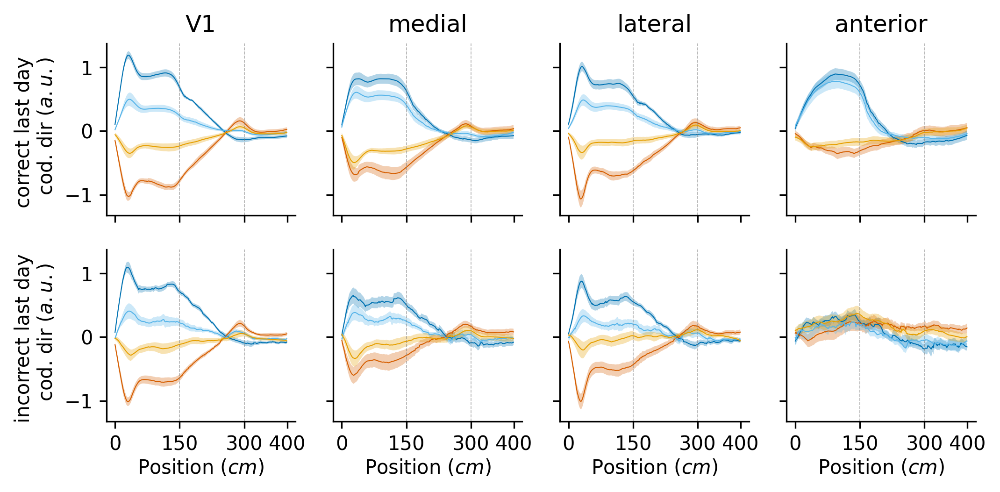

In [1561]:
fig, cds_axs = plt.subplots(2, len(areas), figsize=(8, 3.5), dpi=300,sharex=True, sharey=True)
correct = cds_all_ci[:,:,:,:,0,:]
incorrect = cds_all_ci[:,:,:,:,1,:]
for a, area in enumerate(areas):
    for ttype in range(4):
        fig1.plot_cds(correct, ttype, a, 0, cds_axs[0, a], references=True)
        fig1.plot_cds(incorrect, ttype, a, 0, cds_axs[1, a], references=True)
rows, cols = cds_axs.shape
for i in range(rows):
    for j in range(cols):
        cds_axs[i, j].set_xticks([0, 150, 300, 400])
        cds_axs[0, j].set_title(f"{areas[j]}")
        if i == 1:
            cds_axs[i, j].set_xlabel("Position ($cm$)", labelpad=2)
cds_axs[0,0].set_ylabel("correct last day \n cod. dir ($a.u.$)")
cds_axs[1,0].set_ylabel("incorrect last day \n cod. dir ($a.u.$)")
sns.despine()

In [1081]:
mistake_analysis_df.rename(columns={"hit prot": "hit_prot", "cr prot": "cr_prot", "om prot": "om_prot", "fa prot": "fa_prot",
                                  "hit nprot": "hit_nonprot", "cr nonprot": "cr_nonprot", "miss nonprot": "miss_nonprot", "false alarm": "fa_nonprot"}, inplace=True)

In [1082]:
mistake_analysis_df.to_csv(r"D:\mouseobj\overall\mistake_analysis.csv", index=False)

In [1083]:
mistake_analysis_df

,name,datexp,blk,session,celltype,area,hit_prot,cr_prot,om_prot,fa_prot,hit_nonprot,cr_nonprot,miss_nonprot,fa_nonprot
0,VG11,2024_10_31,2,last training (matched),Pyr,V1,17.872960,-11.638029,15.322475,-11.818963,4.066626,-0.766328,1.148356,0.268150
1,VG11,2024_10_31,2,last training (matched),Int,V1,3.914784,-0.408915,1.861391,0.604275,3.138446,0.861940,0.660202,2.001034
2,VG11,2024_10_31,2,last training (matched),Pyr,medial,9.013274,-1.120299,2.090290,0.259883,6.754831,-0.120389,0.364894,2.816703
3,VG11,2024_10_31,2,last training (matched),Int,medial,1.530986,-0.562374,-0.045677,-0.247557,1.435130,0.030583,0.441709,0.559628
4,VG11,2024_10_31,2,last training (matched),Pyr,lateral,9.296433,-4.170986,6.045694,-3.674211,4.454662,0.804231,0.743393,2.119072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,VGa9,2025_11_20,2,last training (matched),Int,medial,2.931283,-4.069829,2.383173,-3.418439,2.591560,-1.545203,0.228728,-1.056523
76,VGa9,2025_11_20,2,last training (matched),Pyr,lateral,7.775900,-5.626678,4.573547,-4.268928,3.482779,0.065667,0.957943,-0.120147
77,VGa9,2025_11_20,2,last training (matched),Int,lateral,2.529081,-0.871601,1.202472,-0.528784,0.780106,-0.145540,0.125487,0.021672
78,VGa9,2025_11_20,2,last training (matched),Pyr,anterior,6.757444,-3.198212,3.286621,0.352243,5.883488,-2.259033,-1.413727,0.534120


In [1619]:
def get_sep_from_cds(cds):
    rew_trials = [0, 2]
    nr_trials = [1, 3]
    avg_cd = cds[:,:,:,:,:100].mean(-1)
    sep = avg_cd[:,rew_trials] - avg_cd[:,nr_trials]
    prot_sep = sep[:,0]  # rewarded - non rewarded prot
    rest_sep = sep[:,1]  # rewarded - non rewarded rest
    invariance_index = rest_sep / (prot_sep + 1e-6)
    invariance_index = np.where((prot_sep < 0) & (rest_sep < 0), -1*invariance_index, invariance_index)  # Flip sign if either is negative
    return prot_sep, rest_sep, invariance_index

def bootstrap_invariance(prot_sep, rest_sep, n_bootstrap=20000, random_state=333):
    """
    Estimate the standard error of a statistic via bootstrap.
    """

    rng = np.random.default_rng(random_state)
    data = np.asarray(prot_sep)  # Assuming prot_sep and rest_sep are the same length
    n = len(data)

    bootstrap_stats = np.empty(n_bootstrap)

    for i in range(n_bootstrap):
        indexs = rng.choice(np.arange(n), size=10, replace=True)
        sample_prot = prot_sep[indexs]
        sample_rest = rest_sep[indexs]
        s_mean_prot = np.mean(sample_prot)
        s_mean_rest = np.mean(sample_rest)
        sample_invariance = s_mean_rest / (s_mean_prot + 1e-6)
        bootstrap_stats[i] = sample_invariance
    return bootstrap_stats


def paired_bootstrap_invariance(seps1, seps2, n_bootstrap=20000, random_state=333):
    """
    Estimate the standard error of a statistic via bootstrap.
    """
    prot_sep1, rest_sep1 = seps1
    prot_sep2, rest_sep2 = seps2
    rng = np.random.default_rng(random_state)
    data = np.asarray(prot_sep1)  # Assuming prot_sep and rest_sep are the same length
    n = len(data)

    def bst_inv(index, prot_sep, rest_sep):
        sample_prot = prot_sep[index]
        sample_rest = rest_sep[index]
        s_mean_prot = np.mean(sample_prot)
        s_mean_rest = np.mean(sample_rest)
        sample_invariance = s_mean_rest / (s_mean_prot + 1e-6)
        return sample_invariance


    bootstrap_stat1 = np.empty(n_bootstrap)
    bootstrap_stats2 = np.empty(n_bootstrap)

    for i in range(n_bootstrap):
        indexs = rng.choice(np.arange(n), size=10, replace=True)
        bootstrap_stat1[i] = bst_inv(indexs, prot_sep1, rest_sep1)
        bootstrap_stats2[i] = bst_inv(indexs, prot_sep2, rest_sep2)

    return bootstrap_stat1, bootstrap_stats2


def invariance_estimator(prot, rest, eps=1e-6):
    return np.mean(rest) / (np.mean(prot) + eps)

def paired_bootstrap_test(
    cds_A,
    cds_B,
    area="V1",
    celltype="Pyr",
    n_bootstrap=20000,
    ci=95,
    random_state=333,
):
    rng = np.random.default_rng(random_state)

    areas = ["V1", "medial", "lateral", "anterior"]
    celltypes = ["Pyr", "Int"]

    ia = areas.index(area)
    ic = celltypes.index(celltype)

    prot_sep_A, rest_sep_A, _ = get_sep_from_cds(cds_A)
    prot_sep_B, rest_sep_B, _ = get_sep_from_cds(cds_B)

    prot_A = prot_sep_A[:, ia, ic]
    rest_A = rest_sep_A[:, ia, ic]

    prot_B = prot_sep_B[:, ia, ic]
    rest_B = rest_sep_B[:, ia, ic]

    n = len(prot_A)

    observed_A = invariance_estimator(prot_A, rest_A)
    observed_B = invariance_estimator(prot_B, rest_B)

    observed_diff = observed_B - observed_A

    bootstrap_diffs = np.empty(n_bootstrap)

    for i in range(n_bootstrap):
        idx = rng.choice(n, size=n, replace=True)

        inv_A = invariance_estimator(prot_A[idx], rest_A[idx])
        inv_B = invariance_estimator(prot_B[idx], rest_B[idx])

        bootstrap_diffs[i] = inv_B - inv_A

    alpha = 100 - ci
    ci_low = np.percentile(bootstrap_diffs, alpha / 2)
    ci_high = np.percentile(bootstrap_diffs, 100 - alpha / 2)

    p_value = 2 * min(
    np.mean(bootstrap_diffs <= 0),
    np.mean(bootstrap_diffs >= 0)
    )

    return {
        "observed_diff": observed_diff,
        "p_value": p_value,
        "ci": (ci_low, ci_high),
        "bootstrap_distribution": bootstrap_diffs,
    }

import matplotlib.pyplot as plt
import numpy as np

def plot_bootstrap_diff(bootstrap_dist, observed_diff, ci, pvalue, ax):

    ci_low, ci_high = ci

    ax.hist(bootstrap_dist, bins=50, density=True, alpha=0.6, color='grey')

    # Null hypothesis
    ax.axvline(0, color='black', linestyle='--')

    # Observed effect
    ax.axvline(observed_diff, color='k', linestyle='-')

    # Confidence interval
    ax.axvline(ci_low, color='red', linestyle='--')
    ax.axvline(ci_high, color='red', linestyle='--')
    # put the ci value on top of each line as text
    ax.text(ci_low, ax.get_ylim()[1], f'{ci_low:.2f}', color='red', ha='center', size=5)
    ax.text(ci_high, ax.get_ylim()[1], f'{ci_high:.2f}', color='red', ha='center', size=5)
    #add pvalue as text on a corner of the plot
    pvalue_text = f'p-val = {pvalue:.4f}{fig1.significance(pvalue)}'
    ax.text(0.75, 0.95, pvalue_text, transform=ax.transAxes, verticalalignment='top', fontsize=5, ha='center')
    ax.text(0.75, 0.90, f"effect = {observed_diff:.2f}", transform=ax.transAxes, verticalalignment='top', fontsize=5, ha='center')

In [1485]:
first_day_inv = cds_all[0]
correct = cds_all_ci[:,:,:,:,0,:]
incorrect = cds_all_ci[:,:,:,:,1,:]
prot_sep_correct, rest_sep_correct, ii_correct = get_sep_from_cds(correct)
prot_sep_incorrect, rest_sep_incorrect, ii_incorrect = get_sep_from_cds(incorrect)
prot_sep_fday, rest_sep_fday, ii_fday = get_sep_from_cds(first_day_inv)

In [1575]:
paired_bootstrap_test(correct, incorrect, area="V1", celltype="Int", n_bootstrap=20000, random_state=333)

{'observed_diff': np.float64(-0.30699072752596146),
 'p_value': np.float64(0.0),
 'ci': (np.float64(-0.5961865571699021), np.float64(-0.12022661390329882)),
 'bootstrap_distribution': array([-0.24189468, -0.50872753, -0.13703127, ..., -0.149259  ,
        -0.52375836, -0.33058281], shape=(20000,))}

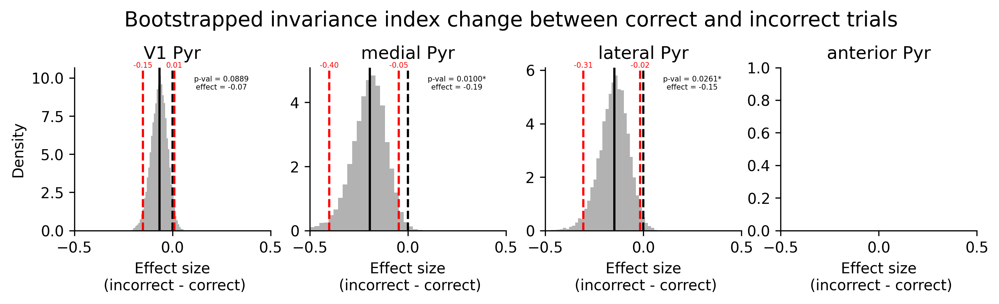

In [1620]:
fig, ax = plt.subplots(1, 4, figsize=(11, 2), dpi=300)
for iaa, area in enumerate(areas):
    ax[iaa].set_title(f"{area} Pyr")
    if area != "anterior":
        test_result = paired_bootstrap_test(correct, incorrect, area=area, celltype="Pyr", n_bootstrap=20000, random_state=333)
        plot_bootstrap_diff(test_result["bootstrap_distribution"], test_result["observed_diff"], test_result["ci"], test_result["p_value"], ax[iaa])
    ax[iaa].set_xlim(-.5, .5)
    ax[iaa].set_xticks([-0.5, 0, 0.5])
    ax[iaa].set_xlabel("Effect size" "\n (incorrect - correct)")
ax[0].set_ylabel("Density")
fig.suptitle("Bootstrapped invariance index change between correct and incorrect trials", fontsize=14, y=1.15)
sns.despine()

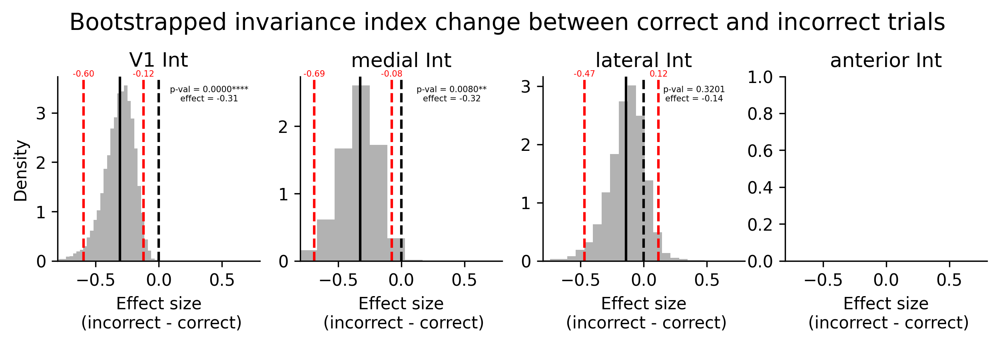

In [1621]:
fig, ax = plt.subplots(1, 4, figsize=(10, 2), dpi=300)
for iaa, area in enumerate(areas):
    ax[iaa].set_title(f"{area} Int")
    if area != "anterior":
        test_result = paired_bootstrap_test(correct, incorrect, area=area, celltype="Int", n_bootstrap=20000, random_state=333)
        plot_bootstrap_diff(test_result["bootstrap_distribution"], test_result["observed_diff"], test_result["ci"], test_result["p_value"], ax[iaa])
    ax[iaa].set_xlim(-.8, .8)
    ax[iaa].set_xticks([-0.5, 0, 0.5])
    ax[iaa].set_xlabel("Effect size" "\n (incorrect - correct)")
ax[0].set_ylabel("Density")
fig.suptitle("Bootstrapped invariance index change between correct and incorrect trials", fontsize=14, y=1.15)
sns.despine()

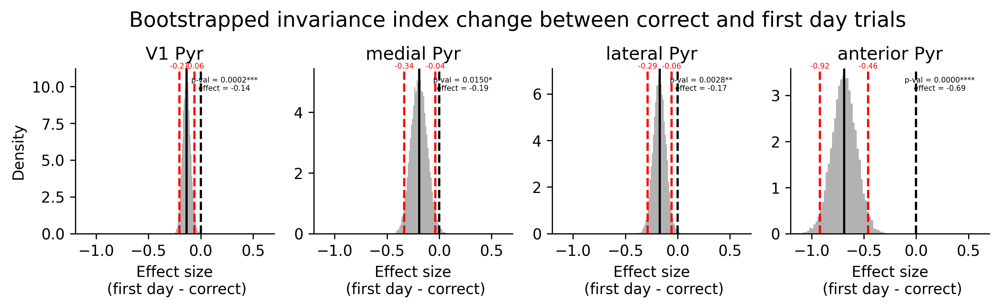

In [1631]:
fig, ax = plt.subplots(1, 4, figsize=(11, 2), dpi=300)
for iaa, area in enumerate(areas):
    ax[iaa].set_title(f"{area} Pyr")
    test_result = paired_bootstrap_test(correct, first_day_inv, area=area, celltype="Pyr", n_bootstrap=20000, random_state=333)
    plot_bootstrap_diff(test_result["bootstrap_distribution"], test_result["observed_diff"], test_result["ci"], test_result["p_value"], ax[iaa])
    ax[iaa].set_xlim(-1.2, .7)
    ax[iaa].set_xticks([-1, -0.5, 0, 0.5])
    ax[iaa].set_xlabel("Effect size" "\n (first day - correct)")
ax[0].set_ylabel("Density")
fig.suptitle("Bootstrapped invariance index change between correct and first day trials", fontsize=14, y=1.15)
sns.despine()

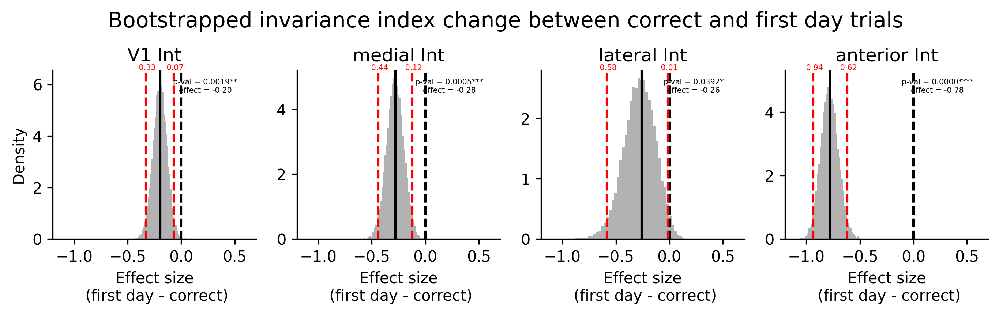

In [1630]:
fig, ax = plt.subplots(1, 4, figsize=(11, 2), dpi=300)
for iaa, area in enumerate(areas):
    ax[iaa].set_title(f"{area} Int")
    test_result = paired_bootstrap_test(correct, first_day_inv, area=area, celltype="Int", n_bootstrap=20000, random_state=333)
    plot_bootstrap_diff(test_result["bootstrap_distribution"], test_result["observed_diff"], test_result["ci"], test_result["p_value"], ax[iaa])
    ax[iaa].set_xlim(-1.2, .7)
    ax[iaa].set_xticks([-1, -0.5, 0, 0.5])
    ax[iaa].set_xlabel("Effect size" "\n (first day - correct)")
ax[0].set_ylabel("Density")
fig.suptitle("Bootstrapped invariance index change between correct and first day trials", fontsize=14, y=1.15)
sns.despine()

### bootstrap invariance on incorrect trials.

In [ ]:
dist_fday = np.full((len(areas), len(celltype), 20000), np.nan)
dist_correct = np.full((len(areas), len(celltype), 20000), np.nan)
dist_incorrect = np.full((len(areas), len(celltype), 20000), np.nan)
for a, area in enumerate(areas):
    for c, cell in enumerate(celltype):
        bootstrap_stats_incorrect = bootstrap_invariance(prot_sep_incorrect[:,a,c], rest_sep_incorrect[:,a,c], n_bootstrap=20000, random_state=333)
        bootstrap_stats_correct = bootstrap_invariance(prot_sep_correct[:,a,c], rest_sep_correct[:,a,c], n_bootstrap=20000, random_state=333)
        bootstrap_stats_fday = bootstrap_invariance(prot_sep_fday[:,a,c], rest_sep_fday[:,a,c], n_bootstrap=20000, random_state=333)
        dist_incorrect[a,c,:] = bootstrap_stats_incorrect
        dist_correct[a,c,:] = bootstrap_stats_correct
        dist_fday[a,c,:] = bootstrap_stats_fday

In [1647]:
def plot_gidist_comparison_wcontrol(fist_dist, second_dist, control_dist, first_day_inv, correct, incorrect, ax , sig_line=1, sig_line_control=1.15, ylabel="invariance index $(a.u.)$", labels = ["first day", "test day (matched)", "test day (all trials)"], alternative=('greater', 'greater')):
    """
    Plot the GI comparison between the first and last training sessions.
    Parameters
    ----------
    gis_sess : np.ndarray
        The GI data for the first and last training sessions. Shape: (sess*day, areas, ctypes)
    ax : matplotlib.axes.Axes
        The axes on which to plot the data.
    """
    from matplotlib.lines import Line2D
    from scipy.stats import ttest_rel, sem
    colors = ["#a8d7bc",'#2ca25f',"#77b9aa"]
    offset = [-0.1, 0.1, 0.3] # offset for the first, second and control GI
    for i_gi, gi in enumerate([fist_dist, second_dist, control_dist]):
        for a in range(4):
            for ctp in range(2):
                mean = np.nanmean(gi[a, ctp, :], axis=-1)
                sem_ = np.std(gi[a, ctp, :], axis=-1, ddof=1)
                ax[ctp].scatter(a+offset[i_gi], mean, color=colors[i_gi], alpha=1, s=15)
                ax[ctp].errorbar(a+offset[i_gi], mean, yerr=sem_, color=colors[i_gi], alpha=1)
                ax[ctp].set_xticks(np.arange(4), ['V1', 'medial', 'lateral', 'anterior'])
                if i_gi == 2:
                    if a == 3:
                        ax[ctp].text(a+offset[i_gi], 0, "NA", ha='center', va='bottom', color=colors[i_gi], fontsize=10, transform=ax[ctp].transData)
                #ax[ctp].axhline(y=0, color='gray', linestyle='..', alpha=0.1)
                if ctp == 0:
                    ax[ctp].set_ylabel(ylabel)
                    ax[ctp].set_yticks([0,.25,.5,.75, 1])
    ax[1].text(1.05, .92, labels[0], ha='left', color=colors[0], transform=ax[1].transAxes)
    ax[1].text(1.05, .84, labels[1], ha='left', color=colors[1],transform=ax[1].transAxes)
    ax[1].text(1.05, .78, labels[2], ha='left', color=colors[2], transform=ax[1].transAxes)

    for a, area, in enumerate(["V1", "medial", "lateral", "anterior"]):
        for ctp, celltype in enumerate(["Pyr", "Int"]):
            test_result = paired_bootstrap_test(correct, first_day_inv, area=area, celltype=celltype, n_bootstrap=20000, random_state=333)
            print(f"{area} {celltype} correct vs first day: p-value = {test_result['p_value']:.4f}, observed diff = {test_result['observed_diff']:.4f}, CI = ({test_result['ci'][0]:.4f}, {test_result['ci'][1]:.4f})")
            if test_result["p_value"] < .05:
                p_t = fig1.significance(test_result["p_value"])
                ax[ctp].text(a, sig_line, p_t, ha='center', va='center', color='k', fontsize=10, transform=ax[ctp].transData)
                # a line between one category and the other
                line = Line2D([a-.1, a+.1], [sig_line, sig_line], color='k', linewidth=1, alpha=1)
                ax[ctp].add_line(line)
            if area != "anterior":
                test_result = paired_bootstrap_test(correct, incorrect, area=area, celltype=celltype, n_bootstrap=20000, random_state=333)
                p_t = fig1.significance(test_result["p_value"])
                if test_result["p_value"] < .05:
                    ax[ctp].text(a+.2, sig_line_control, p_t, ha='center', va='center', color='k', fontsize=10, transform=ax[ctp].transData)
                    # a line between one category and the other
                    #from matplotlib.lines import Line2D
                    line = Line2D([a+.1, a+.3], [sig_line_control, sig_line_control], color='k', linewidth=1, alpha=1)
                    ax[ctp].add_line(line)

C:\Users\labadmin\AppData\Local\Temp\ipykernel_12596\3417266772.py:18: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(gi[a, ctp, :], axis=-1)
C:\Users\labadmin\AppData\Local\Temp\ipykernel_12596\3417266772.py:18: RuntimeWarning: Mean of empty slice
  mean = np.nanmean(gi[a, ctp, :], axis=-1)


V1 Pyr correct vs first day: p-value = 0.0002, observed diff = -0.1358, CI = (-0.2052, -0.0605)
V1 Int correct vs first day: p-value = 0.0019, observed diff = -0.1961, CI = (-0.3287, -0.0691)
medial Pyr correct vs first day: p-value = 0.0150, observed diff = -0.1899, CI = (-0.3352, -0.0373)
medial Int correct vs first day: p-value = 0.0005, observed diff = -0.2795, CI = (-0.4400, -0.1233)
lateral Pyr correct vs first day: p-value = 0.0028, observed diff = -0.1717, CI = (-0.2871, -0.0572)
lateral Int correct vs first day: p-value = 0.0392, observed diff = -0.2576, CI = (-0.5844, -0.0122)
anterior Pyr correct vs first day: p-value = 0.0000, observed diff = -0.6872, CI = (-0.9217, -0.4598)
anterior Int correct vs first day: p-value = 0.0000, observed diff = -0.7790, CI = (-0.9356, -0.6170)


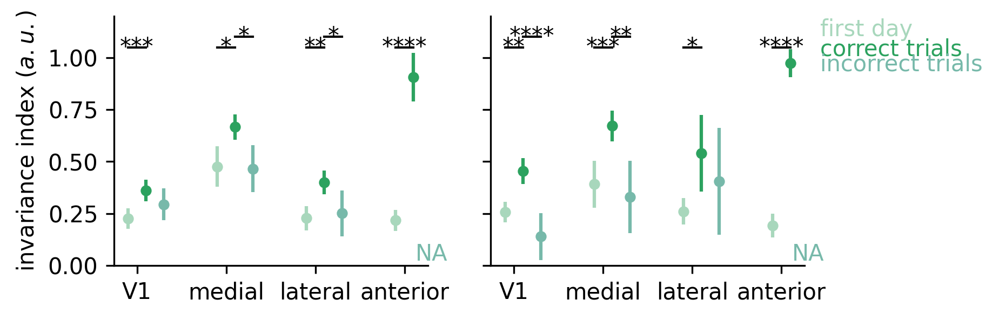

In [1648]:
dist_inc_plot = np.copy(dist_incorrect)
dist_inc_plot[3,:,:] = np.nan
fig, ax = plt.subplots(1,2, figsize=(5.5,2), dpi=300, sharey=True)
plot_gidist_comparison_wcontrol(dist_fday, dist_correct, dist_inc_plot, first_day_inv, correct, incorrect,
                                 ax , sig_line=1.05, sig_line_control=1.1, ylabel="invariance index $(a.u.)$", labels = ["first day", "correct trials", "incorrect trials"], alternative=('two-sided', 'two-sided'));
for a in ax.flatten():
    a.set_ylim(0,1.2)
sns.despine()

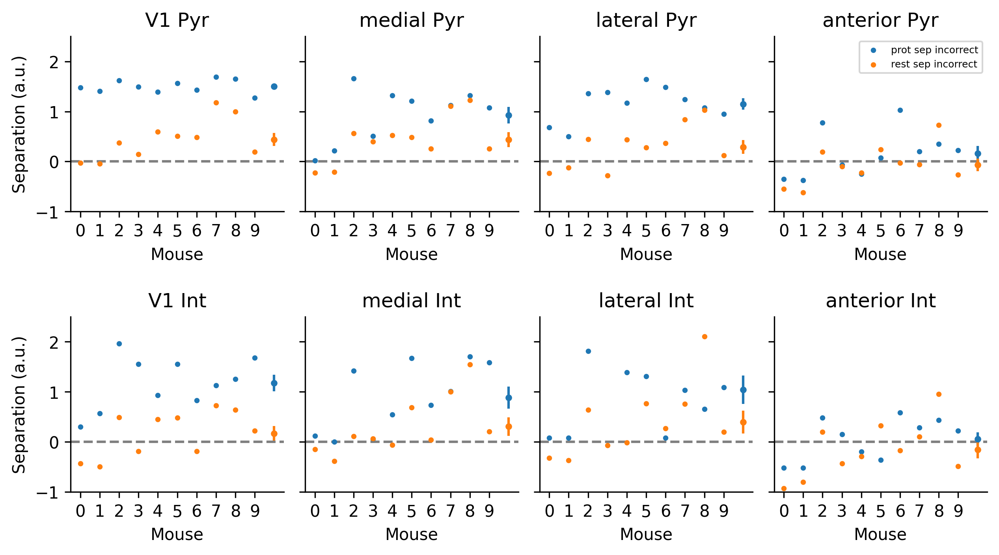

In [1374]:
fig, ax = plt.subplots(2, 4, figsize=(10, 5), dpi=300, sharey=True)
plt.subplots_adjust(wspace=0.1, hspace=0.6)
for a, area in enumerate(areas):
    for c, cell in enumerate(celltype):
        ax_ = ax[c, a]
        ax_.scatter(np.arange(10), prot_sep_incorrect[:,a,c], s=5)
        ax_.scatter(np.arange(10), rest_sep_incorrect[:,a,c], s=5)
        ax_.errorbar(10, prot_sep_incorrect[:,a,c].mean(0), yerr=sem(prot_sep_incorrect[:,a,c]), fmt='o', color='tab:blue', label='prot sep incorrect', markersize=3)
        ax_.errorbar(10, rest_sep_incorrect[:,a,c].mean(0), yerr=sem(rest_sep_incorrect[:,a,c]), fmt='o', color='tab:orange', label='rest sep incorrect', markersize=3)
        ax_.axhline(0, color='gray', linestyle='--', zorder=0)
        ax_.set_title(f"{areas[a]} {cell}")
        ax_.set_xlabel("Mouse")
        ax[c,0].set_ylabel("Separation (a.u.)")
        ax_.set_xticks(np.arange(10))
        ax_.set_ylim(-1, 2.5)
ax[0,-1].legend(["prot sep incorrect", "rest sep incorrect"], fontsize=6, loc='upper right')
sns.despine()

        

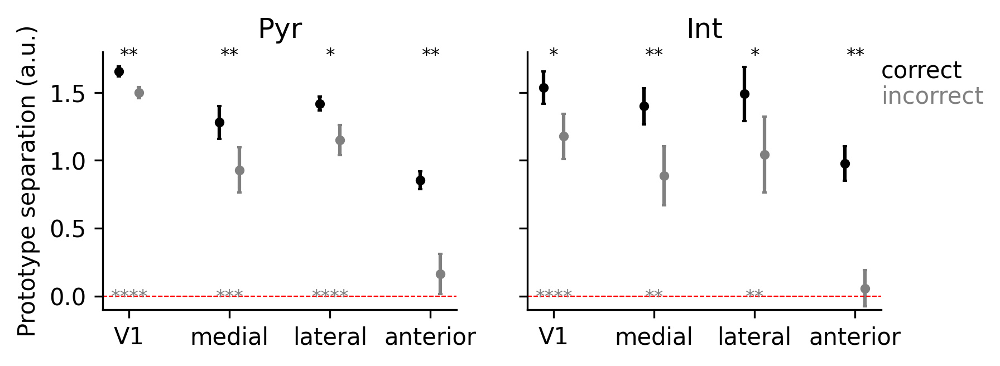

In [1275]:
from scipy.stats import sem, ttest_rel, ttest_1samp
fig, ax = plt.subplots(1, len(celltype), figsize=(6, 2), dpi=300, sharey=True)
prot_sep_correct_mean = prot_sep_correct.mean(axis=0)
prot_sep_sem = sem(prot_sep_correct, axis=0)
prot_sep_incorrect_mean = prot_sep_incorrect.mean(axis=0)
prot_sep_inc_sem = sem(prot_sep_incorrect, axis=0)
for a, area in enumerate(areas):
    for c, cell in enumerate(celltype):
        ax[c].errorbar(a-.1, prot_sep_correct_mean[a, c], yerr=prot_sep_sem[a, c], color='black', capsize=1)
        ax[c].scatter(a-.1, prot_sep_correct_mean[a, c], color='k', s=10)
        ax[c].errorbar(a+.1, prot_sep_incorrect_mean[a, c], yerr=prot_sep_inc_sem[a, c], color='grey', capsize=1)
        ax[c].scatter(a+.1, prot_sep_incorrect_mean[a, c], color='grey', s=10)
        t, pval = ttest_rel(prot_sep_correct[:,a,c], prot_sep_incorrect[:,a,c])
        ptxt = fig1.significance(pval)
        ax[c].text(a, 1.70, f"{ptxt}", ha='center', va='bottom', color='k', fontsize=8)
        t_, pval = ttest_1samp(prot_sep_incorrect[:,a,c], 0)
        ptext_inc = fig1.significance(pval)
        ax[c].text(a, -0.08, f"{ptext_inc}", ha='center', va='bottom', color='grey', fontsize=8)
        ax[c].set_ylim(-0.1, 1.8)
        ax[c].set_title(f"{cell}")
        ax[c].axhline(0, color='r', linestyle='--', linewidth=.5)
        ax[c].set_xticks(range(len(areas)), areas)
ax[1].text(1, 0.9,"correct",  transform=ax[1].transAxes, color='black', fontsize=10, ha='left')
ax[1].text(1, 0.8, "incorrect", transform=ax[1].transAxes, color='grey', fontsize=10, ha='left')
ax[0].set_ylabel("Prototype separation (a.u.)")
sns.despine()

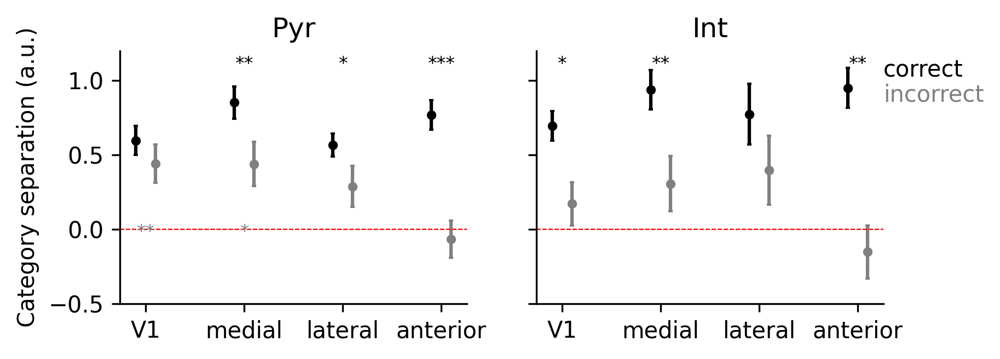

In [1269]:
from scipy.stats import sem, ttest_rel, ttest_1samp


fig, ax = plt.subplots(1, len(celltype), figsize=(6, 2), dpi=300, sharey=True)
rest_sep_correct_mean = rest_sep_correct.mean(axis=0)
rest_sep_sem = sem(rest_sep_correct, axis=0)
rest_sep_incorrect_mean = rest_sep_incorrect.mean(axis=0)
rest_sep_inc_sem = sem(rest_sep_incorrect, axis=0)
for a, area in enumerate(areas):
    for c, cell in enumerate(celltype):
        ax[c].errorbar(a-.1, rest_sep_correct_mean[a, c], yerr=rest_sep_sem[a, c], color='black', capsize=1)
        ax[c].scatter(a-.1, rest_sep_correct_mean[a, c], color='k', s=10)
        
        ax[c].errorbar(a+.1, rest_sep_incorrect_mean[a, c], yerr=rest_sep_inc_sem[a, c], color='grey', capsize=1)
        ax[c].scatter(a+.1, rest_sep_incorrect_mean[a, c], color='grey', s=10)
        t, pval = ttest_rel(rest_sep_correct[:,a,c], rest_sep_incorrect[:,a,c])
        ptxt = fig1.significance(pval)
        t_, pval = ttest_1samp(rest_sep_incorrect[:,a,c], 0)
        ptext_inc = fig1.significance(pval)
        ax[c].text(a, 1.05, f"{ptxt}", ha='center', va='bottom', color='k', fontsize=8)
        ax[c].text(a, -0.08, f"{ptext_inc}", ha='center', va='bottom', color='grey', fontsize=8)
        ax[c].set_ylim(-0.5, 1.2)
        ax[c].set_title(f"{cell}")
        ax[c].axhline(0, color='r', linestyle='--', linewidth=.5)
        ax[c].set_xticks(range(len(areas)), areas)
ax[1].text(1, 0.9,"correct",  transform=ax[1].transAxes, color='black', fontsize=10, ha='left')
ax[1].text(1, 0.8, "incorrect", transform=ax[1].transAxes, color='grey', fontsize=10, ha='left')
ax[0].set_ylabel("Category separation (a.u.)")
sns.despine()

In [1127]:
inv = get_feature_fromdf("invariance", topdpprot_gainvsgeom_df)

In [1256]:
ii_incorrect.shape

(10, 4, 2)

In [1257]:
ii_correct.shape

(10, 4, 2)

In [1258]:
gis_first.shape

(4, 2, 2)

In [ ]:
prot_sep_correct, rest_sep_correct, ii_correct = get_sep_from_cds(correct, masked=False)
prot_sep_incorrect, rest_sep_incorrect, ii_incorrect 

(4, 4, 2, 2, 400)

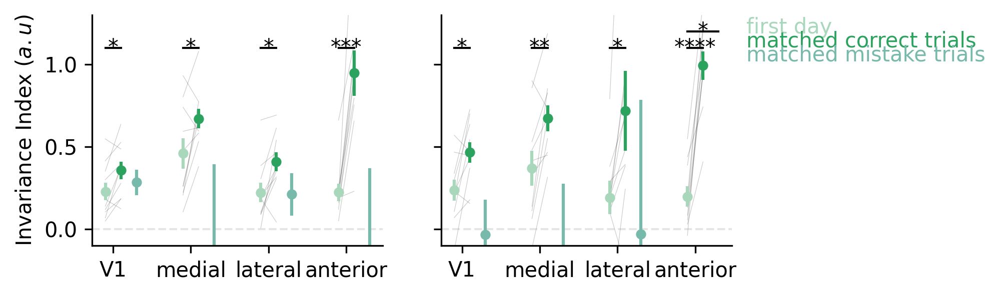

In [1549]:
gis_first =  get_ii_from_cds(cds_all[0])
gis_last_m = ii_correct
gis_last = ii_incorrect
fig, ax = plt.subplots(1,2, figsize=(5.5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=1.1, sig_line_control=1.2, ylabel='Invariance Index $(a.u)$', 
                                 alternative=('two-sided', 'two-sided'), labels=['first day','matched correct trials', 'matched mistake trials'])
for a in ax.flatten():
    a.set_ylim(-0.1, 1.3)
    a.axhline(0, color='gray', linestyle='--', linewidth=1, zorder=0, alpha=0.2)
sns.despine()

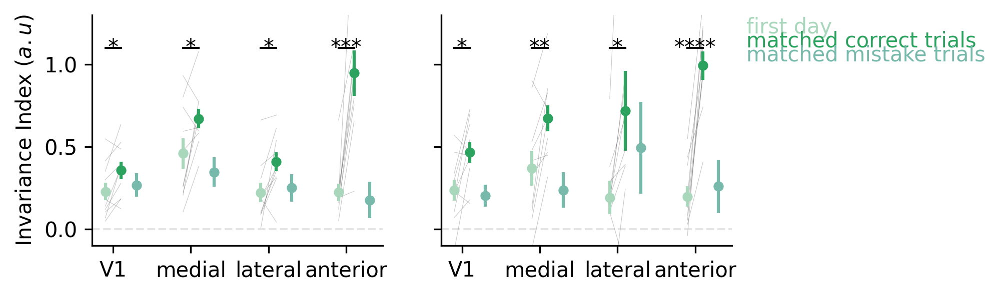

In [1371]:
gis_first =  get_ii_from_cds(cds_all[0])
gis_last_m = ii_correct
gis_last = rest_sep_incorrect / (prot_sep_correct + 1e-6)
fig, ax = plt.subplots(1,2, figsize=(5.5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=1.1, sig_line_control=1.2, ylabel='Invariance Index $(a.u)$', 
                                 alternative=('two-sided', 'two-sided'), labels=['first day','matched correct trials', 'matched mistake trials'])
for a in ax.flatten():
    a.set_ylim(-0.1, 1.3)
    a.axhline(0, color='gray', linestyle='--', linewidth=1, zorder=0, alpha=0.2)
sns.despine()

In [1135]:
mistake_analysis_df

,name,datexp,blk,session,celltype,area,hit_prot,cr_prot,om_prot,fa_prot,hit_nonprot,cr_nonprot,miss_nonprot,fa_nonprot
0,VG11,2024_10_31,2,last training (matched),Pyr,V1,17.872960,-11.638029,15.322475,-11.818963,4.066626,-0.766328,1.148356,0.268150
1,VG11,2024_10_31,2,last training (matched),Int,V1,3.914784,-0.408915,1.861391,0.604275,3.138446,0.861940,0.660202,2.001034
2,VG11,2024_10_31,2,last training (matched),Pyr,medial,9.013274,-1.120299,2.090290,0.259883,6.754831,-0.120389,0.364894,2.816703
3,VG11,2024_10_31,2,last training (matched),Int,medial,1.530986,-0.562374,-0.045677,-0.247557,1.435130,0.030583,0.441709,0.559628
4,VG11,2024_10_31,2,last training (matched),Pyr,lateral,9.296433,-4.170986,6.045694,-3.674211,4.454662,0.804231,0.743393,2.119072
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,VGa9,2025_11_20,2,last training (matched),Int,medial,2.931283,-4.069829,2.383173,-3.418439,2.591560,-1.545203,0.228728,-1.056523
76,VGa9,2025_11_20,2,last training (matched),Pyr,lateral,7.775900,-5.626678,4.573547,-4.268928,3.482779,0.065667,0.957943,-0.120147
77,VGa9,2025_11_20,2,last training (matched),Int,lateral,2.529081,-0.871601,1.202472,-0.528784,0.780106,-0.145540,0.125487,0.021672
78,VGa9,2025_11_20,2,last training (matched),Pyr,anterior,6.757444,-3.198212,3.286621,0.352243,5.883488,-2.259033,-1.413727,0.534120


In [1136]:
mistake_analysis_df = mistake_analysis_df.assign(inv_correct= (mistake_analysis_df["hit_nonprot"] - mistake_analysis_df["cr_nonprot"])/(mistake_analysis_df["hit_prot"] - mistake_analysis_df["cr_prot"]),
                            inv_incorrect= (mistake_analysis_df["miss_nonprot"] - mistake_analysis_df["fa_nonprot"])/(mistake_analysis_df["hit_prot"] - mistake_analysis_df["cr_prot"]))

In [1137]:
mistake_analysis_df

,name,datexp,blk,session,celltype,area,hit_prot,cr_prot,om_prot,fa_prot,hit_nonprot,cr_nonprot,miss_nonprot,fa_nonprot,inv_correct,inv_incorrect
0,VG11,2024_10_31,2,last training (matched),Pyr,V1,17.872960,-11.638029,15.322475,-11.818963,4.066626,-0.766328,1.148356,0.268150,0.163768,0.029826
1,VG11,2024_10_31,2,last training (matched),Int,V1,3.914784,-0.408915,1.861391,0.604275,3.138446,0.861940,0.660202,2.001034,0.526518,-0.310112
2,VG11,2024_10_31,2,last training (matched),Pyr,medial,9.013274,-1.120299,2.090290,0.259883,6.754831,-0.120389,0.364894,2.816703,0.678460,-0.241949
3,VG11,2024_10_31,2,last training (matched),Int,medial,1.530986,-0.562374,-0.045677,-0.247557,1.435130,0.030583,0.441709,0.559628,0.670953,-0.056330
4,VG11,2024_10_31,2,last training (matched),Pyr,lateral,9.296433,-4.170986,6.045694,-3.674211,4.454662,0.804231,0.743393,2.119072,0.271056,-0.102149
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,VGa9,2025_11_20,2,last training (matched),Int,medial,2.931283,-4.069829,2.383173,-3.418439,2.591560,-1.545203,0.228728,-1.056523,0.590872,0.183578
76,VGa9,2025_11_20,2,last training (matched),Pyr,lateral,7.775900,-5.626678,4.573547,-4.268928,3.482779,0.065667,0.957943,-0.120147,0.254959,0.080439
77,VGa9,2025_11_20,2,last training (matched),Int,lateral,2.529081,-0.871601,1.202472,-0.528784,0.780106,-0.145540,0.125487,0.021672,0.272194,0.030528
78,VGa9,2025_11_20,2,last training (matched),Pyr,anterior,6.757444,-3.198212,3.286621,0.352243,5.883488,-2.259033,-1.413727,0.534120,0.817879,-0.195652


In [1139]:
def get_feature_fromdf_matched(feature_name: str, df: pd.DataFrame):
    sessions = ['last training (matched)']
    areas = ['V1', 'medial', 'lateral', 'anterior']
    celltype = ['Pyr', 'Int']
    nmice = 10
    f_dict = {}
    for sess in sessions: 
        fts = np.empty((nmice, len(areas), len(celltype)))
        for ia, area in enumerate(areas):
            for ic, ctype in enumerate(celltype):
                ft = get_feature_values(df, area, ctype, sess, feature_name)
                #store values
                fts[:,ia,ic] = ft
        f_dict[sess] = fts
    return f_dict   

In [1140]:
inv_cr = get_feature_fromdf_matched("inv_correct", mistake_analysis_df)
inv_incorrect = get_feature_fromdf_matched("inv_incorrect", mistake_analysis_df)

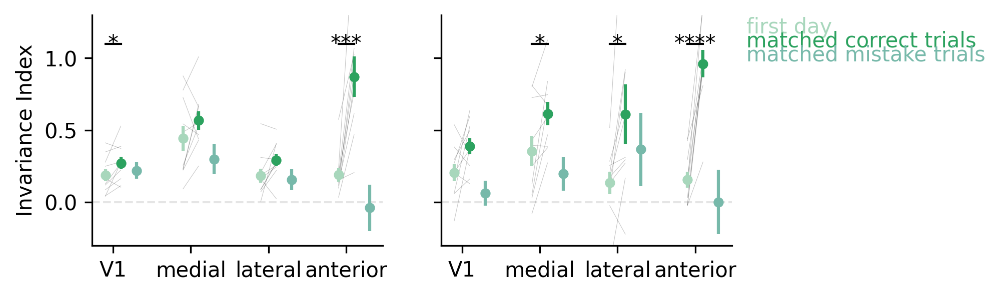

In [ ]:
gis_first =  get_ii_from_cds(cds_all[0])
gis_last_m = inv_cr["last training (matched)"]
gis_last = inv_incorrect["last training (matched)"]
fig, ax = plt.subplots(1,2, figsize=(5.5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=1.1, sig_line_control=1.2, ylabel='Invariance Index', 
                                 alternative=('two-sided', 'two-sided'), labels=['first day','matched correct trials', 'matched mistake trials'])
for a in ax.flatten():
    a.set_ylim(-.3,1.3)
    a.axhline(0, color='gray', linestyle='--', linewidth=1, zorder=0, alpha=0.2)
sns.despine()

In [1181]:
celltype = ['Pyr', 'Int']
areas = ['V1', 'medial', 'lateral', 'anterior']
n_sessions = 3
sessions_names = ['first training', 'last training (matched)', 'all rewarded after']
obj_path = Path(r"D:\mouseobj")
cds_all_rew = np.zeros((n_sessions, 10, 4, len(areas), len(celltype), 400))
named = "coding_dir_100.npy"
for iss, sess in enumerate(sessions_names):
    if sess == 'last training (matched)':
        session = 'last training'
        named = "coding_dir_100_matched.npy"
    else:   
        session = sess
        named = "coding_dir_100.npy"
    d = working_dbase.query(f"session == '{session}'")
    print(f"Processing: {sess}")
    for i, (_, row) in enumerate(d.iterrows()):
        name, datexp, blk = row["mname"], row["datexp"], row["blk"]
        save_pth = obj_path.joinpath(name,datexp,blk)
        cd = np.load(save_pth.joinpath(named))
        cds_all_rew[iss, i] = cd

Processing: first training
Processing: last training (matched)
Processing: all rewarded after


In [1184]:
first_day = cds_all_rew[0]
matched = cds_all_rew[1]
all_rew_after = cds_all_rew[2]
first_day = np.delete(first_day, 8, axis=0)  
matched = np.delete(matched, 8, axis=0)
all_rew_after = np.delete(all_rew_after, 8, axis=0)

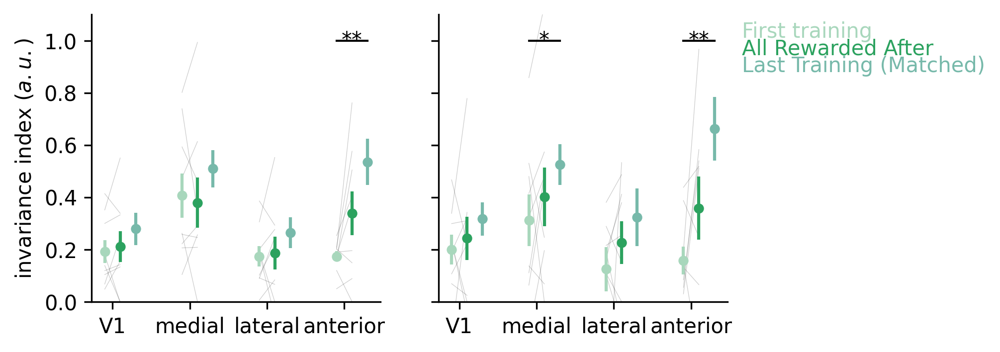

In [1188]:
from src import fig1
gis_first = get_ii_from_cds(first_day)    #remove VG34 that is not in the all rewarded after
gis_last_m =  get_ii_from_cds(all_rew_after)   #remove VG34 that is not in the all rewarded after
gis_last =   get_ii_from_cds(matched)
fig, ax = plt.subplots(1,2, figsize=(5.5,2.5), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=.9, 
                                 sig_line_control=1, alternative=("two-sided", "two-sided"),
                                 labels = ['First training','All Rewarded After', 'Last Training (Matched)'])
for a in ax.flatten():
    a.set_ylim(0,1.1)
sns.despine()

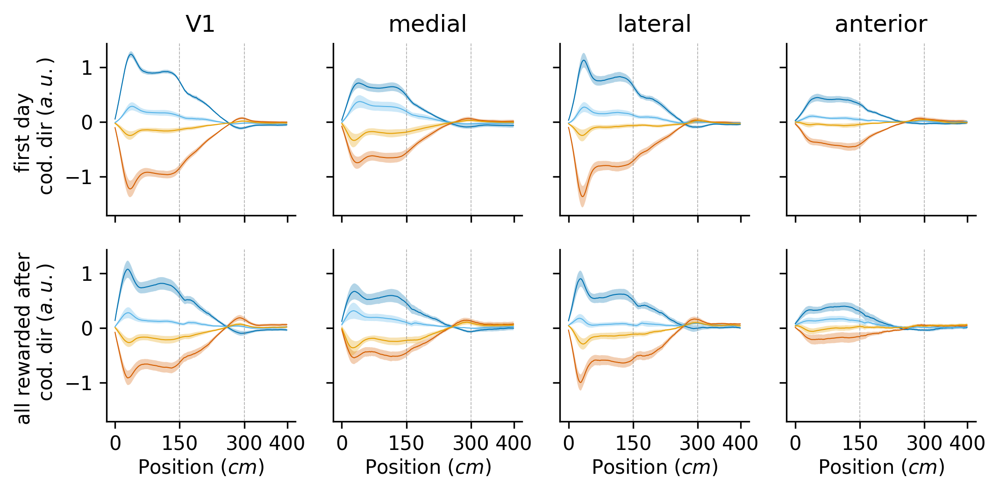

In [1189]:
fig, cds_axs = plt.subplots(2, len(areas), figsize=(8, 3.5), dpi=300,sharex=True, sharey=True)
fday = first_day
allrew = all_rew_after
for a, area in enumerate(areas):
    for ttype in range(4):
        fig1.plot_cds(fday, ttype, a, 0, cds_axs[0, a], references=True)
        fig1.plot_cds(allrew, ttype, a, 0, cds_axs[1, a], references=True)
rows, cols = cds_axs.shape
for i in range(rows):
    for j in range(cols):
        cds_axs[i, j].set_xticks([0, 150, 300, 400])
        cds_axs[0, j].set_title(f"{areas[j]}")
        if i == 1:
            cds_axs[i, j].set_xlabel("Position ($cm$)", labelpad=2)
cds_axs[0,0].set_ylabel("first day \n cod. dir ($a.u.$)")
cds_axs[1,0].set_ylabel("all rewarded after \n cod. dir ($a.u.$)")
sns.despine()

In [1190]:
prot_sep_correct, rest_sep_correct, ii_correct = get_sep_from_cds(fday)
prot_sep_incorrect, rest_sep_incorrect, ii_incorrect = get_sep_from_cds(allrew)

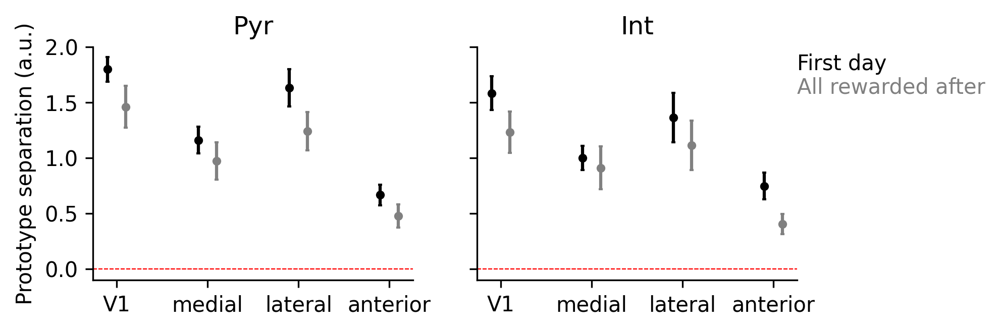

In [1193]:
from scipy.stats import sem
fig, ax = plt.subplots(1, len(celltype), figsize=(6, 2), dpi=300, sharey=True)
prot_sep_correct_mean = prot_sep_correct.mean(axis=0)
prot_sep_sem = sem(prot_sep_correct, axis=0)
prot_sep_incorrect_mean = prot_sep_incorrect.mean(axis=0)
prot_sep_inc_sem = sem(prot_sep_incorrect, axis=0)
for a, area in enumerate(areas):
    for c, cell in enumerate(celltype):
        ax[c].errorbar(a-.1, prot_sep_correct_mean[a, c], yerr=prot_sep_sem[a, c], color='black', capsize=1)
        ax[c].scatter(a-.1, prot_sep_correct_mean[a, c], color='k', s=10)
        ax[c].errorbar(a+.1, prot_sep_incorrect_mean[a, c], yerr=prot_sep_inc_sem[a, c], color='grey', capsize=1)
        ax[c].scatter(a+.1, prot_sep_incorrect_mean[a, c], color='grey', s=10)
        t, pval = ttest_rel(rest_sep_correct[:,a,c], rest_sep_incorrect[:,a,c])
        ptxt = fig1.significance(pval)
        ax[c].text(a, 1.70, f"{ptxt}", ha='center', va='bottom', color='k', fontsize=8)
        ax[c].set_ylim(-0.1, 2)
        ax[c].set_title(f"{cell}")
        ax[c].axhline(0, color='r', linestyle='--', linewidth=.5)
        ax[c].set_xticks(range(len(areas)), areas)
ax[1].text(1, 0.9,"First day",  transform=ax[1].transAxes, color='black', fontsize=10, ha='left')
ax[1].text(1, 0.8, "All rewarded after", transform=ax[1].transAxes, color='grey', fontsize=10, ha='left')
ax[0].set_ylabel("Prototype separation (a.u.)")
sns.despine()

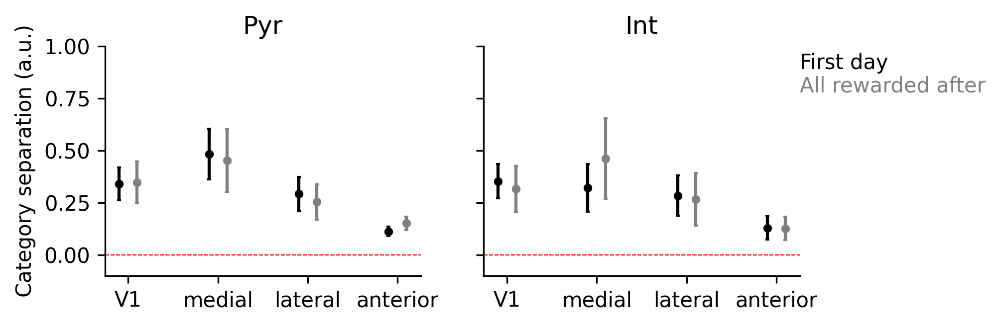

In [1197]:
from scipy.stats import sem


fig, ax = plt.subplots(1, len(celltype), figsize=(6, 2), dpi=300, sharey=True)
rest_sep_correct_mean = rest_sep_correct.mean(axis=0)
rest_sep_sem = sem(rest_sep_correct, axis=0)
rest_sep_incorrect_mean = rest_sep_incorrect.mean(axis=0)
rest_sep_inc_sem = sem(rest_sep_incorrect, axis=0)
for a, area in enumerate(areas):
    for c, cell in enumerate(celltype):
        ax[c].errorbar(a-.1, rest_sep_correct_mean[a, c], yerr=rest_sep_sem[a, c], color='black', capsize=1)
        ax[c].scatter(a-.1, rest_sep_correct_mean[a, c], color='k', s=10)
        
        ax[c].errorbar(a+.1, rest_sep_incorrect_mean[a, c], yerr=rest_sep_inc_sem[a, c], color='grey', capsize=1)
        ax[c].scatter(a+.1, rest_sep_incorrect_mean[a, c], color='grey', s=10)
        t, pval = ttest_rel(rest_sep_correct[:,a,c], rest_sep_incorrect[:,a,c])
        ptxt = fig1.significance(pval)
        ax[c].text(a, 1.05, f"{ptxt}", ha='center', va='bottom', color='k', fontsize=8)
        ax[c].set_ylim(-0.1, 1)
        ax[c].set_title(f"{cell}")
        ax[c].axhline(0, color='r', linestyle='--', linewidth=.5)
        ax[c].set_xticks(range(len(areas)), areas)
ax[1].text(1, 0.9,"First day",  transform=ax[1].transAxes, color='black', fontsize=10, ha='left')
ax[1].text(1, 0.8, "All rewarded after", transform=ax[1].transAxes, color='grey', fontsize=10, ha='left')
ax[0].set_ylabel("Category separation (a.u.)")
sns.despine()

In [1042]:
mistake_analysis_df.groupby(["area", "celltype"]).mean(numeric_only=True)[["hit prot", "cr prot", "om prot", "fa prot", "hit nprot", "cr nonprot", "miss nonprot", "false alarm"]]

hit prot    cr prot    om prot    fa prot  hit nprot  \
area     celltype                                                          
V1       Int        3.360717  -2.612634   2.436168  -1.961918   2.116544   
         Pyr       14.429011 -13.328287  12.596902 -12.338617   5.226550   
anterior Int        2.071446  -0.637496   0.383093   0.521954   2.115894   
         Pyr        6.425847  -2.339706   1.837047   0.582253   6.147955   
lateral  Int        1.531705  -1.459035   0.968179  -1.067821   1.143768   
         Pyr        6.045637  -5.943176   4.517785  -5.106196   2.764431   
medial   Int        2.730572  -1.693064   1.872605  -0.991248   1.932883   
         Pyr       10.109058  -8.083089   7.141859  -5.946131   6.625891   

                   cr nonprot  miss nonprot  false alarm  
area     celltype                                         
V1       Int        -0.544757      0.789762     0.345779  
         Pyr        -2.993104      3.598522    -1.920374  
anterior Int        -0.554055      0.298968     1.026461  
         Pyr        -1.888869      1.289452     2.277363  
lateral  Int        -0.317937      0.629783     0.179694  
         Pyr        -1.202798      1.410805    -0.309647  
medial   Int        -1.020841      0.672662    -0.292520  
         Pyr        -4.448644      3.399983    -2.088883

In [651]:
obj_path = Path(r"D:\mouseobj")
d = working_dbase.query(f"session == 'last training'")
grand_scores_exc = {area: {"hit_prot": [], "hit": [], "correct rejection": [], "miss": [], "false alarm": []} for area in areas}
grand_scores_inh = {area: {"hit_prot": [], "hit": [], "correct rejection": [], "miss": [], "false alarm": []} for area in areas}
outputs = ["hit_prot", "hit", "correct rejection", "miss", "false alarm"]
rows = []
for i, (_, row) in enumerate(d.iterrows()):
    name, datexp, blk = row["mname"], row["datexp"], row["blk"]
    save_pth = obj_path.joinpath(name,datexp,blk)
    scores_exc = np.load(save_pth.joinpath("exc_scores_mistake_analysis.npy"), allow_pickle=True).item()
    scores_inh = np.load(save_pth.joinpath("inh_scores_mistake_analysis.npy"), allow_pickle=True).item()
    for iaa, area in enumerate(areas):
        rows.append({'name': name, 'datexp': datexp, 'blk': blk, 
                    'session': sess, 'celltype': 'exc', 'area': area,
                    'hit_prot': scores_exc[area]['hit_prot'].mean(),
                    'hit': scores_exc[area]['hit'].mean(),
                    'correct_rejection': scores_exc[area]['correct rejection'].mean(),
                    'miss': scores_exc[area]['miss'].mean(),
                    'false_alarm': scores_exc[area]['false alarm'].mean()})
        rows.append({'name': name, 'datexp': datexp, 'blk': blk, 
                'session': sess, 'celltype': 'inh', 'area': area,
                'hit_prot': scores_inh[area]['hit_prot'].mean(),
                'hit': scores_inh[area]['hit'].mean(),
                'correct_rejection': scores_inh[area]['correct rejection'].mean(),
                'miss': scores_inh[area]['miss'].mean(),
                'false_alarm': scores_inh[area]['false alarm'].mean()})
        for output in outputs:
            grand_scores_inh[area][output].extend(scores_inh[area][output])
            grand_scores_exc[area][output].extend(scores_exc[area][output])
proj_scores_df = pd.DataFrame(rows)

In [655]:
output_vars = [c for c in ['hit_prot', 'hit', 'correct_rejection', 'miss', 'false_alarm'] if c in proj_scores_df.columns]
proj_scores_melted = proj_scores_df.melt(id_vars=['name', 'datexp', 'blk', 'session', 'celltype', 'area'], value_vars=output_vars, var_name='output', value_name='score')
proj_scores_melted.to_csv(r"D:\mouseobj\overall\projection_scores_means_mistake_analysis.csv", index=False)

def get_mean_se_pergroup(area, celltype, output, df):
    from scipy import stats
    vals = df.query(f"celltype == '{celltype}' & area == '{area}' & output == '{output}'")["score"].values
    mean_ = np.mean(vals)
    se_ =  stats.sem(vals)
    return mean_, se_, vals

from scipy.stats import ttest_rel

In [705]:
def plot_scores(ax, celltype, proj_scores_melted, reflabel=False, legend=False, ylabel=False):
    palette =["#0072B2","#D55E00", "#56B4E9","#E69F00"]
    areas = ['V1', 'medial', 'lateral', 'anterior']
    for ia, area in enumerate(areas):
        mn_, se_, vals = get_mean_se_pergroup(area, celltype, 'hit_prot', proj_scores_melted)
        ax.hlines(mn_/2, ia-.1, ia+.1, color='k', linestyle='--', linewidth=0.8)
        ax.errorbar(ia, mn_, se_, c='tab:green')
        ax.scatter(ia, mn_, s=10, c='tab:green')
        mn_1, se_1, vals_1 = get_mean_se_pergroup(area, celltype, 'hit', proj_scores_melted)
        ax.errorbar(ia-.2, mn_1, se_1, c=palette[0])
        ax.scatter(ia-.2, mn_1, s=10, c=palette[0])
        mn_2, se_2, vals_2 = get_mean_se_pergroup(area, celltype, 'miss', proj_scores_melted)
        ax.errorbar(ia-.1, mn_2, se_2, c=palette[2])
        ax.scatter(ia-.1, mn_2, s=10, c=palette[2])
        ax.plot([ia-.2, ia-.1], [vals_1, vals_2], 'k-', alpha=0.3, linewidth=0.2, zorder=0);
        tstat, pval = ttest_rel(vals_1, vals_2)
        if pval < 0.05:
            stars = '***' if pval < 0.001 else '**' if pval < 0.01 else '*'
            ax.text(ia-.15, max(vals_1) + 0.1, stars, ha='center', va='bottom', fontsize=5)

        mn_1, se_1, vals_1 = get_mean_se_pergroup(area, celltype, 'correct_rejection', proj_scores_melted)
        ax.errorbar(ia+.1, mn_1, se_1, c=palette[1])
        ax.scatter(ia+.1, mn_1, s=10, c=palette[1])
        mn_2, se_2, vals_2 = get_mean_se_pergroup(area, celltype, 'false_alarm', proj_scores_melted)
        ax.errorbar(ia+.2, mn_2, se_2, c=palette[3])
        ax.scatter(ia+.2, mn_2, s=10, c=palette[3])
        ax.plot([ia+.1, ia+.2], [vals_1, vals_2], 'k-', alpha=0.3, linewidth=0.2, zorder=0);

        tstat, pval = ttest_rel(vals_1, vals_2)
        if pval < 0.05:
            stars = '***' if pval < 0.001 else '**' if pval < 0.01 else '*'
            ax.text(ia+.15, max(vals_2) + 0.1, stars, ha='center', va='bottom', fontsize=5)
    if legend:
        outputs = ["Hit prot","Hit", "Correct rejection", "Miss", "False alarm"]
        ylims = ax.get_ylim()
        palette =["tab:green","#0072B2","#D55E00", "#56B4E9","#E69F00"]
        for c, output in enumerate(outputs):
            ax.text(3.5, ylims[1]- c*.7, output, c=palette[c], label=output, fontsize=9, verticalalignment='center')
    ax.set_xticks([0, 1, 2, 3], ['V1', 'medial', 'lateral', 'anterior'])
    ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
    if reflabel:
        ax.text(4, 0, 'Non rewarded prototype', fontsize=8, verticalalignment='center')
    if ylabel:
        ax.set_ylabel('Z-scored projection score \n (non prototypes)')
    ax.set_ylim(-0.5,16)
    ax.set_xlim(-.5,4)
    sns.despine()

Text(0.5, 1.0, 'Inhibitory neurons')

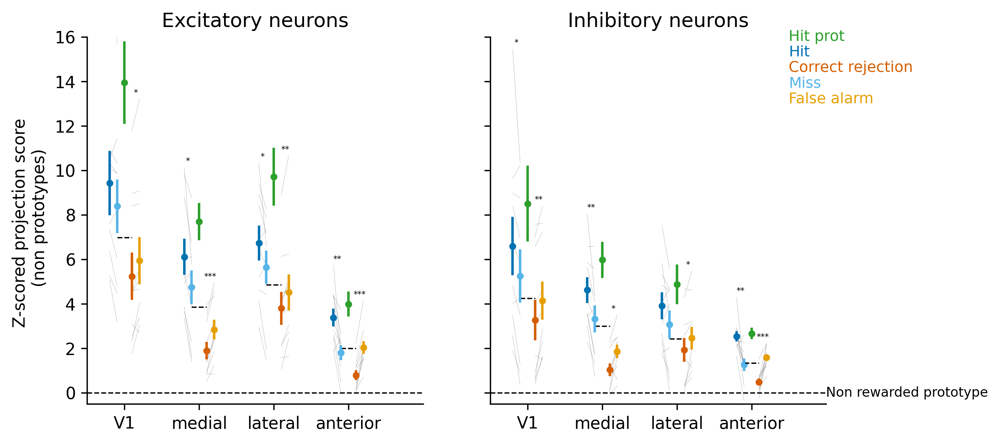

In [706]:
ig, ax = plt.subplots(1,2, figsize=(8,4), dpi=300, sharey=True)
plot_scores(ax[0], 'exc', proj_scores_melted, ylabel=True)
ax[0].set_title('Excitatory neurons')
plot_scores(ax[1], 'inh', proj_scores_melted, legend=True, reflabel=True, ylabel=False)
ax[1].set_title('Inhibitory neurons')

In [710]:
mistake_analysis_df

,name,datexp,blk,session,celltype,area,prot_sep,nprot_corrct,nprot_mistake,inv_corrct,inv_mistake
0,VG11,2024_10_31,2,last training (matched),exc,V1,10.012559,1.539746,-0.438614,0.153781,-0.043806
1,VG11,2024_10_31,2,last training (matched),inh,V1,2.202468,1.506211,-0.999616,0.683874,-0.453862
2,VG11,2024_10_31,2,last training (matched),exc,medial,2.813692,1.813671,-0.835786,0.644588,-0.297042
3,VG11,2024_10_31,2,last training (matched),inh,medial,2.304398,1.780913,-0.388250,0.772832,-0.168482
4,VG11,2024_10_31,2,last training (matched),exc,lateral,4.156807,1.544206,-0.974548,0.371488,-0.234446
...,...,...,...,...,...,...,...,...,...,...,...
75,VGa9,2025_11_20,2,last training (matched),inh,medial,6.092385,4.144838,0.492087,0.680331,0.080771
76,VGa9,2025_11_20,2,last training (matched),exc,lateral,10.582810,2.875287,0.045669,0.271694,0.004315
77,VGa9,2025_11_20,2,last training (matched),inh,lateral,7.440959,2.056423,0.277422,0.276365,0.037283
78,VGa9,2025_11_20,2,last training (matched),exc,anterior,3.834927,3.147186,-0.685230,0.820664,-0.178681


In [711]:
df_long = mistake_analysis_df.melt(id_vars=['name', 'datexp', 'blk', 'session', 'celltype', 'area'], value_vars=['prot_sep', 'nprot_corrct', 'nprot_mistake', 'inv_corrct', 'inv_mistake'], var_name='metric', value_name='value')

In [717]:
df_long.query("metric in ['inv_corrct', 'inv_mistake']")

,name,datexp,blk,session,celltype,area,metric,value
240,VG11,2024_10_31,2,last training (matched),exc,V1,inv_corrct,0.153781
241,VG11,2024_10_31,2,last training (matched),inh,V1,inv_corrct,0.683874
242,VG11,2024_10_31,2,last training (matched),exc,medial,inv_corrct,0.644588
243,VG11,2024_10_31,2,last training (matched),inh,medial,inv_corrct,0.772832
244,VG11,2024_10_31,2,last training (matched),exc,lateral,inv_corrct,0.371488
...,...,...,...,...,...,...,...,...
395,VGa9,2025_11_20,2,last training (matched),inh,medial,inv_mistake,0.080771
396,VGa9,2025_11_20,2,last training (matched),exc,lateral,inv_mistake,0.004315
397,VGa9,2025_11_20,2,last training (matched),inh,lateral,inv_mistake,0.037283
398,VGa9,2025_11_20,2,last training (matched),exc,anterior,inv_mistake,-0.178681


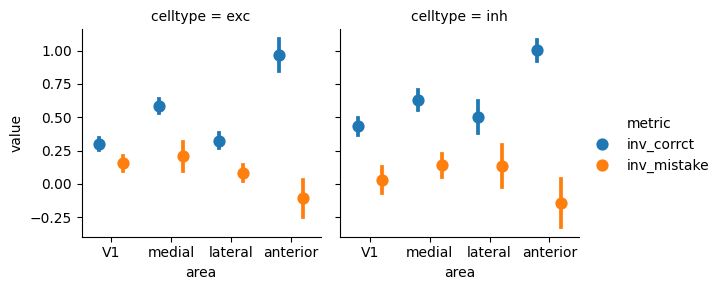

In [718]:
sns.catplot(data=df_long.query("metric in ['inv_corrct', 'inv_mistake']"), x='area', y='value', col="celltype", hue='metric', errorbar='se', kind='point', height=3, aspect=1, dodge=.4, linestyle='none')

In [722]:
sessions = ['last training (matched)']
areas = ['V1', 'medial', 'lateral', 'anterior']
celltype = ['exc', 'inh']
nmice = 10
invariances = {}
for sess in sessions: 
    invariance_corrct = np.empty((nmice, len(areas), len(celltype)))
    invariance_mistake = np.empty((nmice, len(areas), len(celltype)))
    for ia, area in enumerate(areas):
        for ic, ctype in enumerate(celltype):
            inv = get_feature_values(mistake_analysis_df, area, ctype, sess, 'inv_corrct')
            inv_mis = get_feature_values(mistake_analysis_df, area, ctype, sess, 'inv_mistake')
            #store values
            invariance_corrct[:,ia,ic] = inv
            invariance_mistake[:,ia,ic] = inv_mis

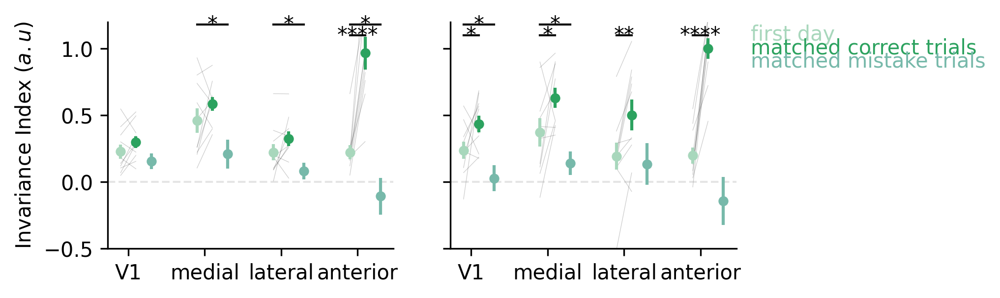

In [1148]:
gis_first = get_ii_from_cds(cds_all[0])
gis_last = invariance_mistake
gis_last_m = invariance_corrct
fig, ax = plt.subplots(1,2, figsize=(5.5,2), dpi=300, sharey=True)
fig1.plot_gi_comparison_wcontrol(gis_first, gis_last_m,  gis_last, ax, sig_line=1.1, sig_line_control=1.18, ylabel='Invariance Index $(a.u)$', 
                                 alternative=('greater', 'two-sided'), labels=['first day','matched correct trials', 'matched mistake trials'])
for a in ax.flatten():
    a.set_ylim(-.5,1.2)
    a.axhline(0, color='gray', linestyle='--', linewidth=1, zorder=0, alpha=0.2)
sns.despine()